conda create -n ai-econ-legacy python=3.7.16 -y
conda activate ai-econ-legacy

pip install "numpy==1.16.4"
pip install "tensorflow==1.14.0"
pip install "gym<0.23"
pip install "ray[rllib]==1.13.0"
pip install jupyter ipykernel tensorboard
python -m ipykernel install --user --name ai-econ-legacy --display-name "Python (ai-econ-legacy)"

In [4]:
import sys
import ray
import numpy as np
import tensorflow as tf
import gym


import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd

import random

c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\adria\anaconda3\envs\ai-econ-fixed\lib\s

In [5]:
sys.path.append(r'C:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-')

from ai_economist import foundation

from utils import plotting

import ray
from ray.rllib.agents.ppo import PPOTrainer

In [6]:
from rllib.env_wrapper import RLlibEnvWrapper


In [7]:
# RESULTS_DIR = "results"
# os.makedirs(RESULTS_DIR, exist_ok=True)

# def make_experiment_dir(experiment_name, root=RESULTS_DIR):
#     timestamp = time.strftime("%Y%m%d_%H%M%S")
#     run_dir = os.path.join(root, f"{experiment_name}_{timestamp}")
#     os.makedirs(run_dir, exist_ok=True)
#     return run_dir

# def save_json(obj, path):
#     with open(path, "w") as f:
#         json.dump(obj, f, indent=2, default=str)

# def save_pickle(obj, path):
#     with open(path, "wb") as f:
#         pickle.dump(obj, f)

# def make_env_config_variant(
#     base_env_config,
#     enable_travel=False,
#     restrict_trade_to_region=False,
#     travel_cost_coin=None,
#     travel_cost_labor=None,
#     experiment_name=None,
# ):
#     cfg = deepcopy(base_env_config)

#     # Example: switch travel component
#     if "CrossWaterTravel" in cfg["components"]:
#         cfg["components"]["CrossWaterTravel"]["enabled"] = bool(enable_travel)
#         if travel_cost_coin is not None:
#             cfg["components"]["CrossWaterTravel"]["travel_cost_coin"] = travel_cost_coin
#         if travel_cost_labor is not None:
#             cfg["components"]["CrossWaterTravel"]["travel_cost_labor"] = travel_cost_labor

#     # Example: switch auction market structure
#     if "ContinuousDoubleAuction" in cfg["components"]:
#         cfg["components"]["ContinuousDoubleAuction"]["restrict_trade_to_region"] = bool(
#             restrict_trade_to_region
#         )

#     if experiment_name is not None:
#         cfg["experiment_name"] = experiment_name

#     return cfg

In [8]:
# import types
# import numpy as np

# def patch_regional_tax_masks(env_obj, min_band=4):
#     """
#     Patch all RegionalPeriodicBracketTax components inside a single RLlibEnvWrapper
#     so each bound planner only has its own 7 brackets active, with at least
#     `min_band` legal rate indices on tax day.
#     """
#     for comp in env_obj.env.components:
#         if "BracketTax" not in comp.name:
#             continue

#         def make_patched(c):
#             def _patched_generate_masks(self, completions=0):
#                 planner = self._get_bound_planner(self.world)
#                 if planner is None or str(planner.idx) != str(self._planner_id):
#                     return {}

#                 all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
#                 my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

#                 disc = np.array(self.disc_rates, dtype=float)
#                 n = len(disc)

#                 if getattr(self, "tax_annealing_schedule", None) is not None:
#                     cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
#                     allowed_idx = np.where(disc <= cap)[0]
#                 else:
#                     allowed_idx = np.arange(n)

#                 if allowed_idx.size < min_band:
#                     allowed_idx = np.arange(min(min_band, n))

#                 if self.tax_cycle_pos == 1:
#                     rate_mask = np.zeros(n, dtype=np.float32)
#                     rate_mask[allowed_idx] = 1.0
#                 else:
#                     rate_mask = np.zeros(n, dtype=np.float32)

#                 zero_mask = np.zeros_like(rate_mask, dtype=np.float32)
#                 masks = {}
#                 for k in all_keys:
#                     masks[k] = rate_mask if (k in my_keys) else zero_mask

#                 return {str(planner.idx): masks}

#             return types.MethodType(_patched_generate_masks, c)

#         comp.generate_masks = make_patched(comp)

In [9]:
# def patch_trainer_envs(trainer, min_band=4):
#     """
#     Apply the mask patch to every live env inside RLlib workers.
#     Works with num_workers=0 and also with remote workers.
#     """
#     def _patch_env(env):
#         patch_regional_tax_masks(env, min_band=min_band)
#         return True

#     trainer.workers.foreach_worker(
#         lambda worker: worker.foreach_env(_patch_env)
#     )

In [10]:
# def get_active_planner_halves(dense_log, top_first=True):
#     arr_top = dense_log["planner_actions"]["p_top"]
#     arr_bot = dense_log["planner_actions"]["p_bottom"]

#     if arr_top.size == 0 or arr_bot.size == 0:
#         return np.zeros((0, 0), dtype=np.int64), np.zeros((0, 0), dtype=np.int64)

#     half = arr_top.shape[1] // 2
#     if top_first:
#         active_top = arr_top[:, :half]   # p_top controls first 7
#         active_bot = arr_bot[:, half:]   # p_bottom controls last 7
#     else:
#         active_top = arr_top[:, half:]
#         active_bot = arr_bot[:, :half]

#     return active_top, active_bot


# def print_active_planner_debug(dense_log, top_first=True, max_rows=10):
#     active_top, active_bot = get_active_planner_halves(dense_log, top_first=top_first)

#     print("\n=== ACTIVE BRACKETS ONLY ===")
#     print("p_top active shape:", active_top.shape)
#     if active_top.size:
#         print("p_top active unique rows:", np.unique(active_top, axis=0).shape[0])
#         print("p_top active sample:")
#         print(active_top[:max_rows])

#     print("\np_bottom active shape:", active_bot.shape)
#     if active_bot.size:
#         print("p_bottom active unique rows:", np.unique(active_bot, axis=0).shape[0])
#         print("p_bottom active sample:")
#         print(active_bot[:max_rows])

In [11]:
# def _get_disc_rates(env_obj):
#     for comp in env_obj.env.components:
#         if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
#             return np.array(comp.disc_rates, dtype=float)
#     return np.arange(0.0, 1.0 + 1e-9, 0.05)


# def print_active_planner_rates(dense_log, env_obj, top_first=True, max_rows=10):
#     disc_rates = _get_disc_rates(env_obj)
#     active_top, active_bot = get_active_planner_halves(dense_log, top_first=top_first)

#     if active_top.size:
#         top_rates = disc_rates[np.clip(active_top, 0, len(disc_rates)-1)]
#         print("\np_top active rates:")
#         print(top_rates[:max_rows])

#     if active_bot.size:
#         bot_rates = disc_rates[np.clip(active_bot, 0, len(disc_rates)-1)]
#         print("\np_bottom active rates:")
#         print(bot_rates[:max_rows])

# training sim

In [12]:
# # =========================
# # Three-phase RLlib training
# # with experiment logging
# # =========================
# import os
# import time
# import gc
# import json
# import pickle
# import types
# import copy
# import numpy as np
# import pandas as pd
# import ray

# from ray.rllib.agents.ppo import PPOTrainer
# from tutorials.rllib.env_wrapper import RLlibEnvWrapper
# from ai_economist import foundation
# from ai_economist.foundation.scenarios.utils.rewards import coin_eq_times_productivity

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# # ----------------------------
# # SETTINGS
# # ----------------------------
# FRAMEWORK      = "tf"      # "tf" or "torch"
# PHASE1_ITERS   = 50
# PHASE2_ITERS   = 125
# PHASE3A_ITERS  = 50
# PHASE3B_ITERS  = 125
# MIN_BAND       = 4
# PERIOD         = 100
# EPISODE_LENGTH = 1000
# WORLD_SIZE     = [51, 25] 
# LAYOUT_FILE    = "stacked_51x25_symetric_original.txt"

# SAVE_RESULTS = False

# # # ----------------------------
# # # Experiment switches
# # # ----------------------------
# TRAVEL_ENABLED_PHASE1 = False
# TRAVEL_ENABLED_PHASE2 = False
# TRAVEL_ENABLED_PHASE3A = False
# TRAVEL_ENABLED_PHASE3B =  False

# RESTRICT_TRADE_TO_REGION = False

# # Travel costs per phase
# TRAVEL_COST_COIN_PHASE1 = 2
# TRAVEL_COST_LABOR_PHASE1 = 2 
# TRAVEL_COOLDOWN_PHASE1 = 20

# TRAVEL_COST_COIN_PHASE2 = 2
# TRAVEL_COST_LABOR_PHASE2 = 2
# TRAVEL_COOLDOWN_PHASE2 = 20

# TRAVEL_COST_COIN_PHASE3A = 10
# TRAVEL_COST_LABOR_PHASE3A = 4
# TRAVEL_COOLDOWN_PHASE3A = 101

# TRAVEL_COST_COIN_PHASE3B = 10
# TRAVEL_COST_LABOR_PHASE3B = 4
# TRAVEL_COOLDOWN_PHASE3B = 101

# # # Optional tag for saved run folder naming

# #EXPERIMENT_NAME = "travel_off_regional_trade_on"
# RESULTS_DIR = "results"

# def make_experiment_name(travel_enabled, restrict_trade_to_region, layout_file, extra_tag=None):
#     parts = [
#         f"travel-{'on' if travel_enabled else 'off'}",
#         f"regionaltrade-{'on' if restrict_trade_to_region else 'off'}",
#         f"layout-{os.path.splitext(os.path.basename(layout_file))[0]}",
#     ]
#     if extra_tag is not None:
#         parts.append(str(extra_tag))
#     return "__".join(parts)

# # TRAVEL_ENABLED = True
# # RESTRICT_TRADE_TO_REGION = True

# EXPERIMENT_NAME = make_experiment_name(
#     travel_enabled=TRAVEL_ENABLED_PHASE3B,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
#     layout_file=LAYOUT_FILE,
#     extra_tag="original_baseline"
# )
# # ----------------------------
# # Experiment save utilities
# # ----------------------------
# def make_experiment_dir(experiment_name, root=RESULTS_DIR):
#     if SAVE_RESULTS:
#         timestamp = time.strftime("%Y%m%d_%H%M%S")
#         run_dir = os.path.join(root, f"{experiment_name}_{timestamp}")
#         os.makedirs(run_dir, exist_ok=True)
#         return run_dir
#     else:
#         print("Skipping saving results (SAVE_RESULTS=False)")
#         return None

# def save_json(obj, path):
#     with open(path, "w") as f:
#         json.dump(obj, f, indent=2, default=str)

# def save_pickle(obj, path):
#     with open(path, "wb") as f:
#         pickle.dump(obj, f)

# def summarize_dense_log(log):
#     states = log["states"]
#     last_state = states[-1]

#     agent_ids = sorted([int(k) for k in last_state.keys() if str(k).isdigit()])

#     final_coin = []
#     final_labor = []
#     final_region = {"top": 0, "bottom": 0}

#     for aid in agent_ids:
#         s = last_state[str(aid)]
#         coin = s["inventory"]["Coin"] + s["escrow"]["Coin"]
#         labor = s["endogenous"]["Labor"]

#         final_coin.append(float(coin))
#         final_labor.append(float(labor))

#         region = s.get("region", None)
#         if region in final_region:
#             final_region[region] += 1

#     n_trades = 0
#     if "Trade" in log:
#         for t in log["Trade"]:
#             trades = t.get("trades", []) if isinstance(t, dict) else t
#             n_trades += len(trades)

#     n_builds = 0
#     total_build_income = 0.0
#     if "Build" in log:
#         for t in log["Build"]:
#             builds = t.get("builds", []) if isinstance(t, dict) else t
#             n_builds += len(builds)
#             total_build_income += sum(b.get("income", 0.0) for b in builds)

#     n_travel = 0
#     if "CrossWaterTravel" in log:
#         for evt in log["CrossWaterTravel"]:
#             if isinstance(evt, list):
#                 n_travel += len(evt)
#             elif isinstance(evt, dict):
#                 n_travel += 1

#     return {
#         "mean_final_coin": float(np.mean(final_coin)) if final_coin else np.nan,
#         "std_final_coin": float(np.std(final_coin)) if final_coin else np.nan,
#         "mean_final_labor": float(np.mean(final_labor)) if final_labor else np.nan,
#         "n_trades": int(n_trades),
#         "n_builds": int(n_builds),
#         "total_build_income": float(total_build_income),
#         "n_travel": int(n_travel),
#         "n_top_final": int(final_region["top"]),
#         "n_bottom_final": int(final_region["bottom"]),
#     }


# # ----------------------------
# # Ray init (Windows-safe)
# # ----------------------------
# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# # ----------------------------
# # Policy mapping
# # ----------------------------
# def policy_mapping_fun(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# # ----------------------------
# # Travel Config
# # ----------------------------
# def travel_component_config(
#     enabled,
#     allow_only_agent=None,
#     travel_cost_coin=5.0,
#     travel_cost_labor=2.0,  
#     cooldown=100, # in practise 99
# ):
#     return ('CrossWaterTravel', {
#         'enabled': enabled,
#         'travel_cost_coin': travel_cost_coin,
#         'travel_cost_labor': travel_cost_labor,
#         'cooldown': cooldown,
#         'allow_only_agent': allow_only_agent,
#     })

# # # ----------------------------
# # # Common config pieces
# # # ----------------------------
# # COMMON_AGENT_START_LOCS = [
# #     (5, 5), (20, 5), (5, 20), (20, 20),
# #     (30, 5), (45, 5), (30, 20), (45, 20),
# # ]

# COMMON_AGENT_START_LOCS = [
#     (0, 0), (24, 0), (0, 24), (24, 24),
#     (26, 0), (50, 0), (26, 24), (50, 24),
# ]

# COMMON_BUILD_MULTIPLIERS = [
#     1.1, 1.3, 1.6, 2.2,
#     1.1, 1.3, 1.6, 2.2,
# ]

# # COMMON_BUILD_MULTIPLIERS = [
# #     1.1, 1.7, 2.3, 3.0, 
# #     1.1, 1.7, 2.3, 3.0,
# # ]

# #COMMON_GATHER_MULTIPLIERS = [1.8, 1.4, 1.2, 1.0, 1.0, 1.2, 1.4, 1.8]
# COMMON_GATHER_MULTIPLIERS = [1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5]

# def build_component():
#     return (
#         "Build",
#         {
#             "skill_dist": "pareto",
#             "payment_max_skill_multiplier": 3,
#             "build_labor": 2.1,
#             "payment": 10,
#         },
#     )

# def auction_component(restrict_trade_to_region):
#     return (
#         "ContinuousDoubleAuction",
#         {
#             "max_bid_ask": 10,
#             "order_labor": 0.05,
#             "max_num_orders": 5,
#             "order_duration": 50,
#             "restrict_trade_to_region": restrict_trade_to_region,
#             "cross_region_trade_tax_mode": "none", #"percent",   # or "flat" / "none"
#             "cross_region_trade_tax_flat": 0.0,
#             "cross_region_trade_tax_rate": 0.10,
#             "cross_region_trade_tax_sink": False,
#         },
#     )

# def gather_component():
#     return (
#         "Gather",
#         {
#             "move_labor": 0.21,
#             "collect_labor": 0.21,
#             "skill_dist": "pareto",
#             "custom_gather_multipliers": COMMON_GATHER_MULTIPLIERS,
#         },
#     )

# def top_tax_component(disable_taxes):
#     cfg = {
#         "region": "top",
#         "planner_id": "p_top",
#         "period": PERIOD,
#         "bracket_spacing": "us-federal",
#         "usd_scaling": 1000,
#         "disable_taxes": disable_taxes,
#     }
#     if not disable_taxes:
#         cfg.update({
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         })
#     return ("RegionalPeriodicBracketTax", cfg)

# def bottom_tax_component(disable_taxes):
#     cfg = {
#         "region": "bottom",
#         "planner_id": "p_bottom",
#         "period": PERIOD,
#         "bracket_spacing": "us-federal",
#         "usd_scaling": 1000, #might change
#         "disable_taxes": disable_taxes,
#     }
#     if not disable_taxes:
#         cfg.update({
#             "tax_model": "model_wrapper",
#             "tax_annealing_schedule": [-100, 0.001],
#         })
#     return ("RegionalPeriodicBracketTax", cfg)

# def base_env_config():
#     return {
#         "scenario_name": "custom/splitworld_overlay_regional",
#         "env_layout_file": LAYOUT_FILE,
#         "world_size": WORLD_SIZE,
#         "episode_length": EPISODE_LENGTH,
#         "starting_agent_coin": 0, #lowest income tax bracket 9.7
#         "fixed_four_skill_and_loc": False,
#         "n_agents": 8,
#         "planner_subclasses": ["TopPlanner", "BottomPlanner"],
#         "multi_action_mode_planner": True,
#         "multi_action_mode_agents": True,
#         "flatten_observations": True,
#         "flatten_masks": True,
#         "dense_log_frequency": 1,
#         "agent_start_locs": COMMON_AGENT_START_LOCS,
#         "agent_start_build_payment_multipliers": COMMON_BUILD_MULTIPLIERS,
#     }

# def make_phase_env_config(
#     *,
#     disable_taxes,
#     travel_enabled,
#     travel_cost_coin,
#     travel_cost_labor,
#     travel_cooldown,
#     restrict_trade_to_region,
# ):
#     cfg = copy.deepcopy(base_env_config())

#     cfg["components"] = [
#         build_component(),
#         auction_component(restrict_trade_to_region=restrict_trade_to_region),
#         gather_component(),
#         top_tax_component(disable_taxes=disable_taxes),
#         bottom_tax_component(disable_taxes=disable_taxes),
#         travel_component_config(
#             enabled=travel_enabled,
#             allow_only_agent=None,  # all agents can travel when enabled
#             travel_cost_coin=travel_cost_coin,
#             travel_cost_labor=travel_cost_labor,
#             cooldown=travel_cooldown,
#         ),
#     ]
#     return cfg

# # ----------------------------
# # Phase configs
# # ----------------------------
# env_config_dict_phase1 = make_phase_env_config(
#     disable_taxes=True,
#     travel_enabled=TRAVEL_ENABLED_PHASE1,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE1,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE1,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE1,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# env_config_dict_phase2 = make_phase_env_config(
#     disable_taxes=False,
#     travel_enabled=TRAVEL_ENABLED_PHASE2,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE2,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE2,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE2,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# env_config_dict_phase3a = make_phase_env_config(
#     disable_taxes=False,
#     travel_enabled=TRAVEL_ENABLED_PHASE3A,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE3A,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE3A,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE3A,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )

# env_config_dict_phase3b = make_phase_env_config(
#     disable_taxes=False,
#     travel_enabled=TRAVEL_ENABLED_PHASE3B,
#     travel_cost_coin=TRAVEL_COST_COIN_PHASE3B,
#     travel_cost_labor=TRAVEL_COST_LABOR_PHASE3B,
#     travel_cooldown=TRAVEL_COOLDOWN_PHASE3B,
#     restrict_trade_to_region=RESTRICT_TRADE_TO_REGION,
# )



# # ----------------------------
# # Build policies from an env
# # ----------------------------
# def build_policies(env_obj, agent_policy_config=None, p_top_config=None, p_bottom_config=None):
#     obs_space_a   = env_obj.observation_space
#     act_space_a   = env_obj.action_space
#     obs_space_top = env_obj.observation_space_pl["p_top"]
#     act_space_top = env_obj.action_space_pl["p_top"]
#     obs_space_bot = env_obj.observation_space_pl["p_bottom"]
#     act_space_bot = env_obj.action_space_pl["p_bottom"]

#     if agent_policy_config is None:
#         agent_policy_config = {"lr": 3e-4}
#     if p_top_config is None:
#         p_top_config = {"lr": 1e-4, "entropy_coeff": 0.02}
#     if p_bottom_config is None:
#         p_bottom_config = {"lr": 1e-4, "entropy_coeff": 0.02}

#     return {
#         "a": (None, obs_space_a, act_space_a, agent_policy_config),
#         "p_top": (None, obs_space_top, act_space_top, p_top_config),
#         "p_bottom": (None, obs_space_bot, act_space_bot, p_bottom_config),
#     }

# # ----------------------------
# # Common trainer config
# # ----------------------------
# def build_trainer_config(env_config_dict, policies, policies_to_train):
#     return {
#         "env": RLlibEnvWrapper,
#         "env_config": {
#             "env_config_dict": env_config_dict,
#             "num_envs_per_worker": 1,
#         },
#         "multiagent": {
#             "policies": policies,
#             "policies_to_train": policies_to_train,
#             "policy_mapping_fn": policy_mapping_fun,
#         },
#         "num_workers": 0, #0,
#         "num_envs_per_worker": 1,
#         "framework": FRAMEWORK,
#         "num_gpus": 1, #0,
#         "rollout_fragment_length": 50,
#         "batch_mode": "truncate_episodes",

#         "train_batch_size": 800,
#         "sgd_minibatch_size": 128,
#         "num_sgd_iter": 2,

#         # "train_batch_size": 2000,        # start here instead of 800
#         # "sgd_minibatch_size": 256,
#         # "num_sgd_iter": 8,               # try 4–10

#         "log_level": "WARN",
#     }

# # ----------------------------
# # Runtime patch: ensure multiple legal choices at tax day
# # ----------------------------
# def patch_regional_tax_masks(env_obj, min_band=4):
#     for comp in env_obj.env.components:
#         if "BracketTax" not in comp.name:
#             continue

#         def make_patched(c):
#             def _patched_generate_masks(self, completions=0):
#                 planner = self._get_bound_planner(self.world)
#                 if planner is None or str(planner.idx) != str(self._planner_id):
#                     return {}

#                 all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
#                 my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

#                 disc = np.array(self.disc_rates, dtype=float)
#                 n = len(disc)

#                 if getattr(self, "tax_annealing_schedule", None) is not None:
#                     cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
#                     allowed_idx = np.where(disc <= cap)[0]
#                 else:
#                     allowed_idx = np.arange(n)

#                 if allowed_idx.size < min_band:
#                     allowed_idx = np.arange(min(min_band, n))

#                 if getattr(self, "tax_cycle_pos", None) == 1:
#                     rate_mask = np.zeros(n, dtype=np.float32)
#                     rate_mask[allowed_idx] = 1.0
#                 else:
#                     rate_mask = np.zeros(n, dtype=np.float32)

#                 zero_mask = np.zeros_like(rate_mask, dtype=np.float32)
#                 masks = {}
#                 for k in all_keys:
#                     masks[k] = rate_mask if (k in my_keys) else zero_mask

#                 return {str(planner.idx): masks}

#             return types.MethodType(_patched_generate_masks, c)

#         comp.generate_masks = make_patched(comp)

# def patch_trainer_envs(trainer, min_band=4):
#     def _patch_env(env):
#         patch_regional_tax_masks(env, min_band=min_band)
#         return True
#     trainer.workers.foreach_worker(
#         lambda worker: worker.foreach_env(_patch_env)
#     )

# # ----------------------------
# # True tax decision detection
# # ----------------------------
# def is_tax_day(env_obj):
#     for c in env_obj.env.components:
#         if "BracketTax" in c.name and getattr(c, "tax_cycle_pos", None) == 1:
#             return True
#     return False

# # ----------------------------
# # Rollout
# # ----------------------------
# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=2,
#     explore=False,
#     log_only_tax_days=True
# ):
#     def _compute_action(pid, obs, state):
#         out = trainer.compute_action(
#             observation=obs,
#             state=state,
#             policy_id=pid,
#             full_fetch=False,
#             explore=explore
#         )
#         if isinstance(out, tuple):
#             if len(out) >= 2:
#                 return out[0], out[1]
#             return out[0], state
#         return out, state

#     dense_logs = {}

#     for ep in range(num_dense_logs):
#         obs = env_obj.reset(force_dense_logging=True)

#         agent_states = {
#             str(i): trainer.get_policy("a").get_initial_state()
#             for i in range(env_obj.env.n_agents)
#         }
#         p_top_state = trainer.get_policy("p_top").get_initial_state()
#         p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

#         top_actions, bot_actions = [], []
#         top_rewards, bot_rewards = [], []
#         agent_utility_history = []

#         for _t in range(env_obj.env.episode_length):
#             actions = {}

#             for i in range(env_obj.env.n_agents):
#                 aid = str(i)
#                 a, ns = _compute_action("a", obs[aid], agent_states[aid])
#                 actions[aid] = a
#                 agent_states[aid] = ns

#             a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
#             a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
#             actions["p_top"] = a_top
#             actions["p_bottom"] = a_bottom

#             should_log = (not log_only_tax_days) or is_tax_day(env_obj)
#             if should_log:
#                 top_actions.append(np.array(a_top, copy=True))
#                 bot_actions.append(np.array(a_bottom, copy=True))

#             obs, rew, done, info = env_obj.step(actions)

#             util_t = {}
#             for agent in env_obj.env.world.agents:
#                 aid = str(agent.idx)
#                 util_t[aid] = float(
#                     env_obj.env.curr_optimization_metric.get(agent.idx, np.nan)
#                 )
#             agent_utility_history.append(util_t)

#             top_rewards.append(rew.get("p_top", np.nan))
#             bot_rewards.append(rew.get("p_bottom", np.nan))

#             if done.get("__all__", False):
#                 break

#         top_arr = np.stack(top_actions, axis=0) if len(top_actions) else np.zeros((0, 0), dtype=np.int64)
#         bot_arr = np.stack(bot_actions, axis=0) if len(bot_actions) else np.zeros((0, 0), dtype=np.int64)

#         dense_logs[ep] = dict(env_obj.env.dense_log)

#         if "states" in dense_logs[ep]:
#             n_states = len(dense_logs[ep]["states"])
#             n_utils = len(agent_utility_history)
#             n_match = min(n_states, n_utils)

#             for t in range(n_match):
#                 for aid, util in agent_utility_history[t].items():
#                     if aid in dense_logs[ep]["states"][t]:
#                         dense_logs[ep]["states"][t][aid]["utility"] = util

#         dense_logs[ep]["planner_actions"] = {"p_top": top_arr, "p_bottom": bot_arr}
#         dense_logs[ep]["planner_rewards"] = {"p_top": top_rewards, "p_bottom": bot_rewards}

#     return dense_logs

# # ----------------------------
# # Compact train loop with metrics logging
# # ----------------------------
# def train_phase(trainer, name, iters, metrics_store, run_dir):
#     start = time.time()

#     for i in range(iters):
#         r = trainer.train()

#         row = {
#             "phase": name,
#             "iter": i,
#             "timesteps_total": r.get("timesteps_total"),
#             "episodes_total": r.get("episodes_total"),
#             "episode_reward_mean": r.get("episode_reward_mean"),
#             "episode_reward_min": r.get("episode_reward_min"),
#             "episode_reward_max": r.get("episode_reward_max"),
#         }

#         pol_rew = r.get("policy_reward_mean", {})
#         row["policy_reward_mean/p_top"] = pol_rew.get("p_top", np.nan)
#         row["policy_reward_mean/p_bottom"] = pol_rew.get("p_bottom", np.nan)
#         row["policy_reward_mean/a"] = pol_rew.get("a", np.nan)

#         # try:
#         #     env = trainer.workers.local_worker().env
#         #     coins = np.array([
#         #         float(a.total_endowment("Coin")) if callable(a.total_endowment)
#         #         else float(a.total_endowment.get("Coin", 0.0))
#         #         for a in env.env.world.agents
#         #     ], dtype=float)
#         #     row["social_welfare_coin_eq_times_prod"] = float(
#         #         coin_eq_times_productivity(coins, equalit_y_weight=1.0)
#         #     )
#         # except Exception:
#         #     row["social_welfare_coin_eq_times_prod"] = np.nan

#         # try:
#         #     env = trainer.workers.local_worker().env

#         #     coins = np.array([
#         #         float(a.total_endowment("Coin"))
#         #         for a in env.env.world.agents
#         #     ], dtype=float)

#         #     sw = coin_eq_times_productivity(
#         #         coin_endowments=coins,
#         #         equality_weight=1.0,
#         #     )

#         #     row["social_welfare_coin_eq_times_prod"] = float(sw)

#         #     if i % 25 == 0:
#         #         print("   DEBUG coins:", coins)
#         #         print("   DEBUG coins finite:", np.isfinite(coins).all())
#         #         print("   DEBUG coin sum:", np.sum(coins))
#         #         print("   DEBUG sw raw:", sw)

#         # except Exception as e:
#         #     row["social_welfare_coin_eq_times_prod"] = np.nan
#         #     if i % 25 == 0:
#         #         print("   DEBUG social welfare error:", repr(e))
        
#         try:
#             env = trainer.workers.local_worker().env
#             coins = np.array([
#                 float(a.total_endowment("Coin"))
#                 for a in env.env.world.agents
#             ], dtype=float)

#             sw = coin_eq_times_productivity(
#                 coin_endowments=coins,
#                 equality_weight=1.0,
#             )

#             row["social_welfare_coin_eq_times_prod"] = float(sw)

#         except Exception as e:
#             row["social_welfare_coin_eq_times_prod"] = np.nan
#             print(f"   DEBUG social welfare error in {name}, iter {i}: {repr(e)}")

#         metrics_store.append(row)

#         if i % 25 == 0:
#             print(f"[{name}] Iter={i:04d}/{iters} reward={r.get('episode_reward_mean')}")
#             print(
#                 f"   p_top reward: {row['policy_reward_mean/p_top']}, "
#                 f"p_bottom reward: {row['policy_reward_mean/p_bottom']}"
#             )
#             print(f"   social welfare (coin_eq_times_prod): {row['social_welfare_coin_eq_times_prod']}")

#         if i % 100 == 0 and i > 0:
#             ckpt_tmp = trainer.save()
#             if SAVE_RESULTS:
#                 save_json(
#                     {"latest_intermediate_checkpoint": str(ckpt_tmp)},
#                     os.path.join(run_dir, f"{name.lower().replace(' ', '_')}_intermediate_checkpoint.json"),
#                 )

#         if i % 10 == 0:
#             gc.collect()

#     ckpt = trainer.save()
#     print(f"[{name}] Final checkpoint: {ckpt}  ({(time.time()-start)/60.0:.1f} min)")
#     return ckpt

# # ----------------------------
# # Optional: print mask legal-counts at next tax day
# # ----------------------------
# def print_legal_rate_counts_at_next_tax_day(env_obj):
#     obs = env_obj.reset(force_dense_logging=False)
#     dummy_actions = {}
#     for aid in obs.keys():
#         if str(aid).isdigit():
#             dummy_actions[aid] = env_obj.action_space.sample()
#         elif aid in ("p_top", "p_bottom"):
#             dummy_actions[aid] = env_obj.action_space_pl[aid].sample()

#     t, period = 0, PERIOD
#     try:
#         period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
#     except StopIteration:
#         pass

#     while not is_tax_day(env_obj):
#         obs, rew, done, info = env_obj.step(dummy_actions)
#         t += 1
#         if done.get("__all__", False):
#             obs = env_obj.reset()
#             t = 0

#     masks_raw = env_obj.env._generate_masks(flatten_masks=False)
#     for pid in ("p_top", "p_bottom"):
#         if pid not in masks_raw:
#             print(f"{pid}: no mask dict found.")
#             continue
#         counts = [int(np.sum(np.array(v) > 0)) for _, v in masks_raw[pid].items()]
#         print(f"== {pid} legal counts per subspace ==\n{counts}")

# # =========================================================
# # Prepare experiment output directory
# # =========================================================

# run_dir = make_experiment_dir(EXPERIMENT_NAME)

# if SAVE_RESULTS:
#     save_json(
#         {
#             "FRAMEWORK": FRAMEWORK,
#             "PHASE1_ITERS": PHASE1_ITERS,
#             "PHASE2_ITERS": PHASE2_ITERS,
#             "PHASE3A_ITERS": PHASE3A_ITERS,
#             "PHASE3B_ITERS": PHASE3B_ITERS,
#             "MIN_BAND": MIN_BAND,
#             "PERIOD": PERIOD,
#             "EPISODE_LENGTH": EPISODE_LENGTH,
#             "WORLD_SIZE": WORLD_SIZE,
#             "LAYOUT_FILE": LAYOUT_FILE,
#             "EXPERIMENT_NAME": EXPERIMENT_NAME,
#             "env_config_dict_phase1": env_config_dict_phase1,
#             "env_config_dict_phase2": env_config_dict_phase2,
#             "env_config_dict_phase3a": env_config_dict_phase3a,
#             "env_config_dict_phase3b": env_config_dict_phase3b,
#         },
#         os.path.join(run_dir, "config.json"),
#     )

# all_metrics = []

# # =========================================================
# # PHASE 1
# # =========================================================
# env_obj_phase1 = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase1}, verbose=False)
# policies_phase1 = build_policies(env_obj_phase1)
 
# trainer_phase1 = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase1,
#         policies_phase1,
#         policies_to_train=["a"]
#     )
# )

# ckpt_phase1 = train_phase(trainer_phase1, "PHASE 1", PHASE1_ITERS, all_metrics, run_dir)

# dense_logs_phase1 = generate_rollout_with_planner_actions(
#     trainer=trainer_phase1,
#     env_obj=env_obj_phase1,
#     num_dense_logs=1,
#     explore=False,
#     log_only_tax_days=False,
# )

# if SAVE_RESULTS:
#     save_pickle(dense_logs_phase1, os.path.join(run_dir, "dense_logs_phase1.pkl"))

# agent_weights_phase1 = trainer_phase1.get_policy("a").get_weights()

# trainer_phase1.stop()
# del trainer_phase1
# gc.collect()

# # =========================================================
# # PHASE 2
# # =========================================================
# env_obj_phase2 = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase2},
#     verbose=False
# )

# patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)
# policies_phase2 = build_policies(env_obj_phase2)

# trainer_phase2 = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase2,
#         policies_phase2,
#         policies_to_train=["p_top", "p_bottom"]
#     )
# )

# patch_trainer_envs(trainer_phase2, min_band=MIN_BAND)
# trainer_phase2.get_policy("a").set_weights(agent_weights_phase1)

# ckpt_phase2 = train_phase(trainer_phase2, "PHASE 2", PHASE2_ITERS, all_metrics, run_dir)

# planner_top_weights_phase2 = trainer_phase2.get_policy("p_top").get_weights()
# planner_bottom_weights_phase2 = trainer_phase2.get_policy("p_bottom").get_weights()

# dense_logs_phase2 = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2,
#     env_obj=env_obj_phase2,
#     num_dense_logs=1,
#     explore=False,
#     log_only_tax_days=False,
# )
# if SAVE_RESULTS:
#     save_pickle(dense_logs_phase2, os.path.join(run_dir, "dense_logs_phase2.pkl"))

# # =========================================================
# # PHASE 3A
# # =========================================================
# env_obj_phase3a = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase3a},
#     verbose=False
# )

# patch_regional_tax_masks(env_obj_phase3a, min_band=MIN_BAND)
# policies_phase3a = build_policies(
#     env_obj_phase3a,
#     agent_policy_config={"lr": 3e-4, "entropy_coeff": 0.01}
# )

# trainer_phase3a = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase3a,
#         policies_phase3a,
#         policies_to_train=["a"]
#     )
# )

# patch_trainer_envs(trainer_phase3a, min_band=MIN_BAND)

# trainer_phase3a.get_policy("a").set_weights(agent_weights_phase1)
# trainer_phase3a.get_policy("p_top").set_weights(planner_top_weights_phase2)
# trainer_phase3a.get_policy("p_bottom").set_weights(planner_bottom_weights_phase2)

# ckpt_phase3a = train_phase(trainer_phase3a, "PHASE 3A", PHASE3A_ITERS, all_metrics, run_dir)

# agent_weights_phase3a = trainer_phase3a.get_policy("a").get_weights()

# dense_logs_phase3a = generate_rollout_with_planner_actions(
#     trainer=trainer_phase3a,
#     env_obj=env_obj_phase3a,
#     num_dense_logs=1,
#     explore=False,
#     log_only_tax_days=False,
# )
# if SAVE_RESULTS:
#     save_pickle(dense_logs_phase3a, os.path.join(run_dir, "dense_logs_phase3a.pkl"))

# # =========================================================
# # PHASE 3B
# # =========================================================
# env_obj_phase3b = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase3b},
#     verbose=False
# )

# patch_regional_tax_masks(env_obj_phase3b, min_band=MIN_BAND)
# policies_phase3b = build_policies(env_obj_phase3b)

# trainer_phase3b = PPOTrainer(
#     config=build_trainer_config(
#         env_config_dict_phase3b,
#         policies_phase3b,
#         policies_to_train=["a", "p_top", "p_bottom"] #changed
#     )
# )

# patch_trainer_envs(trainer_phase3b, min_band=MIN_BAND)

# trainer_phase3b.get_policy("a").set_weights(agent_weights_phase3a)
# trainer_phase3b.get_policy("p_top").set_weights(planner_top_weights_phase2)
# trainer_phase3b.get_policy("p_bottom").set_weights(planner_bottom_weights_phase2)

# ckpt_phase3b = train_phase(trainer_phase3b, "PHASE 3B", PHASE3B_ITERS, all_metrics, run_dir)

# # =========================================================
# # FINAL ROLLOUT
# # =========================================================
# dense_logs = generate_rollout_with_planner_actions(
#     trainer=trainer_phase3b,
#     env_obj=env_obj_phase3b,
#     num_dense_logs=3,
#     explore=True, #set to True
#     log_only_tax_days=True
# )

# metrics_df = pd.DataFrame(all_metrics)

# if SAVE_RESULTS:
#     save_pickle(dense_logs, os.path.join(run_dir, "dense_logs_final.pkl"))

#     # Save training metrics table
    
#     metrics_df.to_csv(os.path.join(run_dir, "training_metrics.csv"), index=False)

#     # Save checkpoint references
#     save_json(
#         {
#             "phase1": str(ckpt_phase1),
#             "phase2": str(ckpt_phase2),
#             "phase3a": str(ckpt_phase3a),
#             "phase3b": str(ckpt_phase3b),
#         },
#         os.path.join(run_dir, "checkpoints.json"),
#     )

# # Save summary metrics from first final rollout
# summary = summarize_dense_log(dense_logs[0])
# summary["experiment_name"] = EXPERIMENT_NAME
# summary["phase1_iters"] = PHASE1_ITERS
# summary["phase2_iters"] = PHASE2_ITERS
# summary["phase3a_iters"] = PHASE3A_ITERS
# summary["phase3b_iters"] = PHASE3B_ITERS

# if SAVE_RESULTS:
#     save_json(summary, os.path.join(run_dir, "summary.json"))

# # Existing debug prints
# arr_top = dense_logs[0]["planner_actions"]["p_top"]
# arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# if arr_top.size:
#     print("p_top (#decision_rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
#     print("p_top sample rows:\n", arr_top[:5])

# if arr_bot.size:
#     print("p_bottom (#decision_rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])
#     print("p_bottom sample rows:\n", arr_bot[:5])

# print_legal_rate_counts_at_next_tax_day(env_obj_phase3b)

# if SAVE_RESULTS:
#     print(f"\nExperiment saved to: {run_dir}")
# else:
#     print("\nExperiment not saved (SAVE_RESULTS=False)")

# # Cleanup if wanted
# # trainer_phase2.stop()
# # trainer_phase3a.stop()
# # trainer_phase3b.stop()
# # del trainer_phase2, trainer_phase3a, trainer_phase3b
# # gc.collect()
# # ray.shutdown()

In [13]:
import simulation as exp

import ray
ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False)

settings = exp.ExperimentSettings(
    phase1_iters = 50,
    phase2_iters = 125,
    phase3a_iters = 50,
    phase3b_iters = 125,
    save_results=False,
    travel_enabled_phase3a=False,
    travel_enabled_phase3b=False,
    experiment_extra_tag = "Original_with_travel",
)

results = exp.run_experiment(settings)

2026-04-15 09:36:08,880	INFO resource_spec.py:212 -- Starting Ray with 2.34 GiB memory available for workers and up to 1.17 GiB for objects. You can adjust these settings with ray.init(memory=<bytes>, object_store_memory=<bytes>).


2026-04-15 09:36:09,493	INFO services.py:1165 -- View the Ray dashboard at localhost:8265
2026-04-15 09:36:14,855	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-15 09:36:14,859	INFO trainer.py:585 -- Tip: set framework=tfe or the --eager flag to enable TensorFlow eager execution
2026-04-15 09:36:14,859	INFO trainer.py:612 -- Current log_level is WARN. For more information, set 'log_level': 'INFO' / 'DEBUG' or use the -v and -vv flags.


Skipping saving results (save_results=False)
Instructions for updating:
Use `tf.random.categorical` instead.
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
keep_dims is deprecated, use keepdims instead
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


2026-04-15 09:36:31,067	INFO trainable.py:181 -- _setup took 16.211 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


Instructions for updating:
Prefer Variable.assign which has equivalent behavior in 2.X.
[PHASE 1] Iter=0000/50 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 47.10714285714327
[PHASE 1] Iter=0025/50 reward=564.288058697877
   p_top reward: 152.45000000000113, p_bottom reward: 118.75000000000114
   social welfare (coin_eq_times_prod): 203.8571428571431
[PHASE 1] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_09-36-14xe4c5zwk\checkpoint_50\checkpoint-50  (5.8 min)


...

[PHASE 2] Iter=0000/125 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 282.79154017857155
[PHASE 2] Iter=0025/125 reward=1119.1796549214964
   p_top reward: 300.18471354166707, p_bottom reward: 272.2478085937504
   social welfare (coin_eq_times_prod): 275.4935267857143
[PHASE 2] Iter=0050/125 reward=1132.9645599895125
   p_top reward: 297.4914166666671, p_bottom reward: 278.2989804687504
   social welfare (coin_eq_times_prod): 195.429603794643
[PHASE 2] Iter=0075/125 reward=1122.201114920784
   p_top reward: 295.072731336806, p_bottom reward: 277.97732074652816
   social welfare (coin_eq_times_prod): 251.59899553571438
[PHASE 2] Iter=0100/125 reward=1124.1428654225288
   p_top reward: 295.14777083333377, p_bottom reward: 278.7717073567712
   social welfare (coin_eq_times_prod): 215.69900669642868
[PHASE 2] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_09-42-34lra9mwk_\checkpoint_125\checkpoint-125  (16.1 min)


2026-04-15 09:59:33,012	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-15 09:59:55,293	INFO trainable.py:181 -- _setup took 22.280 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


[PHASE 3A] Iter=0000/50 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 250.59198660714293
[PHASE 3A] Iter=0025/50 reward=1096.3674396540073
   p_top reward: 282.11763932291706, p_bottom reward: 269.71934895833385
   social welfare (coin_eq_times_prod): 213.41843750000018
[PHASE 3A] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_09-59-32zl8qyfui\checkpoint_50\checkpoint-50  (7.0 min)


2026-04-15 10:07:06,352	ERROR syncer.py:46 -- Log sync requires rsync to be installed.
2026-04-15 10:07:52,261	INFO trainable.py:181 -- _setup took 45.908 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


[PHASE 3B] Iter=0000/125 reward=nan
   p_top reward: nan, p_bottom reward: nan
   social welfare (coin_eq_times_prod): 226.81107142857158
[PHASE 3B] Iter=0025/125 reward=1081.3148542094734
   p_top reward: 258.92739062500044, p_bottom reward: 280.00002473958375
   social welfare (coin_eq_times_prod): 247.2352232142858
[PHASE 3B] Iter=0050/125 reward=1107.8214245025345
   p_top reward: 272.11654101562533, p_bottom reward: 279.6355781250004
   social welfare (coin_eq_times_prod): 220.60454520089291
[PHASE 3B] Iter=0075/125 reward=1079.6764054337407
   p_top reward: 258.56947309027817, p_bottom reward: 275.3023823784726
   social welfare (coin_eq_times_prod): 289.3731026785715
[PHASE 3B] Iter=0100/125 reward=1113.0212059787377
   p_top reward: 264.5558694661462, p_bottom reward: 284.3821637369796
   social welfare (coin_eq_times_prod): 254.78302455357152
[PHASE 3B] Final checkpoint: C:\Users\adria/ray_results\PPO_RLlibEnvWrapper_2026-04-15_10-07-064_255_yq\checkpoint_125\checkpoint-125  (

In [14]:
results["summary"]
results["metrics_df"]

dense_logs = results["dense_logs"]

In [15]:
phase_envs = exp.build_all_phase_env_configs(settings)

env_config_dict_phase3b = phase_envs["phase3b"]

env_obj_phase1 = results["envs"]["phase1"]
env_obj_phase3b = results["envs"]["phase3b"]

trainer_phase3b = results["trainers"]["phase3b"]

In [16]:
def summarize_travel_events(dense_log):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]

    counts = {}
    for e in events:
        aid = e["agent"]
        counts[aid] = counts.get(aid, 0) + 1

    print("Successful travels per agent:")
    for aid in sorted(counts):
        print(f"Agent {aid}: {counts[aid]}")

    print("Total successful travels:", sum(counts.values()))

summarize_travel_events(dense_logs[0])

def print_travel_events(dense_log, max_events=30):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    events = dense_log["CrossWaterTravel"]
    print(f"Showing first {min(len(events), max_events)} travel events:")
    for e in events[:max_events]:
        print(e)

print_travel_events(dense_logs[0], max_events=50)

def check_travel_cooldowns(dense_log, agent_id=0):
    if "CrossWaterTravel" not in dense_log:
        print("No CrossWaterTravel log found.")
        return

    ts = [e["t"] for e in dense_log["CrossWaterTravel"] if e["agent"] == agent_id]
    print("Travel times:", ts)

    if len(ts) > 1:
        gaps = [ts[i+1] - ts[i] for i in range(len(ts)-1)]
        print("Gaps:", gaps)

check_travel_cooldowns(dense_logs[0], agent_id=0)

Successful travels per agent:
Total successful travels: 0
Showing first 0 travel events:
Travel times: []


In [17]:
def inspect_planner_obs(env_obj):
    obs = env_obj.reset(force_dense_logging=False)
    for pid in ["p_top", "p_bottom"]:
        print(f"\n=== {pid} ===")
        keys = sorted(obs[pid].keys())
        print("planner obs keys:")
        for k in keys:
            print(k)
            
env_test = RLlibEnvWrapper({"env_config_dict": env_config_dict_phase3b}, verbose=False)
inspect_planner_obs(env_test)


=== p_top ===
planner obs keys:
action_mask
flat
p0
p1
p2
p3
p4
p5
p6
p7
time
world-idx_map
world-map

=== p_bottom ===
planner obs keys:
action_mask
flat
p0
p1
p2
p3
p4
p5
p6
p7
time
world-idx_map
world-map


In [18]:
def debug_region_counts(env_obj):
    obs = env_obj.reset(force_dense_logging=False)
    split = getattr(env_obj.env, "_overlay_water_row",
            getattr(env_obj.env, "_water_line", env_obj.env.world_size[0] // 2))

    top, bottom = [], []
    for a in env_obj.env.world.agents:
        r, c = a.loc
        if r < split:
            top.append((str(a.idx), (int(r), int(c))))
        else:
            bottom.append((str(a.idx), (int(r), int(c))))

    print("split row:", split)
    print("top:", top)
    print("bottom:", bottom)

In [19]:
debug_region_counts(env_obj_phase3b)

split row: 25
top: [('0', (0, 0)), ('1', (24, 0)), ('2', (0, 24)), ('3', (24, 24))]
bottom: [('4', (26, 0)), ('5', (50, 0)), ('6', (26, 24)), ('7', (50, 24))]


In [20]:
def build_counts_by_agent(dense_log):
    counts = {}
    for b in dense_log.get("Build", []):
        events = b.get("builds", []) if isinstance(b, dict) else b
        for ev in events:
            builder = str(ev.get("builder"))
            counts[builder] = counts.get(builder, 0) + 1
    print("build counts by agent:", counts)
    print("total builds:", sum(counts.values()))
    return counts

In [21]:
build_counts_by_agent(dense_logs[0])

build counts by agent: {'4': 26, '0': 24, '5': 34, '6': 4, '1': 40, '7': 1, '3': 9, '2': 30}
total builds: 168


{'4': 26, '0': 24, '5': 34, '6': 4, '1': 40, '7': 1, '3': 9, '2': 30}

In [22]:
# def debug_agent_build_skills(env_obj):
#     obs = env_obj.reset(force_dense_logging=False)
#     rows = []
#     for a in env_obj.env.world.agents:
#         build_payment = a.state.get("build_payment", None)
#         rows.append((str(a.idx), a.loc, build_payment))
#     print("agent build skills / positions:")
#     for row in sorted(rows, key=lambda x: int(x[0])):
#         print(row)

def debug_agent_build_skills(env_obj):
    env_obj.reset(force_dense_logging=False)
    rows = []
    for a in env_obj.env.world.agents:
        rows.append({
            "agent": str(a.idx),
            "loc": tuple(int(x) for x in a.loc),
            "build_payment": float(a.state.get("build_payment", -1.0)),
            "region": "top" if int(a.loc[0]) < env_obj.env._split_row() else "bottom",
        })
    for row in sorted(rows, key=lambda x: x["build_payment"]):
        print(row)

In [23]:
debug_agent_build_skills(env_obj_phase3b)

{'agent': '0', 'loc': (0, 0), 'build_payment': 11.0, 'region': 'top'}
{'agent': '4', 'loc': (26, 0), 'build_payment': 11.0, 'region': 'bottom'}
{'agent': '1', 'loc': (24, 0), 'build_payment': 13.0, 'region': 'top'}
{'agent': '5', 'loc': (50, 0), 'build_payment': 13.0, 'region': 'bottom'}
{'agent': '2', 'loc': (0, 24), 'build_payment': 16.0, 'region': 'top'}
{'agent': '6', 'loc': (26, 24), 'build_payment': 16.0, 'region': 'bottom'}
{'agent': '3', 'loc': (24, 24), 'build_payment': 22.0, 'region': 'top'}
{'agent': '7', 'loc': (50, 24), 'build_payment': 22.0, 'region': 'bottom'}


In [24]:
# def debug_agent_build_skills(env_obj):
#     obs = env_obj.reset(force_dense_logging=False)
#     rows = []
#     for a in env_obj.env.world.agents:
#         rows.append({
#             "agent": str(a.idx),
#             "loc": tuple(int(x) for x in a.loc),
#             "build_payment": float(a.state.get("build_payment", -1.0)),
#         })
#     print("agent build skills / positions:")
#     for row in sorted(rows, key=lambda x: int(x["agent"])):
#         print(row)

In [25]:
# debug_agent_build_skills(env_obj_phase2)

In [26]:
# Make sure skills are freshly sampled
env_obj_phase1.reset()

for agent in env_obj_phase1.env.world.agents:
    p = agent.state["bonus_gather_prob"]
    print(
        f"Agent {agent.idx}: "
        f"bonus_gather_prob={p:.4f}, "
        f"expected_gather_multiplier={1.0 + p:.4f}"
    )

Agent 0: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 1: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 2: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 3: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 4: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 5: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 6: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000
Agent 7: bonus_gather_prob=0.5000, expected_gather_multiplier=1.5000


In [27]:
def debug_agent_positions_and_skills(env_obj):
    env_obj.reset(force_dense_logging=False)
    print("agent positions / build payments:")
    for a in sorted(env_obj.env.world.agents, key=lambda x: int(x.idx)):
        print(
            str(a.idx),
            tuple(int(v) for v in a.loc),
            float(a.state.get("build_payment", -1.0))
        )

In [28]:
debug_agent_positions_and_skills(env_obj_phase3b)

agent positions / build payments:
0 (0, 0) 11.0
1 (24, 0) 13.0
2 (0, 24) 16.0
3 (24, 24) 22.0
4 (26, 0) 11.0
5 (50, 0) 13.0
6 (26, 24) 16.0
7 (50, 24) 22.0


In [29]:
obs = env_obj_phase3b.reset()

print("agent 0 loc:", env_obj_phase3b.env.world.agents[0].loc)
print("agent 4 loc:", env_obj_phase3b.env.world.agents[4].loc)
print("obs[0]:", obs["0"])
print("obs[4]:", obs["4"])

agent 0 loc: [0, 0]
agent 4 loc: [26, 0]
obs[0]: {'world-map': array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.],
        [0., 0., 

In [30]:
def diagnose_agent_inactivity(dense_log):
    agent_ids = [k for k in dense_log["states"][0].keys() if str(k).isdigit()]
    out = {}

    for aid in sorted(agent_ids, key=int):
        locs = [tuple(s[aid]["loc"]) for s in dense_log["states"]]
        moves = sum(locs[t] != locs[t-1] for t in range(1, len(locs)))

        final_coin = (
            dense_log["states"][-1][aid]["inventory"]["Coin"]
            + dense_log["states"][-1][aid]["escrow"]["Coin"]
        )
        final_labor = dense_log["states"][-1][aid]["endogenous"]["Labor"]

        out[aid] = {
            "moves": moves,
            "start_loc": locs[0],
            "end_loc": locs[-1],
            "final_coin": final_coin,
            "final_labor": final_labor,
        }

    print("=== Agent inactivity summary ===")
    for aid, d in out.items():
        print(
            f"agent {aid}: moves={d['moves']}, "
            f"start={d['start_loc']}, end={d['end_loc']}, "
            f"final_coin={d['final_coin']:.2f}, final_labor={d['final_labor']:.2f}"
        )

    return out

In [31]:
# phase1_inactivity = diagnose_agent_inactivity(dense_logs_phase1[0])

In [32]:
# (fig0, fig1, fig1_planner, fig2), incomes1, endows1, c_trades1, all_builds1 = plotting.breakdown_all_agents(
#     dense_logs_phase1[0],
#     remap_key="build_payment",
#     n_cols=4,
# )

In [33]:
# def print_agent_income_breakdown(incomes):
#     print("=== Agent income breakdown ===")
#     keys = list(incomes.keys())
#     n = len(incomes[keys[0]])

#     for i in range(n):
#         row = {k: incomes[k][i] for k in keys}
#         print(f"agent {i}: {row}")
        
# print_agent_income_breakdown(incomes1)

In [34]:
import numpy as np
import types
from ai_economist.foundation.scenarios.utils import social_metrics
from simulation import is_tax_day

# =========================================================
# Helpers
# =========================================================
def _split_row(env_obj):
    env = env_obj.env
    return int(getattr(env, "_overlay_water_row",
               getattr(env, "_water_line", env.world_size[0] // 2)))

def _agent_coin(agent):
    if hasattr(agent, "total_endowment") and callable(agent.total_endowment):
        return float(agent.total_endowment("Coin"))
    if hasattr(agent, "state") and isinstance(agent.state, dict):
        inv = float(agent.state.get("inventory", {}).get("Coin", 0.0))
        esc = float(agent.state.get("escrow", {}).get("Coin", 0.0))
        return inv + esc
    return 0.0

def _agent_rowcol(agent):
    if hasattr(agent, "loc"):
        return int(agent.loc[0]), int(agent.loc[1])
    return int(agent.state["loc"][0]), int(agent.state["loc"][1])

def _agent_dynamic_region(env_obj, agent):
    r, _ = _agent_rowcol(agent)
    return "top" if r < _split_row(env_obj) else "bottom"

def _planner_expected_region_from_id(planner_id):
    pid = str(planner_id)
    if "top" in pid:
        return "top"
    if "bottom" in pid:
        return "bottom"
    return None

def print_tax_component_config_fixed(env_obj):
    print("=== Tax component config ===")
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue
        pid = getattr(comp, "_planner_id", getattr(comp, "planner_id", None))
        print({
            "name": comp.name,
            "planner_id": pid,
            "expected_region_from_id": _planner_expected_region_from_id(pid),
            "disable_taxes": getattr(comp, "disable_taxes", None),
            "period": getattr(comp, "period", None),
        })

# =========================================================
# 1) Patch tax components to log EXACT coin changes caused
#    by EACH tax component, isolated at component level
# =========================================================
def patch_tax_components_for_debug_fixed(env_obj, tol=1e-9):
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue

        if hasattr(comp, "_orig_component_step_debug_fixed"):
            continue

        if not hasattr(comp, "component_step"):
            print(f"WARNING: {comp.name} has no component_step method to patch.")
            continue

        comp._orig_component_step_debug_fixed = comp.component_step

        def make_wrapper(c):
            def _wrapped_component_step(self, *args, **kwargs):
                before = {str(a.idx): _agent_coin(a) for a in self.world.agents}
                before_pos = {str(a.idx): _agent_rowcol(a) for a in self.world.agents}

                out = self._orig_component_step_debug_fixed(*args, **kwargs)

                after = {str(a.idx): _agent_coin(a) for a in self.world.agents}
                after_pos = {str(a.idx): _agent_rowcol(a) for a in self.world.agents}

                deltas = {
                    aid: after[aid] - before[aid]
                    for aid in before
                    if abs(after[aid] - before[aid]) > tol
                }

                self._last_debug_coin_deltas = deltas

                if deltas:
                    pid = getattr(self, "_planner_id", getattr(self, "planner_id", None))
                    expected_region = _planner_expected_region_from_id(pid)

                    print("\n=== TAX COMPONENT DEBUG ===")
                    print("component:", self.name)
                    print("planner_id:", pid)
                    print("expected_region_from_id:", expected_region)

                    detailed = {}
                    leaks = {}

                    for a in self.world.agents:
                        aid = str(a.idx)
                        if aid not in deltas:
                            continue

                        dyn_region = _agent_dynamic_region(env_obj, a)
                        detailed[aid] = {
                            "delta": deltas[aid],
                            "before_pos": before_pos[aid],
                            "after_pos": after_pos[aid],
                            "dynamic_region_after": dyn_region,
                        }

                        if expected_region is not None and dyn_region != expected_region:
                            leaks[aid] = detailed[aid]

                    print("affected_agents:", detailed)

                    if leaks:
                        print("POSSIBLE CROSS-REGION LEAK:", leaks)
                    else:
                        print("OK: all affected agents are in the planner's expected region.")

                return out
            return types.MethodType(_wrapped_component_step, c)

        comp.component_step = make_wrapper(comp)

def set_only_one_planner_tax_active(env_obj, active_planner_id):
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue
        pid = getattr(comp, "_planner_id", getattr(comp, "planner_id", None))
        comp.disable_taxes = (str(pid) != str(active_planner_id))

    print(f"Only {active_planner_id} tax component left active.")
    print_tax_component_config_fixed(env_obj)
# =========================================================
# 2) Rollout-level check:
#    Verify planner rewards match ONLY their own region welfare delta
# =========================================================
def debug_planner_reward_binding_fixed(
    trainer,
    env_obj,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
):
    def _compute_action(pid, obs, state):
        out = trainer.compute_action(
            observation=obs,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    def _regional_metric(region):
        coins = []
        for a in env_obj.env.world.agents:
            if _agent_dynamic_region(env_obj, a) == region:
                coins.append(_agent_coin(a))
        coins = np.asarray(coins, dtype=float)
        if len(coins) == 0:
            return 0.0
        n = len(coins)
        prod = social_metrics.get_productivity(coins) / n
        eq = equality_weight * social_metrics.get_equality(coins) + (1 - equality_weight)
        return float(eq * prod)

    obs = env_obj.reset(force_dense_logging=False)

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    print_tax_component_config_fixed(env_obj)

    for t in range(max_steps):
        tax_now = is_tax_day(env_obj)

        if tax_now:
            top_before = _regional_metric("top")
            bot_before = _regional_metric("bottom")

        actions = {}
        for i in range(env_obj.env.n_agents):
            aid = str(i)
            a, ns = _compute_action("a", obs[aid], agent_states[aid])
            actions[aid] = a
            agent_states[aid] = ns

        a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
        a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
        actions["p_top"] = a_top
        actions["p_bottom"] = a_bottom

        obs, rew, done, info = env_obj.step(actions)

        if tax_now:
            top_after = _regional_metric("top")
            bot_after = _regional_metric("bottom")

            expected_top = top_after - top_before
            expected_bot = bot_after - bot_before
            got_top = float(rew.get("p_top", np.nan))
            got_bot = float(rew.get("p_bottom", np.nan))

            print("\n=== PLANNER REWARD DEBUG ===")
            print(f"step={t}")
            print(f"expected p_top reward: {expected_top:.8f}")
            print(f"got      p_top reward: {got_top:.8f}")
            print(f"expected p_bottom reward: {expected_bot:.8f}")
            print(f"got      p_bottom reward: {got_bot:.8f}")

            print(
                "OK p_top" if np.isclose(got_top, expected_top, atol=1e-6, rtol=1e-6)
                else "MISMATCH p_top"
            )
            print(
                "OK p_bottom" if np.isclose(got_bot, expected_bot, atol=1e-6, rtol=1e-6)
                else "MISMATCH p_bottom"
            )

        if done.get("__all__", False):
            print("episode ended")
            break




In [35]:
patch_tax_components_for_debug_fixed(env_obj_phase3b)
debug_planner_reward_binding_fixed(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
)

=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': False, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': False, 'period': 100}

=== PLANNER REWARD DEBUG ===
step=0
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p_bottom reward: 0.00000000
OK p_top
OK p_bottom

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_top
expected_region_from_id: top
affected_agents: {'0': {'delta': -4.805624999999999, 'before_pos': (2, 2), 'after_pos': (2, 2), 'dynamic_region_after': 'top'}, '1': {'delta': 1.6018750000000002, 'before_pos': (19, 0), 'after_pos': (19, 0), 'dynamic_region_after': 'top'}, '2': {'delta': 1.6018750000000002, 'before_pos': (0, 13), 'after_pos': (0, 13), 'dynamic_region_after': 'top'}, '3': {'delta': 1.601875000000

In [36]:
env_obj_phase3b.reset(force_dense_logging=False)
patch_tax_components_for_debug_fixed(env_obj_phase3b)
set_only_one_planner_tax_active(env_obj_phase3b, "p_top")

debug_planner_reward_binding_fixed(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
)

Only p_top tax component left active.
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': False, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': True, 'period': 100}
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': False, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': True, 'period': 100}

=== PLANNER REWARD DEBUG ===
step=0
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p_bottom reward: 0.00000000
OK p_top
OK p_bottom

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_top
expected_region_from_id: top
affected_agents: {'0': {'delta': -2.8799

In [37]:
env_obj_phase3b.reset(force_dense_logging=False)
patch_tax_components_for_debug_fixed(env_obj_phase3b)
set_only_one_planner_tax_active(env_obj_phase3b, "p_bottom")

debug_planner_reward_binding_fixed(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    max_steps=300,
    explore=False,
    equality_weight=1.0,
)

Only p_bottom tax component left active.
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': True, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': False, 'period': 100}
=== Tax component config ===
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_top', 'expected_region_from_id': 'top', 'disable_taxes': True, 'period': 100}
{'name': 'RegionalPeriodicBracketTax', 'planner_id': 'p_bottom', 'expected_region_from_id': 'bottom', 'disable_taxes': False, 'period': 100}

=== PLANNER REWARD DEBUG ===
step=0
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got      p_bottom reward: 0.00000000
OK p_top
OK p_bottom

=== PLANNER REWARD DEBUG ===
step=100
expected p_top reward: 0.00000000
got      p_top reward: 0.00000000
expected p_bottom reward: 0.00000000
got    

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :   3.50 (n= 10) |   3.83 (n= 59) |   3.36 (n= 33) |   3.33 (n= 21) |   3.36 (n= 36) |   3.69 (n= 55) |   3.69 (n= 26) |   3.58 (n= 24)
Cost (Stone)   :   4.32 (n= 28) |   4.03 (n= 38) |   4.02 (n= 57) |   4.25 (n= 36) |   4.31 (n= 29) |   3.95 (n= 22) |   3.52 (n= 31) |   4.50 (n= 20)

Income (Wood)  :   3.88 (n= 52) |   3.75 (n= 16) |   3.59 (n= 17) |   3.68 (n= 19) |   3.57 (n= 35) |   3.89 (n= 18) |   3.44 (n= 62) |   3.27 (n= 45)
Income (Stone) :   4.09 (n= 47) |   3.86 (n= 36) |   4.72 (n= 29) |   4.29 (n= 31) |   4.09 (n= 44) |   3.48 (n= 23) |   3.74 (n= 27) |   4.38 (n= 24)
Income (Build) :  11.00 (n= 24) |  13.00 (n= 40) |  16.00 (n= 30) |  22.00 (n=  9) |  11.00 (n= 26) |  13.00 (n= 34) |  16.00 (n=  4) |  22.00 (n=  1)


((<Figure size 1152x216 with 5 Axes>,
  <Figure size 1152x288 with 4 Axes>,
  <Figure size 1152x576 with 8 Axes>),
 {'Sell Stone': [192.0, 139.0, 137.0, 133.0, 180.0, 80.0, 101.0, 105.0],
  'Buy Stone': [-121, -153, -229, -153, -125, -87, -109, -90],
  'Sell Wood': [202.0, 60.0, 61.0, 70.0, 125.0, 70.0, 213.0, 147.0],
  'Buy Wood': [-35, -226, -111, -70, -121, -203, -96, -86],
  'Build': [264.0, 520.0, 480.0, 198.0, 286.0, 442.0, 64.0, 22.0],
  'Total': array([502., 340., 338., 178., 345., 302., 173.,  98.])},
 [442, 344, 340, 231, 287, 282, 189, 158],
 {'Stone': [{'t': 57,
    't_ask': 31,
    't_bid': 57,
    'commodity': 'Stone',
    'buyer': 4,
    'bid': 4,
    'bid_lifetime': 0,
    'escrowed_coin': 4,
    'region': 'top',
    'seller': 0,
    'ask': 1,
    'ask_lifetime': 26,
    'price': 1,
    'tariff': 0.0,
    'cross_region': 0,
    'cost': 1.0,
    'income': 1.0},
   {'t': 64,
    't_ask': 14,
    't_bid': 64,
    'commodity': 'Stone',
    'buyer': 2,
    'bid': 2,
    'bid

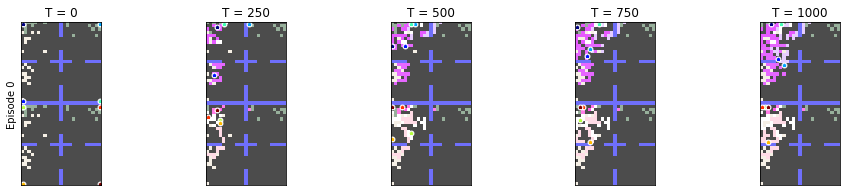

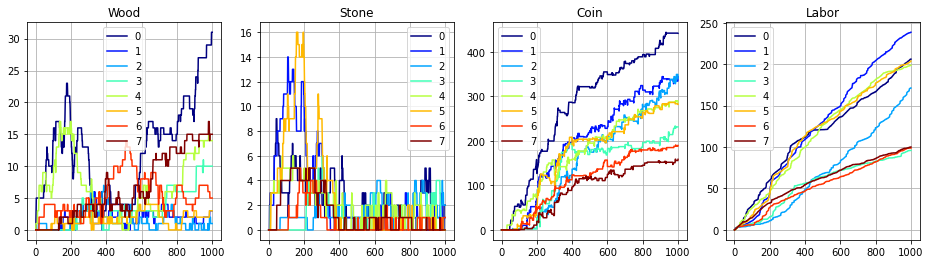

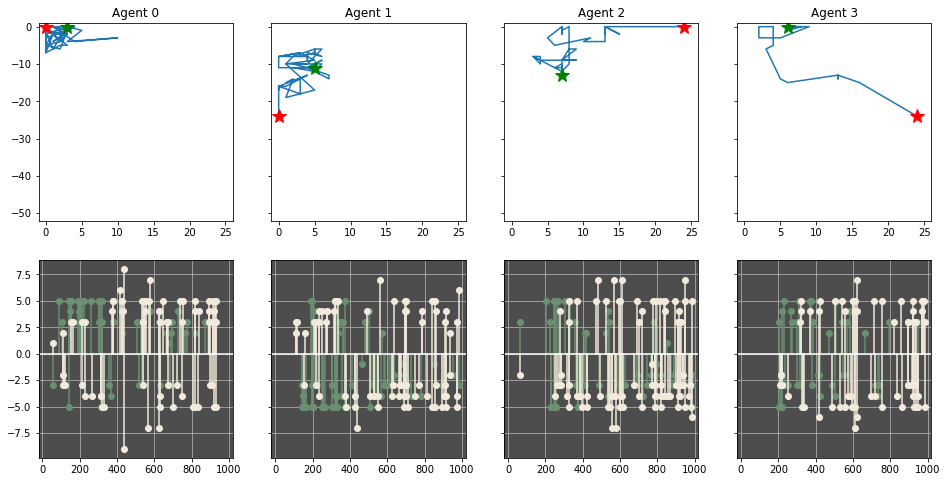

In [38]:
plotting.breakdown(dense_logs[0])

_______________:_ Agent  0 _____|_ Agent  1 _____|_ Agent  2 _____|_ Agent  3 _____|_ Agent  4 _____|_ Agent  5 _____|_ Agent  6 _____|_ Agent  7 ____
Cost (Wood)    :   3.50 (n= 10) |   3.36 (n= 36) |   3.83 (n= 59) |   3.69 (n= 55) |   3.36 (n= 33) |   3.69 (n= 26) |   3.33 (n= 21) |   3.58 (n= 24)
Cost (Stone)   :   4.32 (n= 28) |   4.31 (n= 29) |   4.03 (n= 38) |   3.95 (n= 22) |   4.02 (n= 57) |   3.52 (n= 31) |   4.25 (n= 36) |   4.50 (n= 20)

Income (Wood)  :   3.88 (n= 52) |   3.57 (n= 35) |   3.75 (n= 16) |   3.89 (n= 18) |   3.59 (n= 17) |   3.44 (n= 62) |   3.68 (n= 19) |   3.27 (n= 45)
Income (Stone) :   4.09 (n= 47) |   4.09 (n= 44) |   3.86 (n= 36) |   3.48 (n= 23) |   4.72 (n= 29) |   3.74 (n= 27) |   4.29 (n= 31) |   4.38 (n= 24)
Income (Build) :  11.00 (n= 24) |  11.00 (n= 26) |  13.00 (n= 40) |  13.00 (n= 34) |  16.00 (n= 30) |  16.00 (n=  4) |  22.00 (n=  9) |  22.00 (n=  1)


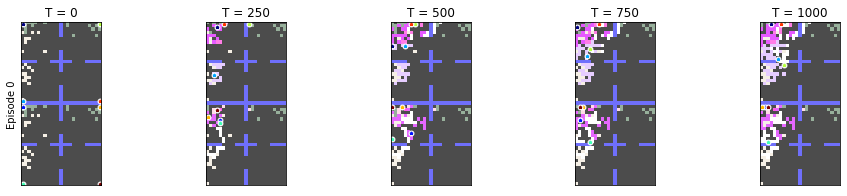

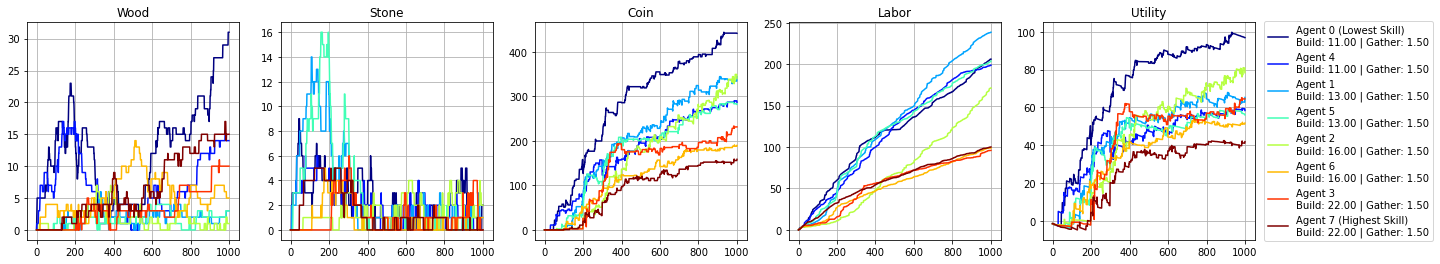

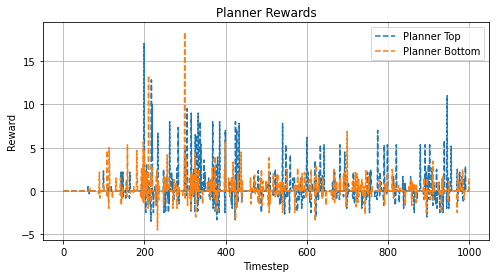

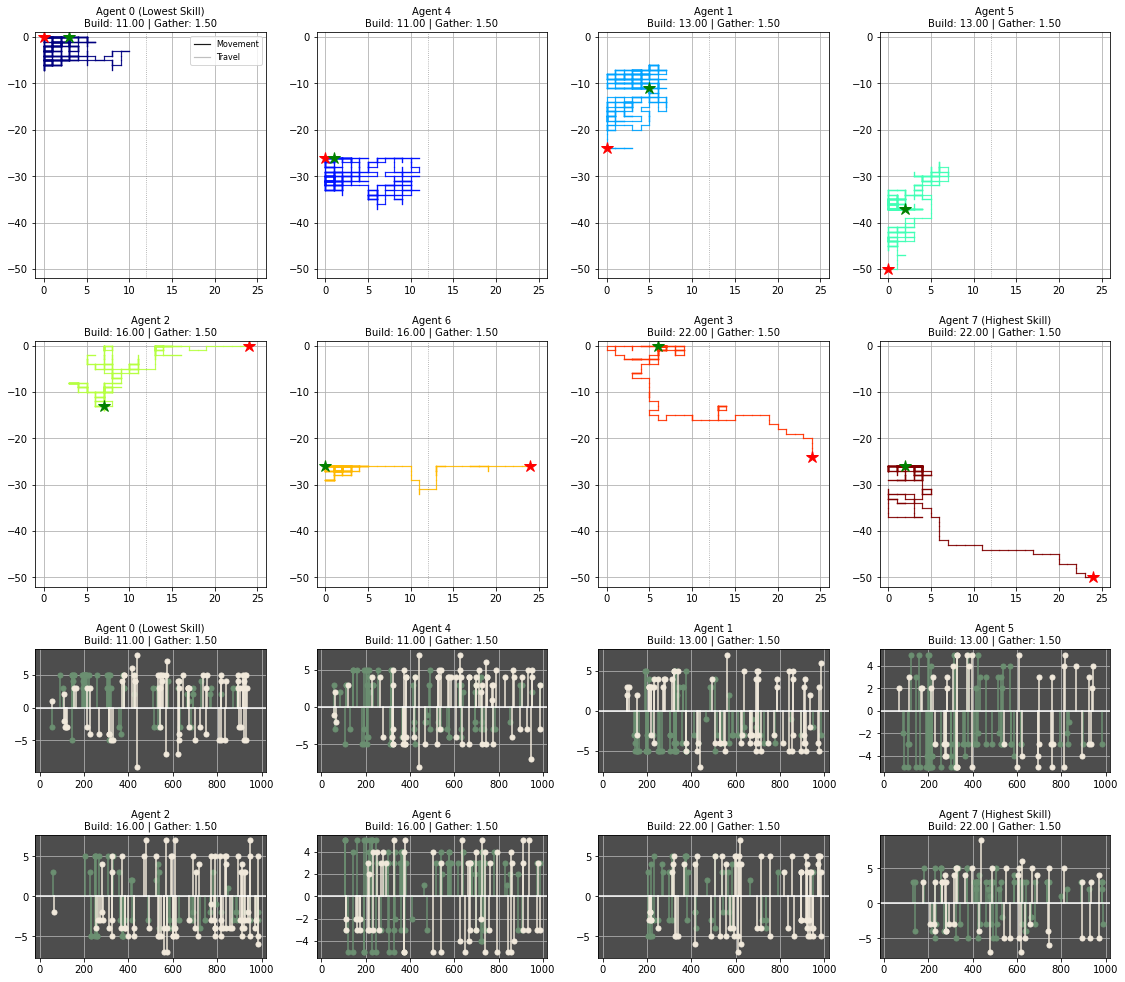

In [39]:
(fig0, fig1, fig1_planner, fig2), incomes, endows, c_trades, all_builds = plotting.breakdown_all_agents(
    dense_logs[0],
    n_cols=4,
)

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def diagnose_resource_market(log, resource="Wood", period=100):

    n_steps = len(log["states"])

    # --- trades per timestep ---
    trade_count = np.zeros(n_steps, dtype=int)
    trade_price = np.full(n_steps, np.nan)

    if "Trade" in log:
        for t, trades in enumerate(log["Trade"]):
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            resource_trades = [tr for tr in trades_ if tr.get("commodity") == resource]

            trade_count[t] = len(resource_trades)
            if len(resource_trades) > 0:
                trade_price[t] = np.mean([tr["price"] for tr in resource_trades])

    # --- inventories ---
    total_inventory = np.zeros(n_steps)
    total_escrow = np.zeros(n_steps)

    for t, state in enumerate(log["states"]):
        agents = [k for k in state.keys() if str(k).isdigit()]

        total_inventory[t] = sum(
            state[str(a)]["inventory"].get(resource, 0.0) for a in agents
        )
        total_escrow[t] = sum(
            state[str(a)]["escrow"].get(resource, 0.0) for a in agents
        )

    # --- resource on map ---
    resource_on_map = np.full(n_steps, np.nan)
    if "world" in log:
        for t in range(min(n_steps, len(log["world"]))):
            world_t = log["world"][t]
            if resource in world_t:
                resource_on_map[t] = np.sum(np.array(world_t[resource]))

    # fill missing timesteps with last known map value
    resource_on_map = pd.Series(resource_on_map).ffill().bfill().to_numpy()

    # --- builds ---
    builds_per_t = np.zeros(n_steps)
    build_income_per_t = np.zeros(n_steps)

    if "Build" in log:
        for t, builds in enumerate(log["Build"]):
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            builds_per_t[t] = len(builds_)
            build_income_per_t[t] = sum(b.get("income", 0.0) for b in builds_)

    # --- dataframe ---
    df_timestep = pd.DataFrame({
        "t": np.arange(n_steps),
        f"{resource.lower()}_trades": trade_count,
        f"{resource.lower()}_inventory_total": total_inventory,
        f"{resource.lower()}_escrow_total": total_escrow,
        f"{resource.lower()}_on_map": resource_on_map,
        "builds": builds_per_t,
        "tax_period": np.arange(n_steps) // period,
    })

    df_period = df_timestep.groupby("tax_period").agg({
        f"{resource.lower()}_trades": "sum",
        f"{resource.lower()}_inventory_total": "mean",
        f"{resource.lower()}_escrow_total": "mean",
        f"{resource.lower()}_on_map": "mean",
        "builds": "sum",
    }).reset_index()

    # =========================
    # PLOTTING
    # =========================

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # --- 1. trades ---
    axes[0].plot(df_timestep["t"], df_timestep[f"{resource.lower()}_trades"])
    axes[0].set_title(f"{resource} trades per timestep")
    axes[0].grid(True)

    # --- 2. STOCKS (FIXED) ---
    ax = axes[1]

    # left axis
    ax.plot(df_timestep["t"], df_timestep[f"{resource.lower()}_inventory_total"], label="Inventory")
    ax.plot(df_timestep["t"], df_timestep[f"{resource.lower()}_escrow_total"], label="Escrow")
    ax.set_ylabel("Inventory / Escrow")
    ax.grid(True)

    # right axis (on_map)
    if not np.all(np.isnan(df_timestep[f"{resource.lower()}_on_map"])):
        ax2 = ax.twinx()
        ax2.plot(
            df_timestep["t"],
            df_timestep[f"{resource.lower()}_on_map"],
            color="green",
            linewidth=2,
            label="On map",
        )
        ax2.set_ylabel("On map")

        # combine legends
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="best")
    else:
        ax.legend()

    ax.set_title(f"{resource} stock over time")

    # --- 3. builds ---
    axes[2].plot(df_timestep["t"], df_timestep["builds"])
    axes[2].set_title("Builds per timestep")
    axes[2].grid(True)

    # --- 4. period summary ---
    # axes[3].plot(df_period["tax_period"], df_period[f"{resource.lower()}_trades"], label="Trades / period")
    # axes[3].plot(df_period["tax_period"], df_period["builds"], label="Builds / period")
    # axes[3].set_title("Market vs building (per tax period)")
    # axes[3].legend()
    # axes[3].grid(True)
    # axes[3].set_xlabel("Tax period")

    fig.tight_layout()

    return df_timestep, df_period, fig

,tax_period,stone_trades,stone_inventory_total,stone_escrow_total,stone_on_map,builds
0,0,8,13.91,10.49,30.0,20.0
1,1,23,25.98,21.70,19.5,21.0
2,2,25,30.59,24.24,17.5,29.0
3,3,13,32.25,29.36,18.0,21.0
4,4,21,26.93,31.97,28.5,9.0
5,5,16,31.52,34.03,34.5,14.0
6,6,16,38.01,32.49,30.0,7.0
7,7,16,40.43,36.92,31.0,6.0
8,8,9,41.13,36.79,33.5,8.0
9,9,26,40.83,31.31,36.0,13.0


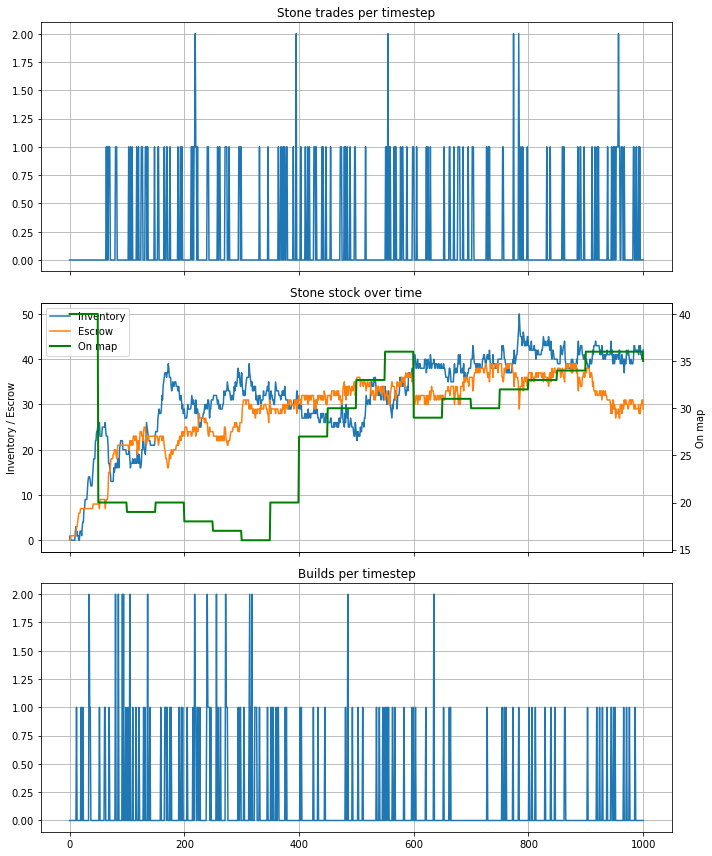

In [41]:
df_stone_t, df_stone_p, fig = diagnose_resource_market(dense_logs[1], resource="Stone", period=100)
df_stone_p

,tax_period,wood_trades,wood_inventory_total,wood_escrow_total,wood_on_map,builds
0,0,6,6.08,11.27,34.0,20.0
1,1,31,9.88,10.68,27.0,21.0
2,2,43,7.61,9.15,28.5,29.0
3,3,46,3.53,1.74,29.0,21.0
4,4,26,3.37,4.36,31.5,9.0
5,5,59,3.06,6.32,31.5,14.0
6,6,18,0.82,1.55,31.0,7.0
7,7,62,1.63,1.99,35.0,6.0
8,8,42,1.33,1.27,33.0,8.0
9,9,52,2.52,7.05,32.5,13.0


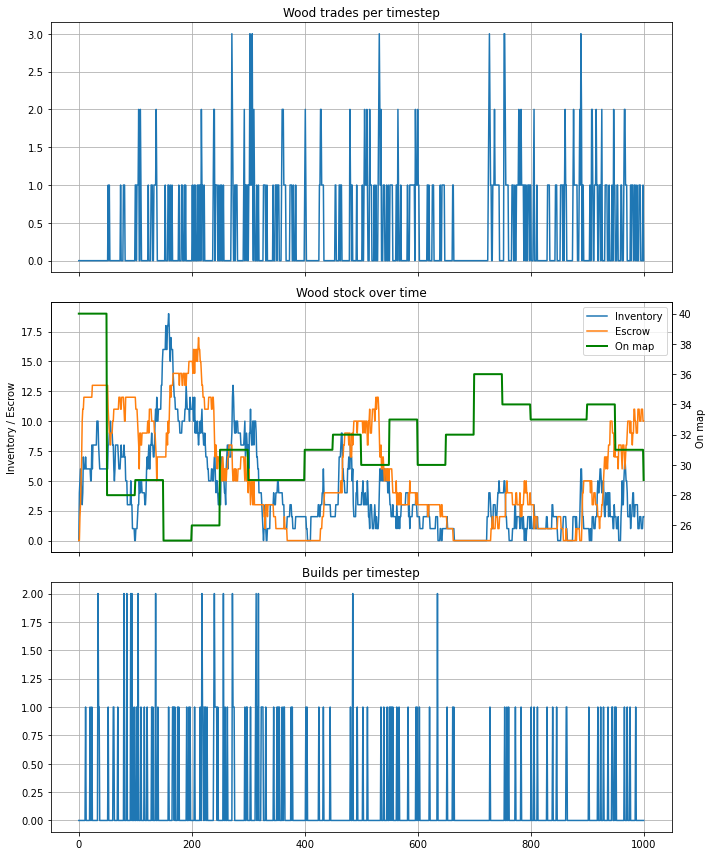

In [42]:
df_wood_t, df_wood_p, fig = diagnose_resource_market(dense_logs[1], resource="Wood", period=100)
df_wood_p

In [43]:
import numpy as np
import pandas as pd

def tax_day_income_report(
    log,
    period=100,
    bracket_cutoffs=(-np.inf, 0, 9.7, 39.475, 84.2, 160.725, 204.1, 510.3, np.inf),
    #[0,\;10,\;25,\;50,\;80,\;120,\;180,\;\infty]
):
    """
    Reconstructs per-agent income at each tax day and assigns tax brackets.

    Income is computed as change in coin endowment over the period:
        income_t = coin_t - coin_{t-period}

    Returns:
        df_agent: one row per agent per tax day
        df_counts: number of agents in each bracket at each tax day
    """

    def total_coin(state, aid):
        return (
            state[str(aid)]["inventory"].get("Coin", 0.0)
            + state[str(aid)]["escrow"].get("Coin", 0.0)
        )

    def get_region(state, aid):
        # Prefer explicit region if present
        if "region" in state[str(aid)]:
            return state[str(aid)]["region"]
        # fallback from row location
        row = state[str(aid)]["loc"][0]
        waterline = 25  # for 51x25 world split at row 25
        return "top" if row < waterline else "bottom"

    def bracket_label(x, cutoffs):
        for i in range(len(cutoffs) - 1):
            lo, hi = cutoffs[i], cutoffs[i + 1]
            if lo <= x < hi:
                hi_label = "inf" if np.isinf(hi) else f"{hi:.3f}"
                return f"[{lo:.3f}, {hi_label})"
        return "unknown"

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted([int(k) for k in first_state.keys() if str(k).isdigit()])

    # tax day assumed at end of each period: period-1, 2*period-1, ...
    tax_days = list(range(period - 1, len(states), period))

    rows = []
    prev_snapshot_idx = 0

    for td_idx, t in enumerate(tax_days):
        state_t = states[t]
        state_prev = states[prev_snapshot_idx]

        for aid in agent_ids:
            coin_now = total_coin(state_t, aid)
            coin_prev = total_coin(state_prev, aid)
            income = coin_now - coin_prev

            rows.append({
                "tax_day_number": td_idx + 1,
                "timestep": t,
                "agent": aid,
                "region": get_region(state_t, aid),
                "coin_start": coin_prev,
                "coin_end": coin_now,
                "income": income,
                "tax_bracket": bracket_label(income, bracket_cutoffs),
            })

        prev_snapshot_idx = t

    df_agent = pd.DataFrame(rows)

    df_counts = (
        df_agent.groupby(["tax_day_number", "region", "tax_bracket"])
        .size()
        .reset_index(name="n_agents")
        .sort_values(["tax_day_number", "region", "tax_bracket"])
    )

    return df_agent, df_counts

df_income, df_tax_counts = tax_day_income_report(dense_logs[0], period=100)
df_income.head(20)
df_tax_counts

,tax_day_number,region,tax_bracket,n_agents
0,1,bottom,"[0.000, 9.700)",1
1,1,top,"[0.000, 9.700)",5
2,1,top,"[39.475, 84.200)",2
3,2,bottom,"[0.000, 9.700)",1
4,2,top,"[0.000, 9.700)",1
5,2,top,"[39.475, 84.200)",2
6,2,top,"[84.200, 160.725)",1
7,2,top,"[9.700, 39.475)",3
8,3,bottom,"[39.475, 84.200)",1
9,3,top,"[39.475, 84.200)",3


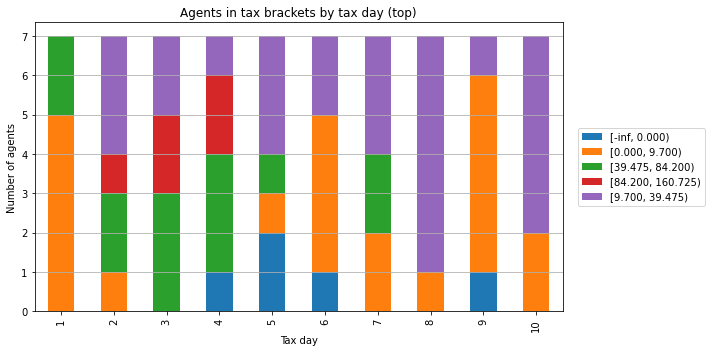

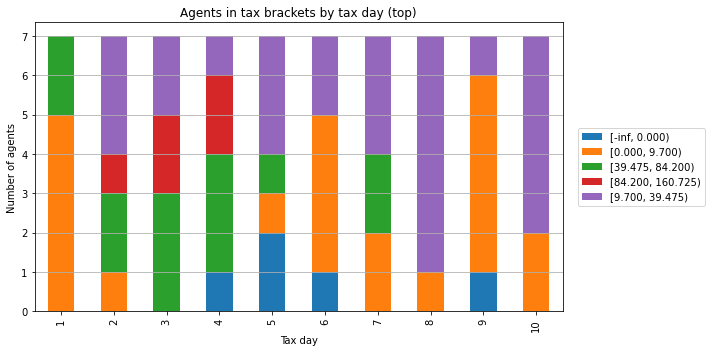

In [44]:
import matplotlib.pyplot as plt

def plot_tax_group_counts(df_counts, region=None):
    df = df_counts.copy()
    if region is not None:
        df = df[df["region"] == region]

    pivot = df.pivot_table(
        index="tax_day_number",
        columns="tax_bracket",
        values="n_agents",
        aggfunc="sum",
        fill_value=0,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax)

    title = "Agents in tax brackets by tax day"
    if region is not None:
        title += f" ({region})"
    ax.set_title(title)
    ax.set_xlabel("Tax day")
    ax.set_ylabel("Number of agents")
    ax.grid(True, axis="y")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    return fig, pivot

fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")
fig, pivot = plot_tax_group_counts(df_tax_counts, region="top")

In [45]:
import numpy as np
import pandas as pd

def inventory_table_by_tax_period(log, period=100, include_escrow=True):
    """
    Build a table of agent inventories at the end of each tax period.

    Parameters
    ----------
    log : dict
        Dense log with log["states"]
    period : int
        Tax period length
    include_escrow : bool
        If True, also include escrow and total (= inventory + escrow)

    Returns
    -------
    df : pd.DataFrame
        One row per (tax_period, agent)
    """
    states = log["states"]
    n_steps = len(states)

    # tax-day indices: 99, 199, 299, ...
    tax_end_steps = list(range(period - 1, n_steps, period))

    rows = []

    for tax_day_number, t in enumerate(tax_end_steps, start=1):
        state = states[t]

        agent_ids = sorted(int(k) for k in state.keys() if str(k).isdigit())

        for aid in agent_ids:
            s = state[str(aid)]

            inv = s.get("inventory", {})
            esc = s.get("escrow", {})

            row = {
                "tax_day_number": tax_day_number,
                "timestep": t,
                "agent": aid,
                "region": s.get("region", None),
                "coin_inventory": inv.get("Coin", 0.0),
                "wood_inventory": inv.get("Wood", 0.0),
                "stone_inventory": inv.get("Stone", 0.0),
            }

            if include_escrow:
                row.update({
                    "coin_escrow": esc.get("Coin", 0.0),
                    "wood_escrow": esc.get("Wood", 0.0),
                    "stone_escrow": esc.get("Stone", 0.0),
                    "coin_total": inv.get("Coin", 0.0) + esc.get("Coin", 0.0),
                    "wood_total": inv.get("Wood", 0.0) + esc.get("Wood", 0.0),
                    "stone_total": inv.get("Stone", 0.0) + esc.get("Stone", 0.0),
                })

            rows.append(row)

    df = pd.DataFrame(rows)
    return df

In [46]:
df_inv = inventory_table_by_tax_period(dense_logs[0], period=100, include_escrow=True)
df_inv

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,top,57.000000,10.0,0.0,1.0,4.0,3.0,58.000000,14.0,3.0
1,1,99,1,top,0.000000,0.0,6.0,0.0,0.0,5.0,0.000000,0.0,11.0
2,1,99,2,bottom,0.000000,0.0,0.0,1.0,0.0,1.0,1.000000,0.0,1.0
3,1,99,3,top,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1,99,4,top,43.000000,5.0,0.0,2.0,3.0,5.0,45.000000,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,top,226.400625,5.0,0.0,5.0,5.0,0.0,231.400625,10.0,0.0
76,10,999,4,top,289.221328,9.0,0.0,1.0,5.0,0.0,290.221328,14.0,0.0
77,10,999,5,top,275.586328,1.0,0.0,8.0,2.0,0.0,283.586328,3.0,0.0
78,10,999,6,top,183.141328,1.0,0.0,5.0,4.0,1.0,188.141328,5.0,1.0


In [47]:
coin_pivot = df_inv.pivot(index="tax_day_number", columns="agent", values="coin_total")
coin_pivot

agent,0,1,2,3,4,5,6,7
tax_day_number,,,,,,,,
1,58.000000,0.000000,1.000000,0.000000,45.000000,8.000000,0.000000,0.000000
2,158.063437,78.312187,3.312187,2.312187,72.640312,45.786563,48.786563,10.786563
3,210.943437,143.052188,51.002188,88.002188,157.268828,108.678828,77.678828,32.373516
4,287.048437,196.037188,117.427188,193.487188,157.241953,208.201953,112.730703,93.825391
5,322.010938,218.899687,181.639688,169.449687,205.159766,200.948516,119.748516,117.143203
6,355.258750,228.347500,205.806250,168.587500,209.093203,204.155703,156.905703,117.845391
7,378.241250,291.240000,258.288750,183.230000,250.408203,224.915703,163.470703,126.205391
8,389.151875,324.531875,282.480625,185.835625,268.268828,264.233828,179.988828,144.508516
9,423.239375,328.219375,312.118125,195.423125,274.971328,271.936328,177.691328,153.401016


In [48]:
df_inv.sort_values(["tax_day_number", "agent"]).reset_index(drop=True)

,tax_day_number,timestep,agent,region,coin_inventory,wood_inventory,stone_inventory,coin_escrow,wood_escrow,stone_escrow,coin_total,wood_total,stone_total
0,1,99,0,top,57.000000,10.0,0.0,1.0,4.0,3.0,58.000000,14.0,3.0
1,1,99,1,top,0.000000,0.0,6.0,0.0,0.0,5.0,0.000000,0.0,11.0
2,1,99,2,bottom,0.000000,0.0,0.0,1.0,0.0,1.0,1.000000,0.0,1.0
3,1,99,3,top,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1,99,4,top,43.000000,5.0,0.0,2.0,3.0,5.0,45.000000,8.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,10,999,3,top,226.400625,5.0,0.0,5.0,5.0,0.0,231.400625,10.0,0.0
76,10,999,4,top,289.221328,9.0,0.0,1.0,5.0,0.0,290.221328,14.0,0.0
77,10,999,5,top,275.586328,1.0,0.0,8.0,2.0,0.0,283.586328,3.0,0.0
78,10,999,6,top,183.141328,1.0,0.0,5.0,4.0,1.0,188.141328,5.0,1.0


# comparison plots

In [ ]:
import os

BASE_RESULTS_DIR = "results"

selected_folders = [
    "travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109",
    "travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel_20260413_172725"
    
]

run_dirs = [
    os.path.join(BASE_RESULTS_DIR, d)
    for d in selected_folders
]

all_folders = sorted(os.listdir(BASE_RESULTS_DIR))
for i, folder in enumerate(all_folders):
    print(f"{i}: {folder}")

selected_idx = [0, 1, 2]

run_dirs_idx = [
    os.path.join(BASE_RESULTS_DIR, all_folders[i])
    for i in selected_idx
]

print(run_dirs)

0: travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109
1: travel-off__regionaltrade-on__layout-stacked_51x25__baseline_20260401_155830
2: travel-on__regionaltrade-off__layout-stacked_51x25_symetric__baseline_20260409_225435
3: travel-on__regionaltrade-off__layout-stacked_51x25_symetric__baseline_20260411_161143
4: travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel_20260413_172725
5: travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260401_211748
6: travel-on__regionaltrade-on__layout-stacked_51x25__baseline_20260402_105108
7: travel-on__regionaltrade-on__layout-stacked_51x25_symetric__baseline_20260407_193321
8: travel-on__regionaltrade-on__layout-stacked_51x25_symetric__baseline_20260409_110631
['results\\travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline_20260412_222109', 'results\\travel-on__regionaltrade-off__layout-stacked_51x25_symetric_or

In [200]:
def load_experiment_run(run_dir):
    with open(os.path.join(run_dir, "summary.json"), "r") as f:
        summary = json.load(f)

    metrics = pd.read_csv(os.path.join(run_dir, "training_metrics.csv"))

    with open(os.path.join(run_dir, "dense_logs_final.pkl"), "rb") as f:
        dense_logs = pickle.load(f)

    # choose one representative dense log for single-rollout plots
    if isinstance(dense_logs, dict) and 0 in dense_logs:
        dense_log = dense_logs[0]
    else:
        dense_log = dense_logs

    return {
        "run_dir": run_dir,
        "name": summary.get("experiment_name", os.path.basename(run_dir)),
        "summary": summary,
        "metrics": metrics,
        "dense_logs": dense_logs,   # all dense logs
        "dense_log": dense_log,     # one example dense log
    }
def load_experiment_runs(run_dirs):
    return [load_experiment_run(rd) for rd in run_dirs]

In [201]:
runs = load_experiment_runs(run_dirs)

In [ ]:
#runs = plotting.load_experiment_runs(run_dirs)

print([r["name"] for r in runs])

['travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline', 'travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel']


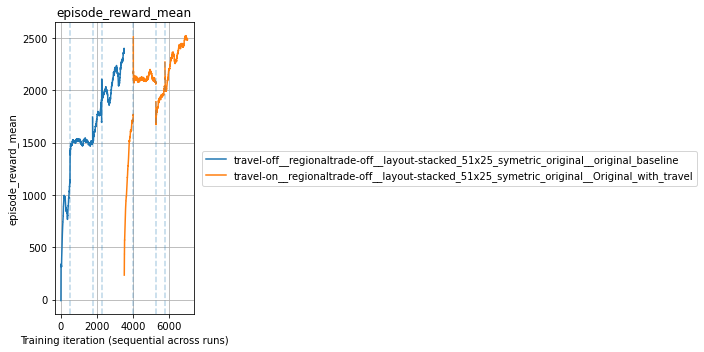

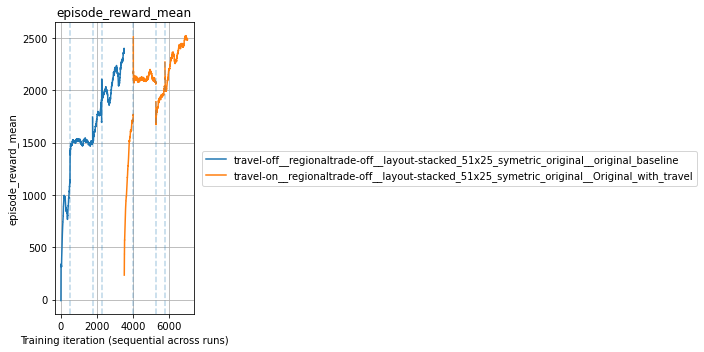

In [51]:
plotting.compare_training_curves(runs, metric="episode_reward_mean", by_phase=False)

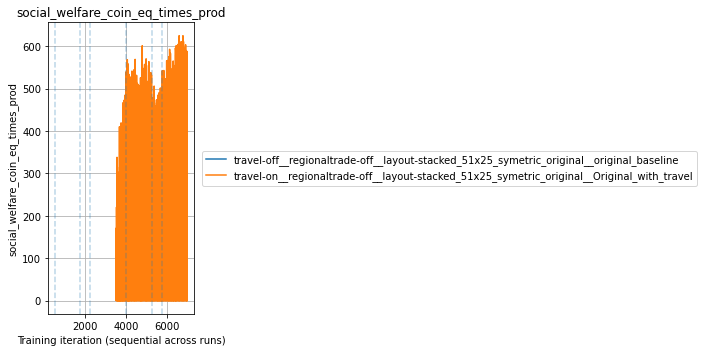

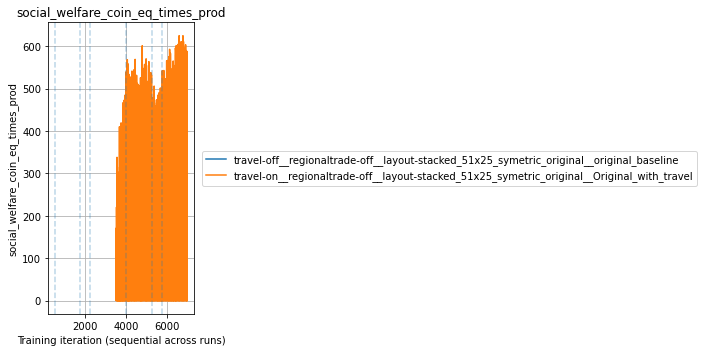

In [52]:
plotting.compare_training_curves(
    runs,
    metric="social_welfare_coin_eq_times_prod",
    by_phase=False
)

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_training_curves(
    runs,
    metric="episode_reward_mean",
    by_phase=False,
    show_phase_boundaries=True,
    short_labels=None,
    smooth_window=1,
    figsize=(10, 5),
):
    """
    Compare training curves across runs on a shared x-axis.

    Parameters
    ----------
    runs : list of dicts
        Each run must contain:
            run["name"]
            run["metrics"]   # DataFrame with columns ["phase", "iter", metric]

    metric : str
        Metric column to plot.

    by_phase : bool
        If True, plot each phase separately for each run.
        If False, concatenate phases into one cumulative training curve per run.

    show_phase_boundaries : bool
        Draw vertical lines between phases.

    short_labels : None, list, or dict
        Short legend labels. If None, uses "Run 1", "Run 2", ...

    smooth_window : int
        Rolling mean window for smoothing. Use 1 for no smoothing.

    figsize : tuple
        Figure size.
    """

    phase_order = ["PHASE 1", "PHASE 2", "PHASE 3A", "PHASE 3B"]

    # Build labels
    run_names = [run["name"] for run in runs]
    if short_labels is None:
        short_labels = {name: f"Run {i+1}" for i, name in enumerate(run_names)}
    elif isinstance(short_labels, list):
        short_labels = {name: short_labels[i] for i, name in enumerate(run_names)}

    # Better contrast than default
    colors = [
        "#1f77b4",  # blue
        "#d62728",  # red
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#8c564b",  # brown
    ]
    linestyles = ["-", "--", "-.", ":", (0, (5, 2)), (0, (3, 1, 1, 1))]

    fig, ax = plt.subplots(figsize=figsize)

    all_boundaries = None
    max_x = 0

    for i, run in enumerate(runs):
        df = run["metrics"].copy()

        if metric not in df.columns:
            print(f"Skipping {run['name']}: metric '{metric}' not found.")
            continue

        df["phase"] = pd.Categorical(df["phase"], categories=phase_order, ordered=True)
        df = df.sort_values(["phase", "iter"]).reset_index(drop=True)

        color = colors[i % len(colors)]
        linestyle = linestyles[i % len(linestyles)]
        label = short_labels[run["name"]]

        cumulative_offset = 0
        x_all = []
        y_all = []
        boundaries = []

        for phase in phase_order:
            sdf = df[df["phase"] == phase].copy()
            if sdf.empty:
                continue

            y_phase = sdf[metric].astype(float).to_numpy()

            if smooth_window > 1 and len(y_phase) >= smooth_window:
                y_phase = (
                    pd.Series(y_phase)
                    .rolling(window=smooth_window, min_periods=1, center=False)
                    .mean()
                    .to_numpy()
                )

            x_phase = np.arange(len(sdf)) + cumulative_offset

            if by_phase:
                ax.plot(
                    x_phase,
                    y_phase,
                    color=color,
                    linestyle=linestyle,
                    linewidth=2,
                    alpha=0.95,
                    label=f"{label} | {phase}",
                )
            else:
                x_all.extend(x_phase.tolist())
                y_all.extend(y_phase.tolist())

            cumulative_offset = x_phase[-1] + 1
            boundaries.append(cumulative_offset)

        if not by_phase and len(x_all) > 0:
            ax.plot(
                x_all,
                y_all,
                color=color,
                linestyle=linestyle,
                linewidth=2,
                alpha=0.95,
                label=label,
            )

        max_x = max(max_x, cumulative_offset)

        if all_boundaries is None:
            all_boundaries = boundaries

    # Draw phase boundaries once
    if show_phase_boundaries and all_boundaries is not None:
        for b in all_boundaries[:-1]:
            ax.axvline(b, linestyle="--", alpha=0.35, color="gray", linewidth=1)

    # Nicer labels
    pretty_title = metric.replace("_", " ").title()
    ax.set_title(pretty_title)
    ax.set_xlabel("Training iteration (cumulative across phases)")
    ax.set_ylabel(pretty_title)
    ax.grid(True, alpha=0.3)

    # Keep x-axis tight to data
    ax.set_xlim(0, max_x if max_x > 0 else 1)

    # Put legend below, not to the side
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=min(3, len(labels)),
            frameon=True,
            fontsize=10,
        )
        fig.tight_layout(rect=[0, 0.08, 1, 1])
    else:
        fig.tight_layout()

    return fig

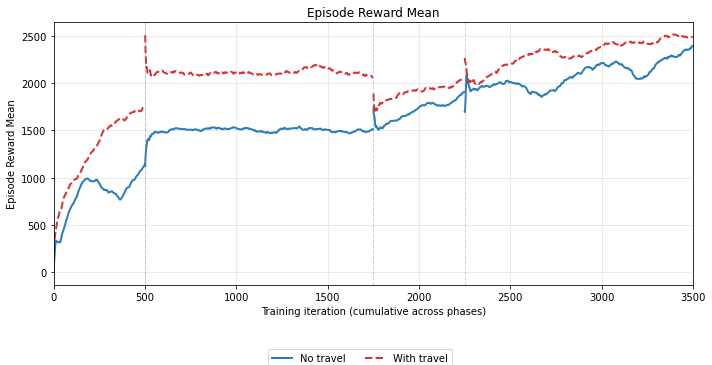

In [211]:
fig = compare_training_curves(
    runs,
    metric="episode_reward_mean",
    short_labels=["No travel", "With travel"],
    smooth_window=5,
)

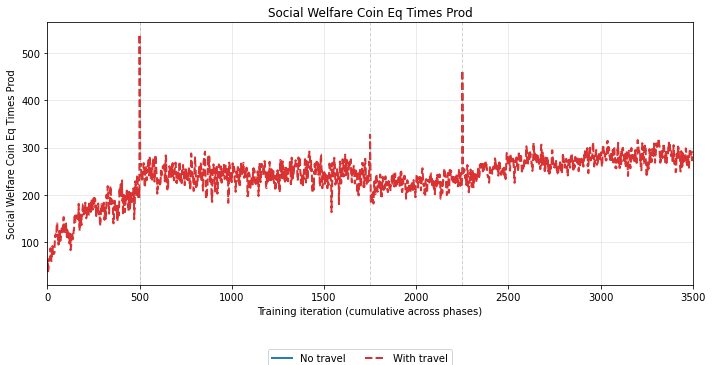

In [210]:
fig = compare_training_curves(
    runs,
    metric="social_welfare_coin_eq_times_prod",
    short_labels=["No travel", "With travel"],
    smooth_window=5,
)

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


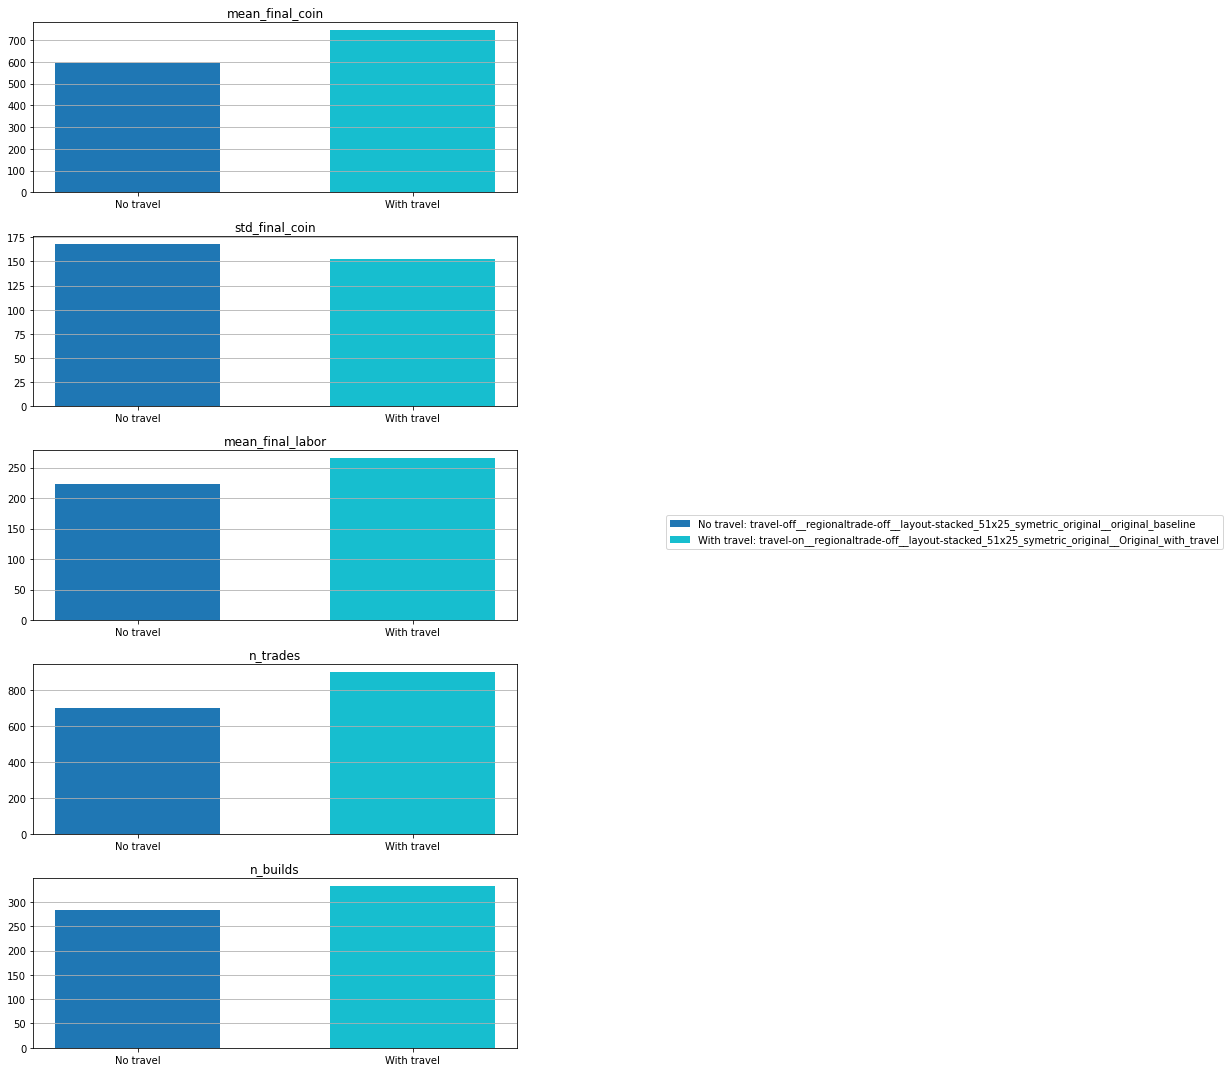

In [ ]:


fig, out_df = plotting.compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",   # or "sem"
)

out_df

In [192]:
def compare_summary_bars(
    runs,
    metrics=None,
    short_labels=None,
    show_legend=True,
    errorbar="std",   # "std", "sem", or None
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    if metrics is None:
        metrics = [
            "mean_final_coin",
            "std_final_coin",
            "mean_final_labor",
            "n_trades",
            "n_builds",
        ]

    def summarize_one_dense_log(log):
        states = log["states"]
        last_state = states[-1]

        agent_ids = sorted([int(k) for k in last_state.keys() if str(k).isdigit()])

        final_coin = []
        final_labor = []

        for aid in agent_ids:
            s = last_state[str(aid)]
            coin = s["inventory"]["Coin"] + s["escrow"]["Coin"]
            labor = s["endogenous"]["Labor"]

            final_coin.append(float(coin))
            final_labor.append(float(labor))

        n_trades = 0
        if "Trade" in log:
            for t in log["Trade"]:
                trades = t.get("trades", []) if isinstance(t, dict) else t
                n_trades += len(trades)

        n_builds = 0
        if "Build" in log:
            for t in log["Build"]:
                builds = t.get("builds", []) if isinstance(t, dict) else t
                n_builds += len(builds)

        return {
            "mean_final_coin": float(np.mean(final_coin)) if final_coin else np.nan,
            "std_final_coin": float(np.std(final_coin)) if final_coin else np.nan,
            "mean_final_labor": float(np.mean(final_labor)) if final_labor else np.nan,
            "n_trades": float(n_trades),
            "n_builds": float(n_builds),
        }

    def extract_episode_logs(dense_logs_obj):
        if dense_logs_obj is None:
            return []

        if isinstance(dense_logs_obj, list):
            if len(dense_logs_obj) > 0 and isinstance(dense_logs_obj[0], dict):
                return dense_logs_obj
            return []

        if isinstance(dense_logs_obj, dict):
            if "states" in dense_logs_obj:
                return [dense_logs_obj]

            vals = list(dense_logs_obj.values())
            if len(vals) > 0 and isinstance(vals[0], dict):
                return vals

        return []

    # Main summary dataframe
    summary_df = pd.DataFrame(
        [{"name": r["name"], **r["summary"]} for r in runs]
    ).set_index("name")

    metrics = [m for m in metrics if m in summary_df.columns]
    run_names = list(summary_df.index)

    if short_labels is None:
        short_labels = {name: f"E{i+1}" for i, name in enumerate(run_names)}
    elif isinstance(short_labels, list):
        short_labels = {name: short_labels[i] for i, name in enumerate(run_names)}

    colors_list = [
        "#1f77b4",  # blue
        "#d62728",  # red
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#8c564b",  # brown
    ]
    colors = {name: colors_list[i % len(colors_list)] for i, name in enumerate(run_names)}

    # Compute episode-level metric variability for each run
    err_lookup = {name: {} for name in run_names}

    for run in runs:
        run_name = run["name"]

        dense_logs_obj = None
        for key in ["dense_logs", "dense_log", "logs"]:
            if key in run:
                dense_logs_obj = run[key]
                break

        eps = extract_episode_logs(dense_logs_obj)
        if len(eps) == 0:
            continue

        ep_rows = []
        for ep in eps:
            try:
                ep_rows.append(summarize_one_dense_log(ep))
            except Exception:
                continue

        if len(ep_rows) == 0:
            continue

        ep_df = pd.DataFrame(ep_rows)

        for metric in metrics:
            if metric not in ep_df.columns:
                err_lookup[run_name][metric] = np.nan
                continue

            vals = ep_df[metric].dropna().to_numpy(dtype=float)
            if len(vals) == 0:
                err_lookup[run_name][metric] = np.nan
            elif errorbar == "std":
                err_lookup[run_name][metric] = float(np.std(vals))
            elif errorbar == "sem":
                err_lookup[run_name][metric] = float(np.std(vals) / np.sqrt(len(vals)))
            else:
                err_lookup[run_name][metric] = np.nan

    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 3 * len(metrics)), squeeze=False)

    for i, metric in enumerate(metrics):
        ax = axes[i, 0]

        vals = summary_df[metric]
        x = np.arange(len(vals))
        yerr = np.array([err_lookup[name].get(metric, np.nan) for name in vals.index], dtype=float)

        ax.bar(
            x,
            vals.values,
            color=[colors[name] for name in vals.index],
            width=0.6,
            alpha=0.9,
            yerr=None if errorbar is None else yerr,
            capsize=5 if errorbar is not None else 0,
            ecolor="black",
        )

        ax.set_title(metric.replace("_", " ").title())
        ax.set_xticks(x)
        ax.set_xticklabels([short_labels[name] for name in vals.index])
        ax.grid(True, axis="y", alpha=0.3)

    if show_legend:
        legend_handles = [
            Patch(facecolor=colors[name], label=f"{short_labels[name]}")
            for name in run_names
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=min(3, len(run_names)),
            frameon=True,
            fontsize=10,
        )

        fig.subplots_adjust(bottom=0.15, top=0.95)
    else:
        fig.tight_layout()

    out_df = summary_df.copy()
    out_df.insert(0, "label", [short_labels[name] for name in out_df.index])

    return fig, out_df

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


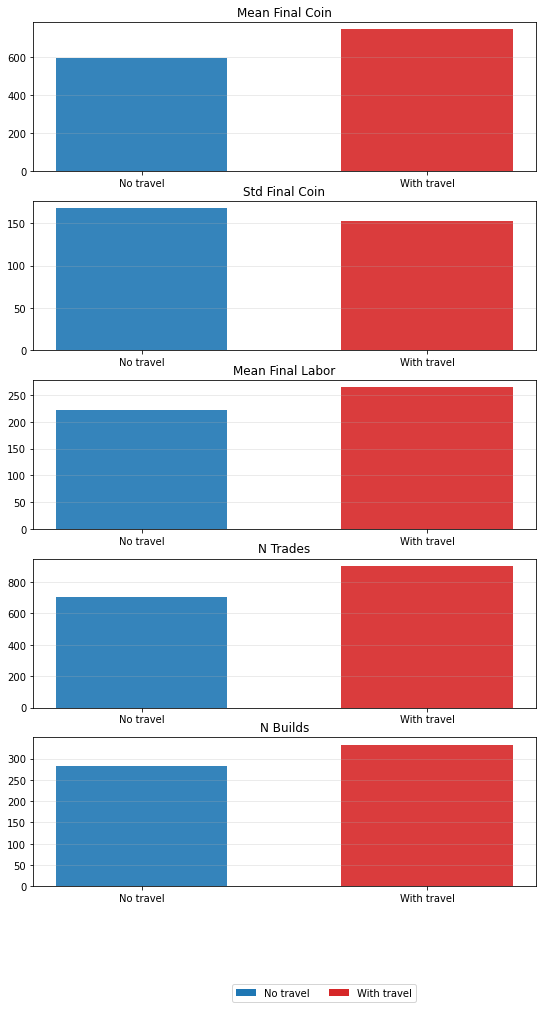

In [206]:
fig_single, out_single = compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar=None,   # 🚨 KEY
)

out_single

,label,mean_final_coin,std_final_coin,mean_final_labor,n_trades,n_builds,total_build_income,n_travel,n_top_final,n_bottom_final,experiment_name,phase1_iters,phase2_iters,phase3a_iters,phase3b_iters
name,,,,,,,,,,,,,,,
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,594.875,167.696632,222.51875,703,283,4759.0,0,6,2,travel-off__regionaltrade-off__layout-stacked_...,500,1250,500,1250
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,743.625,152.040979,265.31625,903,333,5949.0,48,6,2,travel-on__regionaltrade-off__layout-stacked_5...,500,1250,500,1250


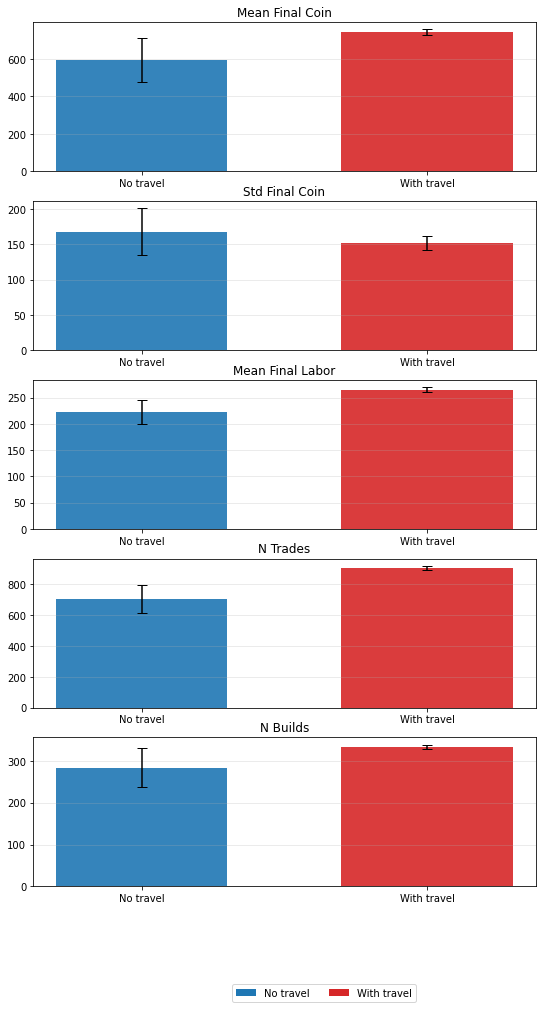

In [207]:
fig_avg, out_avg = compare_summary_bars(
    runs,
    metrics=[
        "mean_final_coin",
        "std_final_coin",
        "mean_final_labor",
        "n_trades",
        "n_builds",
    ],
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",   # 🚨 KEY
)

out_avg

In [195]:
for run in runs:
    dense_logs_obj = run.get("dense_logs", run.get("dense_log", run.get("logs", None)))
    print(run["name"], type(dense_logs_obj))

    if isinstance(dense_logs_obj, dict):
        print("dict keys sample:", list(dense_logs_obj.keys())[:5])
    elif isinstance(dense_logs_obj, list):
        print("list length:", len(dense_logs_obj))

travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline <class 'dict'>
dict keys sample: ['world', 'states', 'actions', 'rewards', 'Build']
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel <class 'dict'>
dict keys sample: ['world', 'states', 'actions', 'rewards', 'Build']


In [196]:
for run in runs:
    print("\nRUN:", run["name"])

    dense_logs_obj = run.get("dense_logs", run.get("dense_log", run.get("logs", None)))
    eps = dense_logs_obj.values() if isinstance(dense_logs_obj, dict) else dense_logs_obj

    vals = []
    for ep in eps:
        try:
            last_state = ep["states"][-1]
            agent_ids = sorted(int(k) for k in last_state if str(k).isdigit())
            final_coin = [
                last_state[str(a)]["inventory"]["Coin"] + last_state[str(a)]["escrow"]["Coin"]
                for a in agent_ids
            ]
            vals.append(np.mean(final_coin))
        except Exception:
            pass

    print("n episodes used:", len(vals))
    print("values:", vals)
    if len(vals) > 1:
        print("std:", np.std(vals))


RUN: travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline
n episodes used: 0
values: []

RUN: travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel
n episodes used: 0
values: []


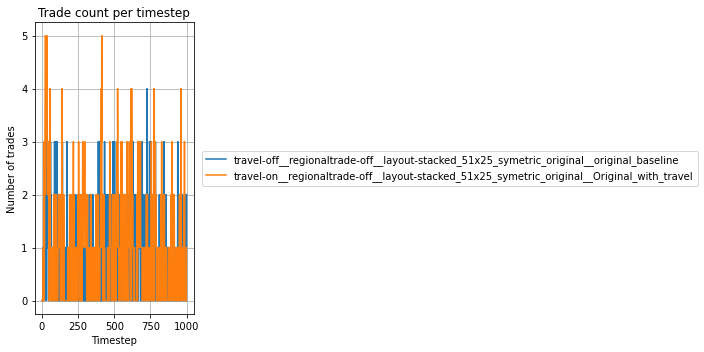

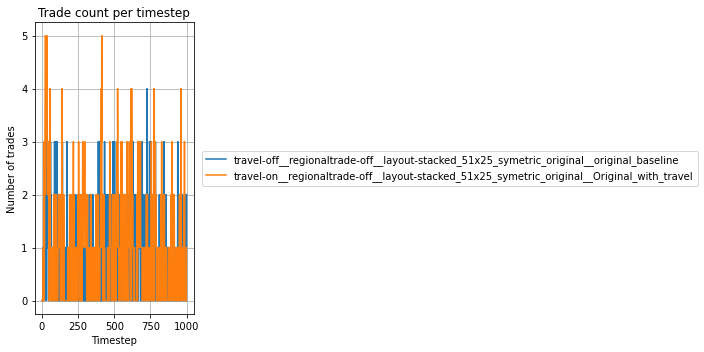

In [54]:
#plotting.compare_region_dynamics(runs)
plotting.compare_trade_dynamics(runs)

In [212]:
def compare_gini(
    runs,
    short_labels=None,
    show_legend=True,
    mode="single",      # "single" or "average"
    errorbar=None,      # None, "std", or "sem"
    figsize=(7, 4),
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    def gini(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return np.nan
        if np.sum(x) <= 0:
            return np.nan
        x = np.sort(x)
        n = len(x)
        return (2 * np.sum((np.arange(1, n + 1) * x))) / (n * np.sum(x)) - (n + 1) / n

    def extract_episode_logs(obj):
        if obj is None:
            return []

        # single episode
        if isinstance(obj, dict) and "states" in obj:
            return [obj]

        # dict of episodes
        if isinstance(obj, dict):
            vals = list(obj.values())
            return [v for v in vals if isinstance(v, dict) and "states" in v]

        # list of episodes
        if isinstance(obj, list):
            return [v for v in obj if isinstance(v, dict) and "states" in v]

        return []

    def gini_from_one_log(log):
        final_state = log["states"][-1]
        coins = []

        for k, s in final_state.items():
            if str(k).isdigit():
                coins.append(
                    float(s["inventory"]["Coin"]) + float(s["escrow"]["Coin"])
                )

        return gini(np.array(coins, dtype=float))

    run_names = [run["name"] for run in runs]

    if short_labels is None:
        short_labels = {name: f"E{i+1}" for i, name in enumerate(run_names)}
    elif isinstance(short_labels, list):
        short_labels = {name: short_labels[i] for i, name in enumerate(run_names)}

    # Same palette as other plots
    colors_list = [
        "#1f77b4",  # blue
        "#d62728",  # red
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#8c564b",  # brown
        "#e377c2",  # pink
        "#17becf",  # cyan
    ]
    colors = {name: colors_list[i % len(colors_list)] for i, name in enumerate(run_names)}

    values = {}
    errors = {}
    n_used = {}

    for run in runs:
        name = run["name"]

        if mode == "single":
            log = run.get("dense_log", None)
            if log is None and "dense_logs" in run:
                eps = extract_episode_logs(run["dense_logs"])
                log = eps[0] if len(eps) > 0 else None

            val = gini_from_one_log(log) if log is not None else np.nan
            values[name] = val
            errors[name] = np.nan
            n_used[name] = 1 if np.isfinite(val) else 0

        elif mode == "average":
            dense_logs_obj = run.get("dense_logs", None)
            if dense_logs_obj is None and "dense_log" in run:
                dense_logs_obj = run["dense_log"]

            eps = extract_episode_logs(dense_logs_obj)
            gini_vals = []

            for ep in eps:
                try:
                    gini_vals.append(gini_from_one_log(ep))
                except Exception:
                    continue

            gini_vals = np.array(gini_vals, dtype=float)
            gini_vals = gini_vals[np.isfinite(gini_vals)]

            if len(gini_vals) == 0:
                values[name] = np.nan
                errors[name] = np.nan
                n_used[name] = 0
            else:
                values[name] = float(np.mean(gini_vals))
                n_used[name] = len(gini_vals)

                if errorbar == "std":
                    errors[name] = float(np.std(gini_vals))
                elif errorbar == "sem":
                    errors[name] = float(np.std(gini_vals) / np.sqrt(len(gini_vals)))
                else:
                    errors[name] = np.nan
        else:
            raise ValueError("mode must be 'single' or 'average'")

    df = pd.Series(values, name="gini")
    err = pd.Series(errors, name="error")

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(df))
    yerr = None if errorbar is None else err.values

    ax.bar(
        x,
        df.values,
        color=[colors[name] for name in df.index],
        width=0.6,
        alpha=0.9,
        yerr=yerr,
        capsize=5 if errorbar is not None else 0,
        ecolor="black",
        error_kw={"elinewidth": 2.0, "capthick": 2.0},
    )

    if mode == "single":
        ax.set_title("Gini Coefficient (Final Wealth, Single Rollout)")
    else:
        title = "Gini Coefficient (Final Wealth, Mean Across Dense Logs)"
        if errorbar == "std":
            title += " ± SD"
        elif errorbar == "sem":
            title += " ± SEM"
        ax.set_title(title)

    ax.set_xticks(x)
    ax.set_xticklabels([short_labels[name] for name in df.index])
    ax.set_ylabel("Gini")
    ax.grid(True, axis="y", alpha=0.3)

    if show_legend:
        legend_handles = [
            Patch(facecolor=colors[name], label=f"{short_labels[name]}")
            for name in df.index
        ]
        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=min(3, len(legend_handles)),
            frameon=True,
            fontsize=10,
        )
        fig.subplots_adjust(bottom=0.18, top=0.88)
    else:
        fig.tight_layout()

    out_df = pd.DataFrame({
        "label": [short_labels[name] for name in df.index],
        "gini": df.values,
        "error": err.values,
        "n_dense_logs": [n_used[name] for name in df.index],
    }, index=df.index)

    return fig, out_df

,label,gini,error,n_dense_logs
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,0.146544,NaN,1
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,0.102630,NaN,1


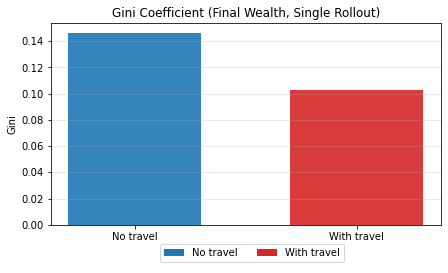

In [213]:
fig_single, out_single = compare_gini(
    runs,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    mode="single",
    errorbar=None,
)

out_single

,label,gini,error,n_dense_logs
travel-off__regionaltrade-off__layout-stacked_51x25_symetric_original__original_baseline,No travel,0.102995,0.034744,3
travel-on__regionaltrade-off__layout-stacked_51x25_symetric_original__Original_with_travel,With travel,0.112826,0.008579,3


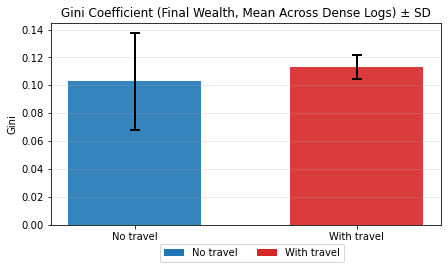

In [214]:
fig_avg, out_avg = compare_gini(
    runs,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    mode="average",
    errorbar="std",
)

out_avg

In [56]:
from simulation import get_disc_rates

def compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj,
    brackets,
    top_first=True,
    short_labels=None,
    show_legend=True,
    figsize=(8, 7),
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    def _split_last_row(arr, top_first=True):
        if arr is None or np.size(arr) == 0:
            return None, None
        last = np.asarray(arr)[-1].reshape(1, -1)
        half = last.shape[1] // 2
        if top_first:
            return last[:, :half][0], last[:, half:][0]
        else:
            return last[:, half:][0], last[:, :half][0]

    def _extract_episode_logs(dense_logs_obj):
        """
        Normalize many possible run formats into a list of episode dicts.
        """
        if dense_logs_obj is None:
            return []

        # Case 1: already a list of episode dicts
        if isinstance(dense_logs_obj, list):
            if len(dense_logs_obj) > 0 and isinstance(dense_logs_obj[0], dict):
                return dense_logs_obj
            return []

        # Case 2: dict
        if isinstance(dense_logs_obj, dict):
            # Single episode log
            if "planner_actions" in dense_logs_obj:
                return [dense_logs_obj]

            # Wrapper formats
            for key in ["episodes", "dense_logs", "logs", "data"]:
                if key in dense_logs_obj:
                    val = dense_logs_obj[key]
                    if isinstance(val, list):
                        return [x for x in val if isinstance(x, dict)]
                    if isinstance(val, dict):
                        return [v for v in val.values() if isinstance(v, dict)]

            # Dict keyed by episode ids
            vals = list(dense_logs_obj.values())
            if len(vals) > 0 and isinstance(vals[0], dict):
                return vals

        return []

    def _mean_final_schedule_from_dense_logs(dense_logs_obj):
        eps = _extract_episode_logs(dense_logs_obj)

        idx_top_list = []
        idx_bottom_list = []

        for ep in eps:
            if not isinstance(ep, dict):
                continue
            if "planner_actions" not in ep:
                continue
            if "p_top" not in ep["planner_actions"] or "p_bottom" not in ep["planner_actions"]:
                continue

            actions_top = ep["planner_actions"]["p_top"]
            actions_bot = ep["planner_actions"]["p_bottom"]

            if np.size(actions_top) == 0 or np.size(actions_bot) == 0:
                continue

            top7_last_top, _ = _split_last_row(actions_top, top_first=top_first)
            _, bottom7_last_bottom = _split_last_row(actions_bot, top_first=top_first)

            if top7_last_top is None or bottom7_last_bottom is None:
                continue

            idx_top_list.append(top7_last_top)
            idx_bottom_list.append(bottom7_last_bottom)

        if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
            return None, None

        idx_top_arr = np.stack(idx_top_list, axis=0)
        idx_bottom_arr = np.stack(idx_bottom_list, axis=0)

        #disc_rates = _get_disc_rates(env_obj)
        disc_rates = get_disc_rates(env_obj)

        top_rates_all = disc_rates[np.clip(idx_top_arr.astype(int), 0, len(disc_rates) - 1)]
        bottom_rates_all = disc_rates[np.clip(idx_bottom_arr.astype(int), 0, len(disc_rates) - 1)]

        top_rates_mean = np.mean(top_rates_all, axis=0)
        bottom_rates_mean = np.mean(bottom_rates_all, axis=0)

        return top_rates_mean, bottom_rates_mean

    run_names = [run["name"] for run in runs]

    if short_labels is None:
        short_labels = {name: f"E{i+1}" for i, name in enumerate(run_names)}
    elif isinstance(short_labels, list):
        short_labels = {name: short_labels[i] for i, name in enumerate(run_names)}

    cmap = plt.get_cmap("tab10", max(len(runs), 1))
    colors = {run["name"]: cmap(i) for i, run in enumerate(runs)}

    #disc_rates = _get_disc_rates(env_obj)
    disc_rates = get_disc_rates(env_obj)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    summary_rows = []

    for run in runs:
        run_name = run["name"]

        dense_logs_obj = None
        for key in ["dense_logs", "dense_log", "logs"]:
            if key in run:
                dense_logs_obj = run[key]
                break

        if dense_logs_obj is None:
            print(f"Skipping {run_name}: no dense_log(s) found.")
            continue

        top_rates_mean, bottom_rates_mean = _mean_final_schedule_from_dense_logs(dense_logs_obj)

        if top_rates_mean is None or bottom_rates_mean is None:
            print(f"Skipping {run_name}: could not find planner_actions/p_top/p_bottom in this run.")
            continue

        color = colors[run_name]
        label = short_labels[run_name]

        axes[0].step(brackets, top_rates_mean, where="post", color=color, linewidth=2, label=label)
        axes[1].step(brackets, bottom_rates_mean, where="post", color=color, linewidth=2, label=label)

        summary_rows.append({
            "run": run_name,
            "label": label,
            "top_schedule": top_rates_mean,
            "bottom_schedule": bottom_rates_mean,
        })

    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region) - average final schedule")
    axes[0].set_ylim(0, 1.05 * np.max(disc_rates))
    axes[0].grid(True)

    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region) - average final schedule")
    axes[1].set_xlabel("Income bracket")
    axes[1].set_ylim(0, 1.05 * np.max(disc_rates))
    axes[1].grid(True)

    if show_legend:
        legend_handles = [
            Line2D([0], [0], color=colors[name], lw=2, label=f"{short_labels[name]}: {name}")
            for name in run_names
        ]
        fig.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
        )
        fig.tight_layout(rect=[0, 0, 0.82, 1])
    else:
        fig.tight_layout()

    out_df = pd.DataFrame(summary_rows)
    return fig, out_df

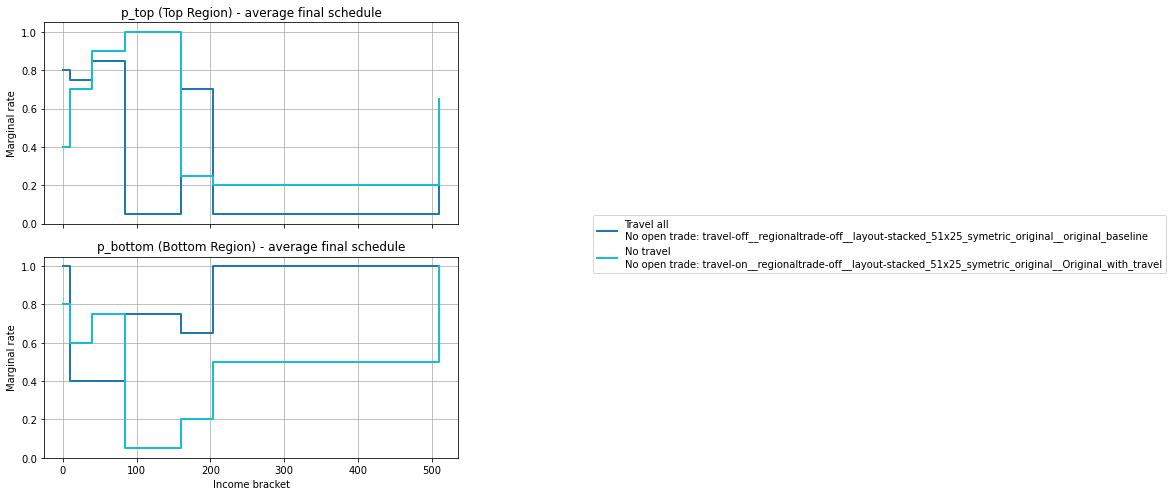

In [57]:
usd_scaling = 1000 #1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling


fig, out_df = compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    short_labels=["Travel all\nNo open trade", "No travel\nNo open trade"],
)

In [ ]:
from simulation import get_disc_rates

def compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj,
    brackets,
    top_first=True,
    short_labels=None,
    show_legend=True,
    figsize=(10, 7),
    errorbar="std",        # "std", "sem", or None
    last_bin_width=None,   # width used to extend the final bracket
    capsize=5,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    def _split_last_row(arr, top_first=True):
        if arr is None or np.size(arr) == 0:
            return None, None
        last = np.asarray(arr)[-1].reshape(1, -1)
        half = last.shape[1] // 2
        if top_first:
            return last[:, :half][0], last[:, half:][0]
        else:
            return last[:, half:][0], last[:, :half][0]

    def _extract_episode_logs(dense_logs_obj):
        if dense_logs_obj is None:
            return []

        if isinstance(dense_logs_obj, list):
            if len(dense_logs_obj) > 0 and isinstance(dense_logs_obj[0], dict):
                return dense_logs_obj
            return []

        if isinstance(dense_logs_obj, dict):
            if "planner_actions" in dense_logs_obj:
                return [dense_logs_obj]

            for key in ["episodes", "dense_logs", "logs", "data"]:
                if key in dense_logs_obj:
                    val = dense_logs_obj[key]
                    if isinstance(val, list):
                        return [x for x in val if isinstance(x, dict)]
                    if isinstance(val, dict):
                        return [v for v in val.values() if isinstance(v, dict)]

            vals = list(dense_logs_obj.values())
            if len(vals) > 0 and isinstance(vals[0], dict):
                return vals

        return []

    def _final_schedule_stats_from_dense_logs(dense_logs_obj):
        eps = _extract_episode_logs(dense_logs_obj)

        idx_top_list = []
        idx_bottom_list = []

        for ep in eps:
            if not isinstance(ep, dict):
                continue
            if "planner_actions" not in ep:
                continue
            if "p_top" not in ep["planner_actions"] or "p_bottom" not in ep["planner_actions"]:
                continue

            actions_top = ep["planner_actions"]["p_top"]
            actions_bot = ep["planner_actions"]["p_bottom"]

            if np.size(actions_top) == 0 or np.size(actions_bot) == 0:
                continue

            top_last, _ = _split_last_row(actions_top, top_first=top_first)
            _, bottom_last = _split_last_row(actions_bot, top_first=top_first)

            if top_last is None or bottom_last is None:
                continue

            idx_top_list.append(top_last)
            idx_bottom_list.append(bottom_last)

        if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
            return None

        idx_top_arr = np.stack(idx_top_list, axis=0)
        idx_bottom_arr = np.stack(idx_bottom_list, axis=0)

        disc_rates = get_disc_rates(env_obj)

        top_rates_all = disc_rates[np.clip(idx_top_arr.astype(int), 0, len(disc_rates) - 1)]
        bottom_rates_all = disc_rates[np.clip(idx_bottom_arr.astype(int), 0, len(disc_rates) - 1)]

        top_mean = np.mean(top_rates_all, axis=0)
        bottom_mean = np.mean(bottom_rates_all, axis=0)

        if errorbar == "std":
            top_err = np.std(top_rates_all, axis=0)
            bottom_err = np.std(bottom_rates_all, axis=0)
        elif errorbar == "sem":
            top_err = np.std(top_rates_all, axis=0) / np.sqrt(top_rates_all.shape[0])
            bottom_err = np.std(bottom_rates_all, axis=0) / np.sqrt(bottom_rates_all.shape[0])
        else:
            top_err = None
            bottom_err = None

        return {
            "top_mean": top_mean,
            "bottom_mean": bottom_mean,
            "top_err": top_err,
            "bottom_err": bottom_err,
            "n_episodes": len(idx_top_list),
        }

    run_names = [run["name"] for run in runs]

    if short_labels is None:
        short_labels = {name: f"E{i+1}" for i, name in enumerate(run_names)}
    elif isinstance(short_labels, list):
        short_labels = {name: short_labels[i] for i, name in enumerate(run_names)}

    brackets = np.asarray(brackets, dtype=float)
    disc_rates = get_disc_rates(env_obj)

    if last_bin_width is None:
        last_bin_width = brackets[-1] - brackets[-2]

    right_edge = brackets[-1] + last_bin_width
    step_x = np.append(brackets, right_edge)

    centers = np.empty(len(brackets))
    centers[:-1] = 0.5 * (brackets[:-1] + brackets[1:])
    centers[-1] = 0.5 * (brackets[-1] + right_edge)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle("Average Final Marginal Tax Schedules Across Runs", fontsize=14, y=0.98)

    summary_rows = []

    # high-contrast palette + distinct linestyles
    colors_list = [
        "#1f77b4",  # blue
        "#d62728",  # red
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#8c564b",  # brown
        "#e377c2",  # pink
        "#17becf",  # cyan
    ]
    linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1)), (0, (4, 1, 1, 1))]

    plotted_names = []

    for i, run in enumerate(runs):
        run_name = run["name"]

        dense_logs_obj = None
        for key in ["dense_logs", "dense_log", "logs"]:
            if key in run:
                dense_logs_obj = run[key]
                break

        if dense_logs_obj is None:
            print(f"Skipping {run_name}: no dense_log(s) found.")
            continue

        stats = _final_schedule_stats_from_dense_logs(dense_logs_obj)
        if stats is None:
            print(f"Skipping {run_name}: could not find planner_actions/p_top/p_bottom in this run.")
            continue

        color = colors_list[i % len(colors_list)]
        linestyle = linestyles[i % len(linestyles)]
        label = short_labels[run_name]

        top_step_y = np.append(stats["top_mean"], stats["top_mean"][-1])
        bottom_step_y = np.append(stats["bottom_mean"], stats["bottom_mean"][-1])

        # small horizontal offset so error bars from multiple runs do not sit exactly on top of each other
        if len(runs) > 1:
            offset_scale = 0.015 * (right_edge - brackets[0])
            offset = (i - (len(runs) - 1) / 2.0) * offset_scale
        else:
            offset = 0.0
        centers_offset = centers + offset

        # Top region
        axes[0].step(
            step_x,
            top_step_y,
            where="post",
            color=color,
            linestyle=linestyle,
            linewidth=2.2,
            alpha=0.95,
            label=label,
            zorder=2,
        )
        axes[0].fill_between(
            step_x,
            top_step_y,
            step="post",
            alpha=0.10,
            color=color,
            zorder=1,
        )

        if stats["top_err"] is not None:
            axes[0].errorbar(
                centers_offset,
                stats["top_mean"],
                yerr=stats["top_err"],
                fmt="o",
                color=color,
                ecolor=color,
                elinewidth=2.2,
                capsize=capsize,
                markersize=4.5,
                markeredgewidth=0.0,
                alpha=1.0,
                zorder=5,
            )

        # Bottom region
        axes[1].step(
            step_x,
            bottom_step_y,
            where="post",
            color=color,
            linestyle=linestyle,
            linewidth=2.2,
            alpha=0.95,
            label=label,
            zorder=2,
        )
        axes[1].fill_between(
            step_x,
            bottom_step_y,
            step="post",
            alpha=0.10,
            color=color,
            zorder=1,
        )

        if stats["bottom_err"] is not None:
            axes[1].errorbar(
                centers_offset,
                stats["bottom_mean"],
                yerr=stats["bottom_err"],
                fmt="o",
                color=color,
                ecolor=color,
                elinewidth=2.2,
                capsize=capsize,
                markersize=4.5,
                markeredgewidth=0.0,
                alpha=1.0,
                zorder=5,
            )

        plotted_names.append(run_name)

        summary_rows.append({
            "run": run_name,
            "label": label,
            "n_episodes": stats["n_episodes"],
            "top_schedule": stats["top_mean"],
            "bottom_schedule": stats["bottom_mean"],
            "top_error": stats["top_err"],
            "bottom_error": stats["bottom_err"],
        })

    ymax = 1.05 * np.max(disc_rates)

    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region)")
    axes[0].set_ylim(0, ymax)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region)")
    axes[1].set_xlabel("Income (k USD)")
    axes[1].set_ylim(0, ymax)
    axes[1].grid(True, alpha=0.3)

    axes[1].set_xlim(brackets[0], right_edge)

    if show_legend:
        legend_handles = []
        for i, name in enumerate(run_names):
            if name not in plotted_names:
                continue
            color = colors_list[i % len(colors_list)]
            linestyle = linestyles[i % len(linestyles)]
            legend_handles.append(
                Line2D(
                    [0], [0],
                    color=color,
                    linestyle=linestyle,
                    lw=2.2,
                    label=f"{short_labels[name]}"
                )
            )

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=min(2, max(1, len(legend_handles))),
            frameon=True,
            fontsize=10,
        )

        fig.subplots_adjust(bottom=0.22, top=0.90)
    else:
        fig.subplots_adjust(bottom=0.10, top=0.90)

    out_df = pd.DataFrame(summary_rows)
    return fig, out_df

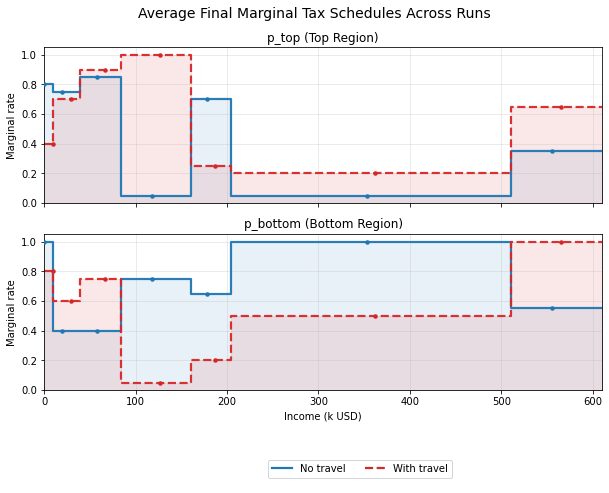

In [ ]:
fig, out_df = compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels = ["No travel", "With travel"],
    show_legend=True,
    errorbar="std",
    last_bin_width=100,
)

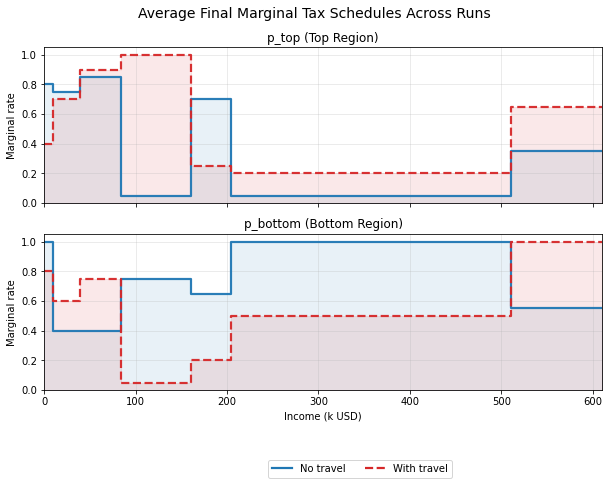

In [208]:
runs_single = []
for r in runs:
    r_copy = r.copy()
    r_copy["dense_logs"] = {0: r["dense_log"]}  # only one log
    runs_single.append(r_copy)

fig_single, out_single = compare_avg_final_tax_schedules_two_planners(
    runs_single,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar=None,  
    last_bin_width=100,
)

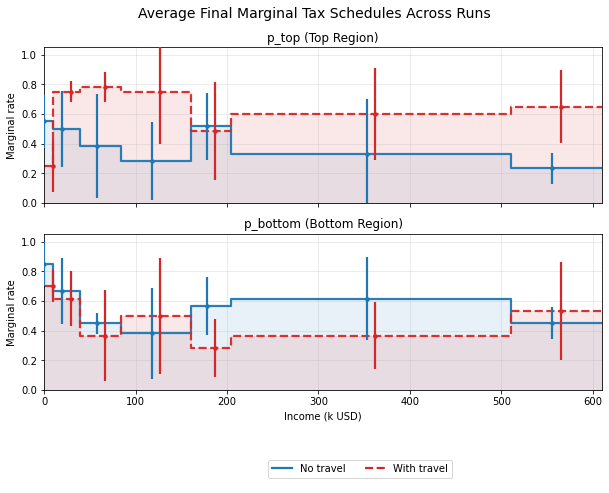

In [209]:
fig_avg, out_avg = compare_avg_final_tax_schedules_two_planners(
    runs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    short_labels=["No travel", "With travel"],
    show_legend=True,
    errorbar="std",  
    last_bin_width=100,
)

# Figuring out agent movement

In [58]:
import numpy as np

def diagnose_agent_activity(dense_log):
    states = dense_log["states"]
    n_steps = len(states) - 1

    agent_ids = sorted([k for k in states[0].keys() if str(k).isdigit()], key=int)

    # Movement per agent
    move_per_agent = {}
    for aid in agent_ids:
        d = 0.0
        for t in range(1, len(states)):
            p0 = np.array(states[t-1][aid]["loc"], dtype=float)
            p1 = np.array(states[t][aid]["loc"], dtype=float)
            d += np.abs(p1 - p0).sum()
        move_per_agent[aid] = d

    # Final inventories
    final_coin = {}
    final_wood = {}
    final_stone = {}
    final_labor = {}
    for aid in agent_ids:
        s = states[-1][aid]
        final_coin[aid] = float(s["inventory"]["Coin"] + s["escrow"]["Coin"])
        final_wood[aid] = float(s["inventory"]["Wood"] + s["escrow"]["Wood"])
        final_stone[aid] = float(s["inventory"]["Stone"] + s["escrow"]["Stone"])
        final_labor[aid] = float(s["endogenous"]["Labor"])

    # Build count
    build_events = dense_log.get("Build", [])
    n_builds = 0
    for x in build_events:
        if isinstance(x, dict):
            n_builds += len(x.get("builds", []))
        else:
            n_builds += len(x)

    # Trade count
    trade_events = dense_log.get("Trade", [])
    n_trades = 0
    for x in trade_events:
        if isinstance(x, dict):
            n_trades += len(x.get("trades", []))
        else:
            n_trades += len(x)

    # Gather count, if present
    gather_events = dense_log.get("Gather", [])
    n_gathers = 0
    for x in gather_events:
        if isinstance(x, dict):
            # try common keys
            if "gathers" in x:
                n_gathers += len(x["gathers"])
            elif "events" in x:
                n_gathers += len(x["events"])
            else:
                n_gathers += 0
        elif isinstance(x, list):
            n_gathers += len(x)

    print("=== Activity summary ===")
    print("steps:", n_steps)
    print("total builds:", n_builds)
    print("total trades:", n_trades)
    print("total gathers:", n_gathers)
    print("avg movement per agent:", np.mean(list(move_per_agent.values())))
    print("movement per agent:", move_per_agent)
    print("final coin:", final_coin)
    print("final wood:", final_wood)
    print("final stone:", final_stone)
    print("final labor:", final_labor)
    print("total final coin:", sum(final_coin.values()))
    print("total final wood:", sum(final_wood.values()))
    print("total final stone:", sum(final_stone.values()))

    return {
        "steps": n_steps,
        "n_builds": n_builds,
        "n_trades": n_trades,
        "n_gathers": n_gathers,
        "move_per_agent": move_per_agent,
        "final_coin": final_coin,
        "final_wood": final_wood,
        "final_stone": final_stone,
        "final_labor": final_labor,
    }

In [59]:
stats = diagnose_agent_activity(dense_logs[0])

=== Activity summary ===
steps: 1000
total builds: 168
total trades: 525
total gathers: 286
avg movement per agent: 465.625
movement per agent: {'0': 579.0, '1': 634.0, '2': 430.0, '3': 288.0, '4': 557.0, '5': 535.0, '6': 328.0, '7': 374.0}
final coin: {'0': 442.0875, '1': 344.2125, '2': 340.10875000000004, '3': 231.59124999999997, '4': 287.05632812499994, '5': 282.3713281249999, '6': 189.88132812499998, '7': 158.691015625}
final wood: {'0': 31.0, '1': 3.0, '2': 1.0, '3': 10.0, '4': 14.0, '5': 3.0, '6': 5.0, '7': 15.0}
final stone: {'0': 2.0, '1': 1.0, '2': 2.0, '3': 0.0, '4': 0.0, '5': 0.0, '6': 1.0, '7': 0.0}
final labor: {'0': 206.00000000000244, '1': 238.47000000000278, '2': 171.18000000000038, '3': 95.91999999999892, '4': 198.73000000000255, '5': 203.70000000000203, '6': 98.73999999999869, '7': 100.06999999999866}
total final coin: 2276.0
total final wood: 82.0
total final stone: 6.0


In [60]:
def diagnose_stone_wood_flows(dense_log):
    gather_stone = 0
    gather_wood = 0

    for g in dense_log.get("Gather", []):
        events = g.get("gathers", []) if isinstance(g, dict) else g
        for ev in events:
            resource = ev.get("resource", ev.get("commodity", None))
            if resource == "Stone":
                gather_stone += 1
            elif resource == "Wood":
                gather_wood += 1

    trade_sell_stone = 0
    trade_buy_stone = 0
    trade_sell_wood = 0
    trade_buy_wood = 0

    for tr in dense_log.get("Trade", []):
        events = tr.get("trades", []) if isinstance(tr, dict) else tr
        for ev in events:
            commodity = ev.get("commodity", None)
            if commodity == "Stone":
                trade_sell_stone += 1
                trade_buy_stone += 1
            elif commodity == "Wood":
                trade_sell_wood += 1
                trade_buy_wood += 1

    build_events = 0
    for b in dense_log.get("Build", []):
        events = b.get("builds", []) if isinstance(b, dict) else b
        build_events += len(events)

    print("=== Resource event counts ===")
    print("gather_stone:", gather_stone)
    print("gather_wood:", gather_wood)
    print("trade_sell_stone:", trade_sell_stone)
    print("trade_buy_stone:", trade_buy_stone)
    print("trade_sell_wood:", trade_sell_wood)
    print("trade_buy_wood:", trade_buy_wood)
    print("build_events:", build_events)

    return {
        "gather_stone": gather_stone,
        "gather_wood": gather_wood,
        "trade_sell_stone": trade_sell_stone,
        "trade_buy_stone": trade_buy_stone,
        "trade_sell_wood": trade_sell_wood,
        "trade_buy_wood": trade_buy_wood,
        "build_events": build_events,
    }

In [61]:
resource_stats = diagnose_stone_wood_flows(dense_logs[0])

=== Resource event counts ===
gather_stone: 119
gather_wood: 167
trade_sell_stone: 261
trade_buy_stone: 261
trade_sell_wood: 264
trade_buy_wood: 264
build_events: 168


In [62]:
# CKPT_EARLY = r"...\checkpoint-050"
# CKPT_LATE  = r"...\checkpoint-100"

# def rollout_from_ckpt(ckpt_path):
#     trainer = PPOTrainer(config=trainer_config_phase2)
#     trainer.restore(ckpt_path)

#     patch_trainer_envs(trainer, min_band=MIN_BAND)

#     logs = generate_rollout_with_planner_actions(
#         trainer=trainer,
#         env_obj=env_obj_phase2,
#         num_dense_logs=1,
#         explore=False,
#         decision_only=True
#     )

#     trainer.stop()
#     return logs[0]

# log_early = rollout_from_ckpt(CKPT_EARLY)
# log_late  = rollout_from_ckpt(CKPT_LATE)

# print("EARLY")
# diagnose_agent_activity(log_early)

# print("\nLATE")
# diagnose_agent_activity(log_late)

## end

# Plot


In [63]:
def plot_mobile_agent_actions(log):
    import numpy as np
    import matplotlib.pyplot as plt

    states = log["states"]
    T = len(states)

    agent_ids = sorted([k for k in states[0].keys() if str(k).isdigit()], key=int)
    n = len(agent_ids)

    # --- Movement (distance per step) ---
    movement = {aid: [] for aid in agent_ids}
    for t in range(1, T):
        for aid in agent_ids:
            p0 = np.array(states[t-1][aid]["loc"])
            p1 = np.array(states[t][aid]["loc"])
            movement[aid].append(np.abs(p1 - p0).sum())

    # --- Gather events ---
    gather_counts = np.zeros(T)
    for t, g in enumerate(log.get("Gather", [])):
        if isinstance(g, dict):
            if "gathers" in g:
                gather_counts[t] = len(g["gathers"])
        elif isinstance(g, list):
            gather_counts[t] = len(g)

    # --- Build events ---
    build_counts = np.zeros(T)
    for t, b in enumerate(log.get("Build", [])):
        if isinstance(b, dict):
            build_counts[t] = len(b.get("builds", []))
        elif isinstance(b, list):
            build_counts[t] = len(b)

    # --- Trade events ---
    trade_counts = np.zeros(T)
    for t, tr in enumerate(log.get("Trade", [])):
        if isinstance(tr, dict):
            trade_counts[t] = len(tr.get("trades", []))
        elif isinstance(tr, list):
            trade_counts[t] = len(tr)

    # =========================
    # Plot
    # =========================
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    # Movement
    for aid in agent_ids:
        axes[0].plot(movement[aid], label=f"agent {aid}")
    axes[0].set_title("Movement per step")
    axes[0].legend()
    axes[0].grid(True)

    # Gather
    axes[1].plot(gather_counts)
    axes[1].set_title("Gather events per step")
    axes[1].grid(True)

    # Build
    axes[2].plot(build_counts)
    axes[2].set_title("Build events per step")
    axes[2].grid(True)

    # Trade
    axes[3].plot(trade_counts)
    axes[3].set_title("Trade events per step")
    axes[3].set_xlabel("Timestep")
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    return fig

In [64]:
# plot_mobile_agent_actions(dense_logs[0])
# plot_mobile_agent_actions(dense_logs[2])

In [65]:
arr_top = dense_logs[0]["planner_actions"]["p_top"]
arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

print("p_top active half unique:", np.unique(arr_top[:, :7], axis=0).shape[0])
print("p_top inactive half unique:", np.unique(arr_top[:, 7:], axis=0).shape[0])

print("p_bottom inactive half unique:", np.unique(arr_bot[:, :7], axis=0).shape[0])
print("p_bottom active half unique:", np.unique(arr_bot[:, 7:], axis=0).shape[0])

print("p_top active rows:\n", arr_top[:, :7])
print("p_bottom active rows:\n", arr_bot[:, 7:])

p_top active half unique: 10
p_top inactive half unique: 10
p_bottom inactive half unique: 10
p_bottom active half unique: 10
p_top active rows:
 [[ 6 15 10  6  1  7 12]
 [ 8 17 16 20 21 18  9]
 [ 8  4 10 16 10  3  7]
 [ 2 20  7  5  6  9  1]
 [ 0 21 20  0  0 20  8]
 [16 18 17 12 16 16  4]
 [14 13 12 15  9 12 18]
 [ 3 21  8 15  7 20 14]
 [ 5 16  2  6 21 17 13]
 [14  1  4  5  7 12  1]]
p_bottom active rows:
 [[ 0  2  7 17 12 11 17]
 [19  2 11  2 14  9  1]
 [21 17 20 14 11  7  0]
 [13 15  4  8  0 12 17]
 [12  9  4 11 18 13 18]
 [15 18  6 20 21 13  8]
 [18  7 13 19 21 18 12]
 [15  1  6 19 10  8 15]
 [13 20 11 20 15 20 13]
 [ 7 14 17 21  1 11 16]]


# new code

In [66]:
# import numpy as np

# def generate_rollout_with_planner_actions(
#     trainer,
#     env_obj,
#     num_dense_logs=10,
#     explore=False,
#     log_only_tax_days=False,   # True = log only on period starts (tax decision steps)
# ):
#     """
#     Roll out episodes and record planner actions & rewards into dense_logs.
#     Deep-copies planner actions to avoid the 'same array repeated' issue.

#     Returns:
#       dense_logs: dict[ep] … includes:
#         dense_logs[ep]["planner_actions"] = {
#             "p_top":    np.ndarray[T, S],   # S=14 in your setup (top7|bottom7)
#             "p_bottom": np.ndarray[T, S],
#         }
#         dense_logs[ep]["planner_rewards"] = {"p_top": list[T], "p_bottom": list[T]}
#     """
#     # Detect tax period
#     try:
#         period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
#     except StopIteration:
#         period = 100

#     def _compute_action(policy_id, obs, state):
#         """Return (action, next_state) handling RLlib's return formats."""
#         out = trainer.compute_action(
#             observation=obs,
#             state=state,
#             policy_id=policy_id,
#             full_fetch=False,
#             explore=explore,
#         )
#         if isinstance(out, tuple):
#             if len(out) >= 2:
#                 return out[0], out[1]
#             else:
#                 return out[0], state
#         return out, state

#     dense_logs = {}

#     for ep in range(num_dense_logs):
#         obs = env_obj.reset(force_dense_logging=True)

#         agent_states = {
#             str(i): trainer.get_policy("a").get_initial_state()
#             for i in range(env_obj.env.n_agents)
#         }
#         p_top_state    = trainer.get_policy("p_top").get_initial_state()
#         p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

#         p_top_actions, p_bottom_actions = [], []
#         p_top_rewards, p_bottom_rewards = [], []

#         for t in range(env_obj.env.episode_length):
#             actions = {}

#             # Agents
#             for i in range(env_obj.env.n_agents):
#                 aid = str(i)
#                 a, ns = _compute_action("a", obs[aid], agent_states[aid])
#                 actions[aid] = a
#                 agent_states[aid] = ns

#             # Planners
#             a_top,    p_top_state    = _compute_action("p_top",    obs["p_top"],    p_top_state)
#             a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
#             actions["p_top"]    = a_top
#             actions["p_bottom"] = a_bottom

#             # Log only on tax decision steps if requested
#             should_log = True if not log_only_tax_days else (t % period == 0)

#             if should_log:
#                 # CRITICAL: deep-copy to avoid aliasing
#                 p_top_actions.append(np.array(a_top, copy=True))
#                 p_bottom_actions.append(np.array(a_bottom, copy=True))

#             # Step env
#             obs, rew, done, info = env_obj.step(actions)

#             p_top_rewards.append(rew.get("p_top", np.nan))
#             p_bottom_rewards.append(rew.get("p_bottom", np.nan))

#             if done.get("__all__", False):
#                 break

#         # Stack (or empty)
#         p_top_arr    = np.stack(p_top_actions, axis=0)    if len(p_top_actions)    else np.zeros((0, 0), dtype=np.int64)
#         p_bottom_arr = np.stack(p_bottom_actions, axis=0) if len(p_bottom_actions) else np.zeros((0, 0), dtype=np.int64)

#         # Attach to dense log
#         dense_logs[ep] = dict(env_obj.env.dense_log)
#         dense_logs[ep]["planner_actions"] = {"p_top": p_top_arr, "p_bottom": p_bottom_arr}
#         dense_logs[ep]["planner_rewards"] = {"p_top": p_top_rewards, "p_bottom": p_bottom_rewards}

#     return dense_logs

In [67]:
def _get_disc_rates(env_obj):
    """Read the discrete marginal rates from the first BracketTax component."""
    for comp in env_obj.env.components:
        if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
            return np.array(comp.disc_rates, dtype=float)
    # Fallback to 0..1 in 5% steps if not found
    return np.arange(0.0, 1.0 + 1e-9, 0.05)

def _split_top_bottom_matrix(A, top_first=True):
    """
    Split an (T, S) matrix (S=14) into two (T,7) views: top7 and bottom7.
    If S==7 (unlikely for your setup), returns (A, A) conservatively.
    """
    if A.size == 0:
        return A, A
    T, S = A.shape
    if S % 2 != 0:
        # Unexpected; best-effort: treat A as top7 and clone to bottom7
        return A, A
    half = S // 2
    if top_first:
        return A[:, :half], A[:, half:]
    else:
        return A[:, half:], A[:, :half]

In [68]:
import matplotlib.pyplot as plt

def plot_planner_tax_lines_percent_from_dense(
    dense_log,
    env_obj,
    brackets,
    period=100,
    top_first=True,
    title="Planner tax choices over time (marginal rate)",
    figsize=(14, 10),
):
    """
    7-row plot: each row = bracket; blue = p_top, orange dashed = p_bottom.
    Y-axis: marginal tax rate (0..1), mapped from env's disc_rates.
    X-axis: index of logged decisions (if you logged only tax days).
    """
    actions_top  = dense_log["planner_actions"]["p_top"]     # (T, 14)
    actions_bot  = dense_log["planner_actions"]["p_bottom"]  # (T, 14)

    # If you logged only tax days, T ~= episode_length / period
    # If you logged every step, X will be per-step index (can still plot)
    X = np.arange(actions_top.shape[0])

    # Split into top7 and bottom7
    top7_top, bottom7_top     = _split_top_bottom_matrix(actions_top, top_first=top_first)
    top7_bottom, bottom7_bottom = _split_top_bottom_matrix(actions_bot, top_first=top_first)

    # For plotting we want: p_top uses its own top7; p_bottom uses its own bottom7
    mat_top    = top7_top      # (T,7) chosen by p_top
    mat_bottom = bottom7_bottom  # (T,7) chosen by p_bottom

    # Map indices -> rates using env's disc_rates (robust)
    disc_rates = _get_disc_rates(env_obj)
    # Indices should be 0..len(disc_rates)-1; clip defensively:
    mat_top_r    = disc_rates[np.clip(mat_top,    0, len(disc_rates)-1)]
    mat_bottom_r = disc_rates[np.clip(mat_bottom, 0, len(disc_rates)-1)]

    # Plot 7 rows
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    for b in range(7):
        ax = axes[b]
        ax.plot(X, mat_top_r[:, b],    label="p_top",    lw=2, color="#1f77b4")
        ax.plot(X, mat_bottom_r[:, b], label="p_bottom", lw=2, color="#ff7f0e", ls="--")

        ax.set_ylabel(f"{brackets[b]:.2f}k")
        ax.set_ylim(0.0, 1.05*np.max(disc_rates))
        ax.grid(True, alpha=0.3)
        if b == 0:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Decision index" if actions_top.shape[0] <= (dense_log.get("world") and len(dense_log["world"])) else "Step")
    plt.tight_layout()
    plt.show()
    return fig

In [69]:
def plot_final_tax_schedules_two_planners_from_dense(
    dense_log,
    env_obj,
    brackets,
    top_first=True,
    title="Final Marginal Tax Schedules (p_top vs p_bottom)",
    figsize=(8, 7),
):
    """
    Final schedules from the last logged planner actions row.
    Step plots: top subplot = p_top; bottom subplot = p_bottom.
    """
    actions_top  = dense_log["planner_actions"]["p_top"]     # (T,14)
    actions_bot  = dense_log["planner_actions"]["p_bottom"]  # (T,14)
    if actions_top.size == 0 or actions_bot.size == 0:
        raise ValueError("No planner actions logged in dense_log.")

    last_top    = actions_top[-1]
    last_bottom = actions_bot[-1]

    # Split 14 -> 7+7
    top7_last_top, bottom7_last_top       = _split_top_bottom_matrix(last_top.reshape(1, -1), top_first=top_first)
    top7_last_bottom, bottom7_last_bottom = _split_top_bottom_matrix(last_bottom.reshape(1, -1), top_first=top_first)

    # We want p_top's top7 and p_bottom's bottom7
    idx_top    = top7_last_top[0]       # (7,)
    idx_bottom = bottom7_last_bottom[0] # (7,)

    # Map to rates
    disc_rates = _get_disc_rates(env_obj)
    top_rates    = disc_rates[np.clip(idx_top,    0, len(disc_rates)-1)]
    bottom_rates = disc_rates[np.clip(idx_bottom, 0, len(disc_rates)-1)]

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    axes[0].step(brackets, top_rates, where="post", color="#1f77b4")
    axes[0].fill_between(brackets, top_rates, step="post", alpha=0.3, color="#1f77b4")
    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region)")
    axes[0].set_ylim(0, 1.05*np.max(disc_rates))
    axes[0].grid(True)

    axes[1].step(brackets, bottom_rates, where="post", color="#ff7f0e")
    axes[1].fill_between(brackets, bottom_rates, step="post", alpha=0.3, color="#ff7f0e")
    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region)")
    axes[1].set_xlabel("Income bracket (k USD)")
    axes[1].set_ylim(0, 1.05*np.max(disc_rates))
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    return fig

In [70]:
# =========================================================
# Averege plots
# =========================================================

def plot_avg_planner_tax_lines(
    dense_logs,
    env_obj,
    brackets,
    top_first=True,
    figsize=(14, 10),
    title="Average planner tax choices (across episodes)"
):
    def _split(A):
        if A.size == 0:
            return A, A
        half = A.shape[1] // 2
        if top_first:
            return A[:, :half], A[:, half:]
        else:
            return A[:, half:], A[:, :half]

    # collect all episodes
    top_list = []
    bot_list = []

    for ep in dense_logs:
        A_top = dense_logs[ep]["planner_actions"]["p_top"]
        A_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

        if A_top.size == 0 or A_bot.size == 0:
            continue

        top7_top, _ = _split(A_top)
        _, bottom7_bot = _split(A_bot)

        top_list.append(top7_top)
        bot_list.append(bottom7_bot)

    # align lengths (in case episodes differ)
    min_T = min(a.shape[0] for a in top_list)

    top_stack = np.stack([a[:min_T] for a in top_list], axis=0)  # (E, T, 7)
    bot_stack = np.stack([a[:min_T] for a in bot_list], axis=0)

    # map indices -> rates
    def _get_disc_rates(env_obj):
        for comp in env_obj.env.components:
            if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
                return np.array(comp.disc_rates, dtype=float)
        return np.arange(0.0, 1.0 + 1e-9, 0.05)

    disc_rates = _get_disc_rates(env_obj)

    top_rates = disc_rates[np.clip(top_stack, 0, len(disc_rates)-1)]
    bot_rates = disc_rates[np.clip(bot_stack, 0, len(disc_rates)-1)]

    # average over episodes
    top_mean = np.mean(top_rates, axis=0)  # (T, 7)
    bot_mean = np.mean(bot_rates, axis=0)

    X = np.arange(top_mean.shape[0])

    # plot
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    for b in range(7):
        ax = axes[b]
        ax.plot(X, top_mean[:, b], label="p_top (avg)", lw=2)
        ax.plot(X, bot_mean[:, b], label="p_bottom (avg)", lw=2, linestyle="--")

        ax.set_ylabel(f"{brackets[b]:.2f}k")
        ax.set_ylim(0, 1.05*np.max(disc_rates))
        ax.grid(True, alpha=0.3)

        if b == 0:
            ax.legend()

    axes[-1].set_xlabel("Decision index")
    plt.tight_layout()
    plt.show()

    return fig


def plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs,
    env_obj,
    brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules (p_top vs p_bottom)",
    figsize=(8, 7),
):
    """
    Average final schedules across all dense_logs.
    Uses the last logged planner-action row from each episode.
    """
    def _split_last_row(arr, top_first=True):
        if arr.size == 0:
            return None, None
        last = arr[-1].reshape(1, -1)
        half = last.shape[1] // 2
        if top_first:
            return last[:, :half][0], last[:, half:][0]
        else:
            return last[:, half:][0], last[:, :half][0]

    idx_top_list = []
    idx_bottom_list = []

    for ep in dense_logs:
        actions_top = dense_logs[ep]["planner_actions"]["p_top"]
        actions_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

        if actions_top.size == 0 or actions_bot.size == 0:
            continue

        top7_last_top, _ = _split_last_row(actions_top, top_first=top_first)
        _, bottom7_last_bottom = _split_last_row(actions_bot, top_first=top_first)

        idx_top_list.append(top7_last_top)
        idx_bottom_list.append(bottom7_last_bottom)

    if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
        raise ValueError("No planner actions logged in dense_logs.")

    idx_top_arr = np.stack(idx_top_list, axis=0)         # (E, 7)
    idx_bottom_arr = np.stack(idx_bottom_list, axis=0)   # (E, 7)

    disc_rates = _get_disc_rates(env_obj)

    top_rates_all = disc_rates[np.clip(idx_top_arr, 0, len(disc_rates)-1)]
    bottom_rates_all = disc_rates[np.clip(idx_bottom_arr, 0, len(disc_rates)-1)]

    top_rates_mean = np.mean(top_rates_all, axis=0)
    bottom_rates_mean = np.mean(bottom_rates_all, axis=0)

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title)

    axes[0].step(brackets, top_rates_mean, where="post", color="#1f77b4")
    axes[0].fill_between(brackets, top_rates_mean, step="post", alpha=0.3, color="#1f77b4")
    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region) - average final schedule")
    axes[0].set_ylim(0, 1.05*np.max(disc_rates))
    axes[0].grid(True)

    axes[1].step(brackets, bottom_rates_mean, where="post", color="#ff7f0e")
    axes[1].fill_between(brackets, bottom_rates_mean, step="post", alpha=0.3, color="#ff7f0e")
    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region) - average final schedule")
    axes[1].set_xlabel("Income bracket (k USD)")
    axes[1].set_ylim(0, 1.05*np.max(disc_rates))
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    return fig

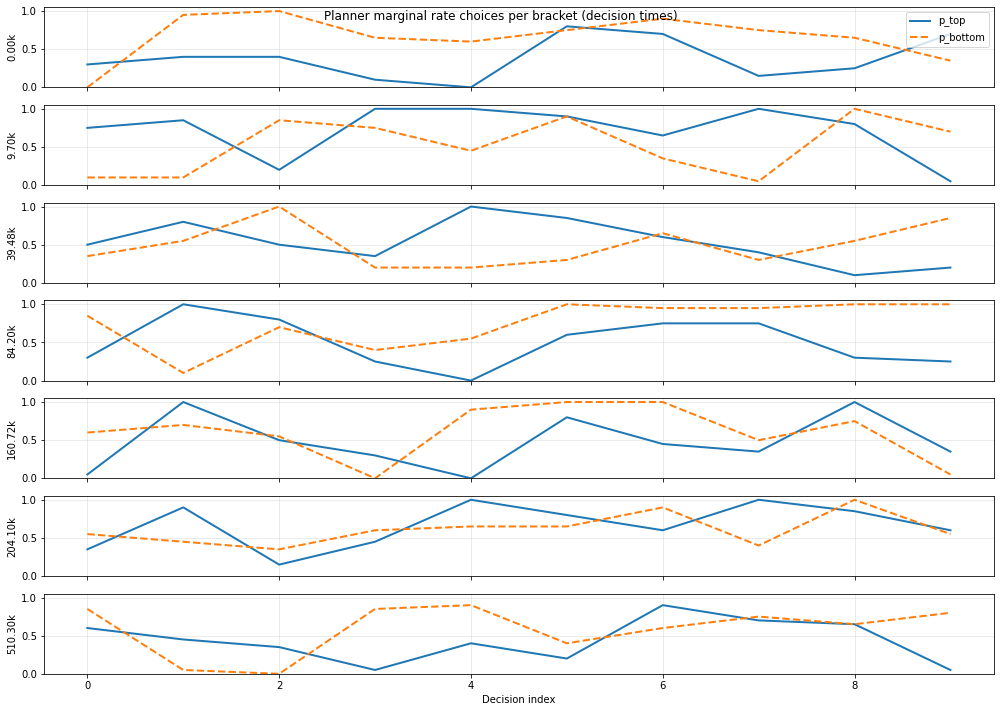

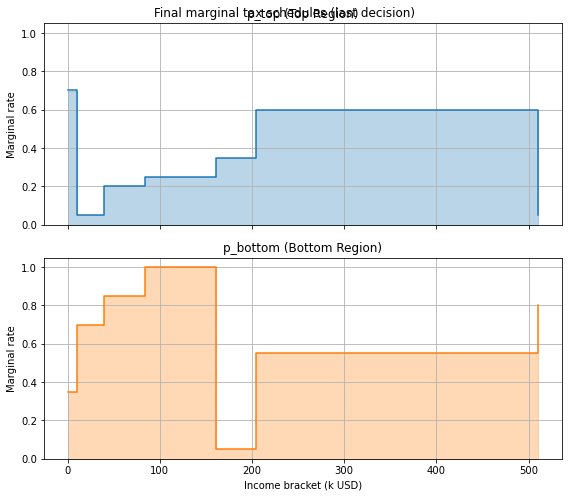

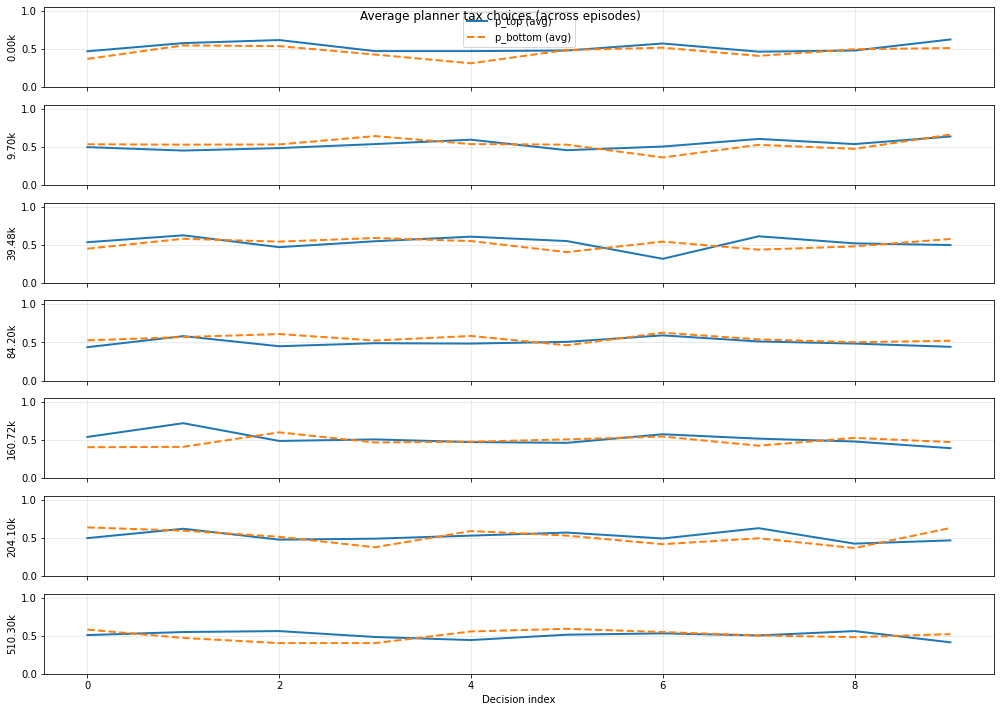

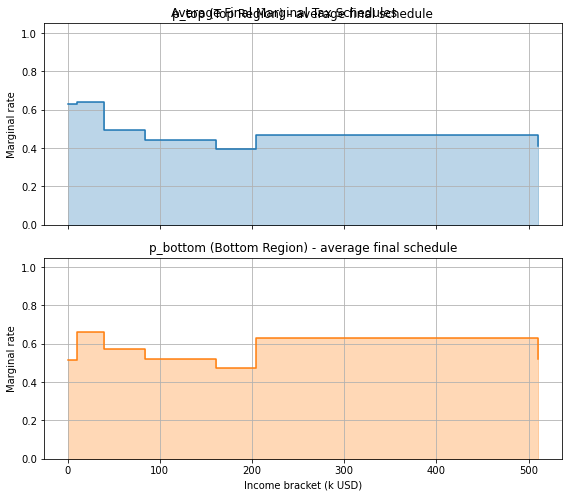

In [71]:
# import numpy as np
# import ray
# from ray.rllib.agents.ppo import PPOTrainer
# from tutorials.rllib.env_wrapper import RLlibEnvWrapper
# import matplotlib.pyplot as plt

# # =========================================================
# # CONFIG
# # =========================================================
# FRAMEWORK = "tf"

# # IMPORTANT:
# # Use a checkpoint produced by THIS exact code/config version.
# # Do NOT use an old checkpoint from before obs-space changes.
# #CKPT_PATH = r"C:\Users\adria\ray_results\PPO_RLlibEnvWrapper_2026-03-20_16-06-2092_n4vmg\checkpoint_250\checkpoint-250"
# #CKPT_PATH = r"C:\Users\adria\ray_results\...\checkpoint_1500\checkpoint-1500"
# CKPT_PATH = ckpt_phase2

# # =========================================================
# # RAY
# # =========================================================
# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# # =========================================================
# # BUILD EVAL ENV
# # =========================================================
# env_obj_phase2 = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase2},
#     verbose=False
# )

# # Patch standalone eval env
# patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)

# # =========================================================
# # POLICIES
# # =========================================================
# policies_eval = {
#     "a": (
#         None,
#         env_obj_phase2.observation_space,
#         env_obj_phase2.action_space,
#         {}
#     ),
#     "p_top": (
#         None,
#         env_obj_phase2.observation_space_pl["p_top"],
#         env_obj_phase2.action_space_pl["p_top"],
#         {}
#     ),
#     "p_bottom": (
#         None,
#         env_obj_phase2.observation_space_pl["p_bottom"],
#         env_obj_phase2.action_space_pl["p_bottom"],
#         {}
#     ),
# }

# def policy_mapping_fun_eval(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# trainer_config_phase2_eval = {
#     "env": RLlibEnvWrapper,
#     "env_config": {
#         "env_config_dict": env_config_dict_phase2,
#         "num_envs_per_worker": 1,
#     },
#     "multiagent": {
#         "policies": policies_eval,
#         "policies_to_train": [],
#         "policy_mapping_fn": policy_mapping_fun_eval,
#     },
#     "num_workers": 0,
#     "num_envs_per_worker": 1,
#     "framework": FRAMEWORK,
#     "num_gpus": 0,
#     "train_batch_size": 1000,
#     "sgd_minibatch_size": 1000,
#     "num_sgd_iter": 1,
#     "log_level": "WARN",
# }



# # =========================================================
# # RESTORE
# # =========================================================
# trainer_phase2_eval = PPOTrainer(config=trainer_config_phase2_eval)
# trainer_phase2_eval.restore(CKPT_PATH)

# # Patch restored trainer env(s) too
# patch_trainer_envs(trainer_phase2_eval, min_band=MIN_BAND)

# # =========================================================
# # ROLLOUTS
# # =========================================================
# dense_logs = generate_rollout_with_planner_actions(
#     # trainer=trainer_phase2_eval,
#     # env_obj=env_obj_phase2,
#         trainer=trainer_phase3b,
#     env_obj=env_obj_phase3b,
#     num_dense_logs=3,
#     explore=False,
#     log_only_tax_days=True,
# )

# dense_logs_explore = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2_eval,
#     env_obj=env_obj_phase2,
#     num_dense_logs=10,
#     explore=True,
#     log_only_tax_days=True,
# )

# # =========================================================
# # DEBUG PRINTS
# # =========================================================
# arr_top = dense_logs[0]["planner_actions"]["p_top"]
# arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# print("FULL p_top (#rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
# print("FULL p_bottom (#rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])

# print_active_planner_debug(dense_logs[0], top_first=True, max_rows=10)
# print_active_planner_rates(dense_logs[0], env_obj_phase2, top_first=True, max_rows=10)

# print_active_planner_debug(dense_logs_explore[0], top_first=True, max_rows=10)
# print_active_planner_rates(dense_logs_explore[0], env_obj_phase2, top_first=True, max_rows=10)

# # =========================================================
# # PLOTS
# # =========================================================
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling

fig_time = plot_planner_tax_lines_percent_from_dense(
    dense_log=dense_logs[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    title="Planner marginal rate choices per bracket (decision times)"
)

fig_final = plot_final_tax_schedules_two_planners_from_dense(
    dense_log=dense_logs[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final marginal tax schedules (last decision)"
)

# Optional averages across episodes
fig_avg_time = plot_avg_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average planner tax choices (across episodes)"
)

fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules"
)

# # Optional activity check
# stats = diagnose_agent_activity(dense_logs_explore[0])

# # Optional cleanup
# # trainer_phase2_eval.stop()
# # ray.shutdown()

In [159]:
import numpy as np
import matplotlib.pyplot as plt

def plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs,
    env_obj,
    brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules (p_top vs p_bottom)",
    figsize=(9, 7),
    errorbar="std",        # "std", "sem", or None
    last_bin_width=None,   # controls width of final bracket
    capsize=3,
):
    """
    Average final schedules across all dense_logs.
    Uses the last logged planner-action row from each episode.

    - Error bars are centered in each bracket
    - Final bracket is extended so it is fully visible
    """

    def _split_last_row(arr, top_first=True):
        if arr.size == 0:
            return None, None
        last = arr[-1].reshape(1, -1)
        half = last.shape[1] // 2
        if top_first:
            return last[:, :half][0], last[:, half:][0]
        else:
            return last[:, half:][0], last[:, :half][0]

    idx_top_list = []
    idx_bottom_list = []

    for ep in dense_logs:
        actions_top = dense_logs[ep]["planner_actions"]["p_top"]
        actions_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

        if actions_top.size == 0 or actions_bot.size == 0:
            continue

        top_last, _ = _split_last_row(actions_top, top_first=top_first)
        _, bottom_last = _split_last_row(actions_bot, top_first=top_first)

        idx_top_list.append(top_last)
        idx_bottom_list.append(bottom_last)

    if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
        raise ValueError("No planner actions logged in dense_logs.")

    idx_top_arr = np.stack(idx_top_list, axis=0)
    idx_bottom_arr = np.stack(idx_bottom_list, axis=0)

    disc_rates = _get_disc_rates(env_obj)

    top_rates_all = disc_rates[np.clip(idx_top_arr, 0, len(disc_rates) - 1)]
    bottom_rates_all = disc_rates[np.clip(idx_bottom_arr, 0, len(disc_rates) - 1)]

    top_rates_mean = np.mean(top_rates_all, axis=0)
    bottom_rates_mean = np.mean(bottom_rates_all, axis=0)

    # --- variability ---
    if errorbar == "std":
        top_err = np.std(top_rates_all, axis=0)
        bottom_err = np.std(bottom_rates_all, axis=0)
    elif errorbar == "sem":
        top_err = np.std(top_rates_all, axis=0) / np.sqrt(top_rates_all.shape[0])
        bottom_err = np.std(bottom_rates_all, axis=0) / np.sqrt(bottom_rates_all.shape[0])
    else:
        top_err = None
        bottom_err = None

    # --- extend last bracket ---
    brackets = np.asarray(brackets, dtype=float)

    if last_bin_width is None:
        last_bin_width = brackets[-1] - brackets[-2]

    right_edge = brackets[-1] + last_bin_width

    step_x = np.append(brackets, right_edge)

    top_step_y = np.append(top_rates_mean, top_rates_mean[-1])
    bottom_step_y = np.append(bottom_rates_mean, bottom_rates_mean[-1])

    # --- bracket centers for error bars ---
    centers = np.empty(len(brackets))
    centers[:-1] = 0.5 * (brackets[:-1] + brackets[1:])
    centers[-1] = 0.5 * (brackets[-1] + right_edge)

    # --- colors ---
    color_top = "#1f77b4"
    color_bottom = "#ff7f0e"

    # --- plot ---
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    fig.suptitle(title, fontsize=14, y=0.98)

    # ---- TOP ----
    axes[0].step(step_x, top_step_y, where="post", color=color_top)
    axes[0].fill_between(step_x, top_step_y, step="post", alpha=0.25, color=color_top)

    if top_err is not None:
        axes[0].errorbar(
            centers,
            top_rates_mean,
            yerr=top_err,
            fmt="none",
            ecolor=color_top,
            elinewidth=1.4,
            capsize=capsize,
        )

    axes[0].set_ylabel("Marginal rate")
    axes[0].set_title("p_top (Top Region)")
    axes[0].grid(True)

    # ---- BOTTOM ----
    axes[1].step(step_x, bottom_step_y, where="post", color=color_bottom)
    axes[1].fill_between(step_x, bottom_step_y, step="post", alpha=0.25, color=color_bottom)

    if bottom_err is not None:
        axes[1].errorbar(
            centers,
            bottom_rates_mean,
            yerr=bottom_err,
            fmt="none",
            ecolor=color_bottom,
            elinewidth=1.4,
            capsize=capsize,
        )

    axes[1].set_ylabel("Marginal rate")
    axes[1].set_title("p_bottom (Bottom Region)")
    axes[1].set_xlabel("Income (k USD)")
    axes[1].grid(True)

    # --- shared formatting ---
    ymax = 1.05 * np.max(disc_rates)
    axes[0].set_ylim(0, ymax)
    axes[1].set_ylim(0, ymax)

    axes[1].set_xlim(brackets[0], right_edge)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    return fig

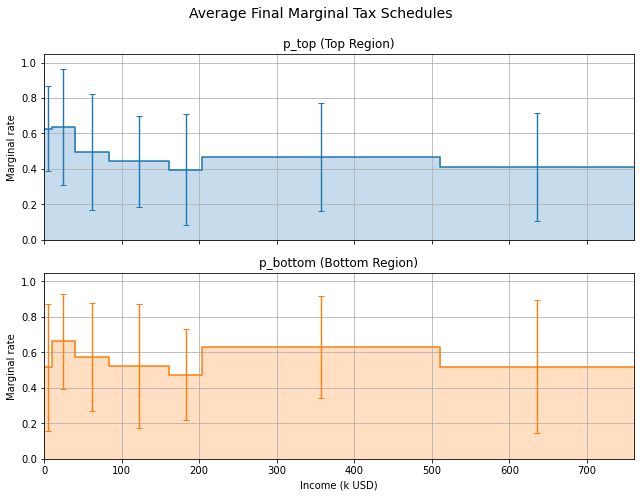

In [160]:
usd_scaling = 1000
brackets = np.array([
    0,
    9700,
    39475,
    84200,
    160725,
    204100,
    510300
]) / usd_scaling


fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules",
    errorbar="std",
    last_bin_width=250,   # makes the >510 bracket visually wider
)

In [72]:
print(env_obj_phase3b.observation_space)
print(env_obj_phase3b.observation_space_pl["p_top"])
print(env_obj_phase3b.observation_space_pl["p_bottom"])

Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (153,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 11, 11), int16), world-map:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (7, 11, 11), float32))
Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (308,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (90,), float32), p0:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p1:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p2:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p3:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p4:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p5:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p6:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), 

In [73]:
print("TRAIN agent obs:", env_obj_phase3b.observation_space)
print("TRAIN p_top obs:", env_obj_phase3b.observation_space_pl["p_top"])
print("TRAIN p_bottom obs:", env_obj_phase3b.observation_space_pl["p_bottom"])

TRAIN agent obs: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (57,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (153,), float32), time:Box(-1e+20, 1e+20, (1,), float64), world-idx_map:Box(-30178, 30178, (2, 11, 11), int16), world-map:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (7, 11, 11), float32))
TRAIN p_top obs: Dict(action_mask:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (308,), float32), flat:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (90,), float32), p0:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p1:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p2:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p3:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p4:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p5:Box(-1.0000000200408773e+20, 1.0000000200408773e+20, (8,), float32), p6:Box(-1.0000000200408773e+

# No Exploration


In [74]:
dense_logs_no_ex = exp.generate_rollout_with_planner_actions(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    num_dense_logs=10,
    explore=False, # concider setting to False down the line
    log_only_tax_days=True
)




=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -2.8846874999999983, 'before_pos': (29, 0), 'after_pos': (29, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.9615624999999998, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.9615624999999998, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.9615624999999998, 'before_pos': (26, 0), 'after_pos': (26, 0), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -16.909687500000004, 'before_pos': (34, 3), 'after_pos': (34, 3), 'dynamic_region_after': 'bottom'}, '5': {'delta': 5.6365625, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_reg

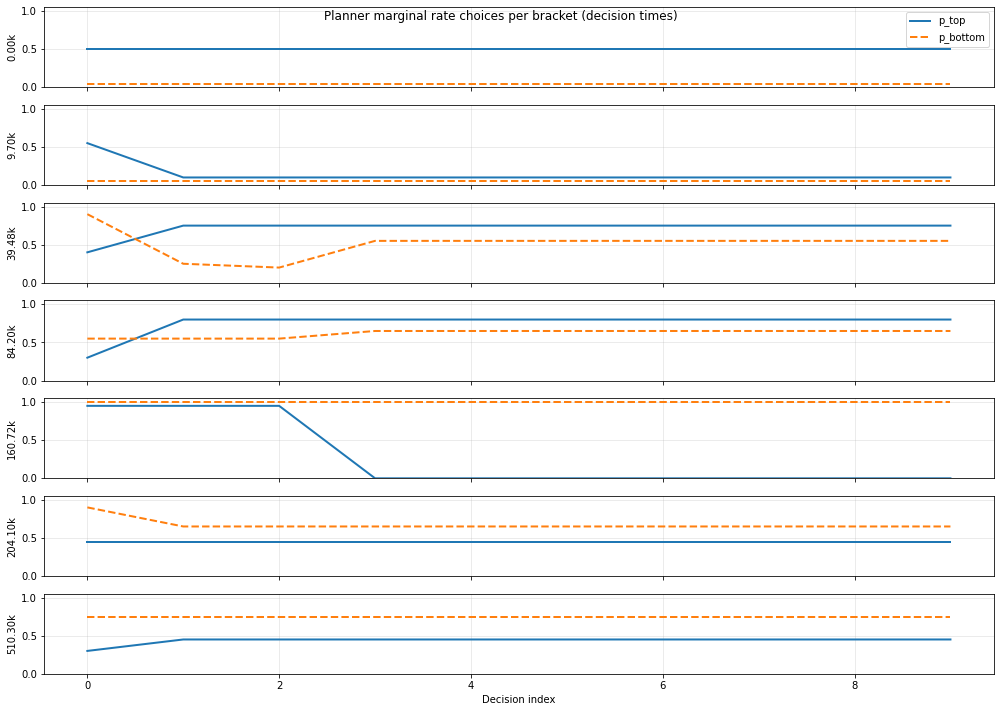

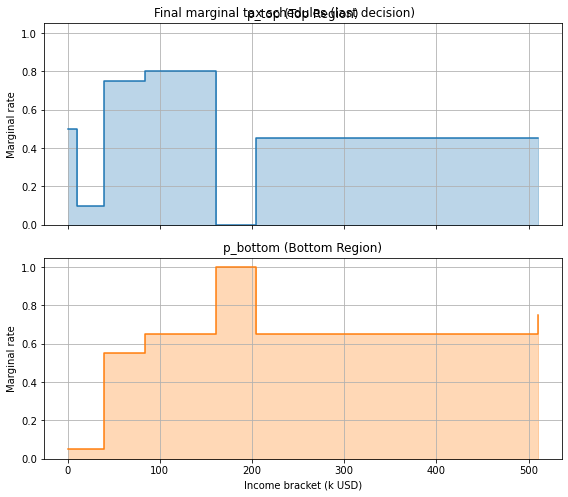

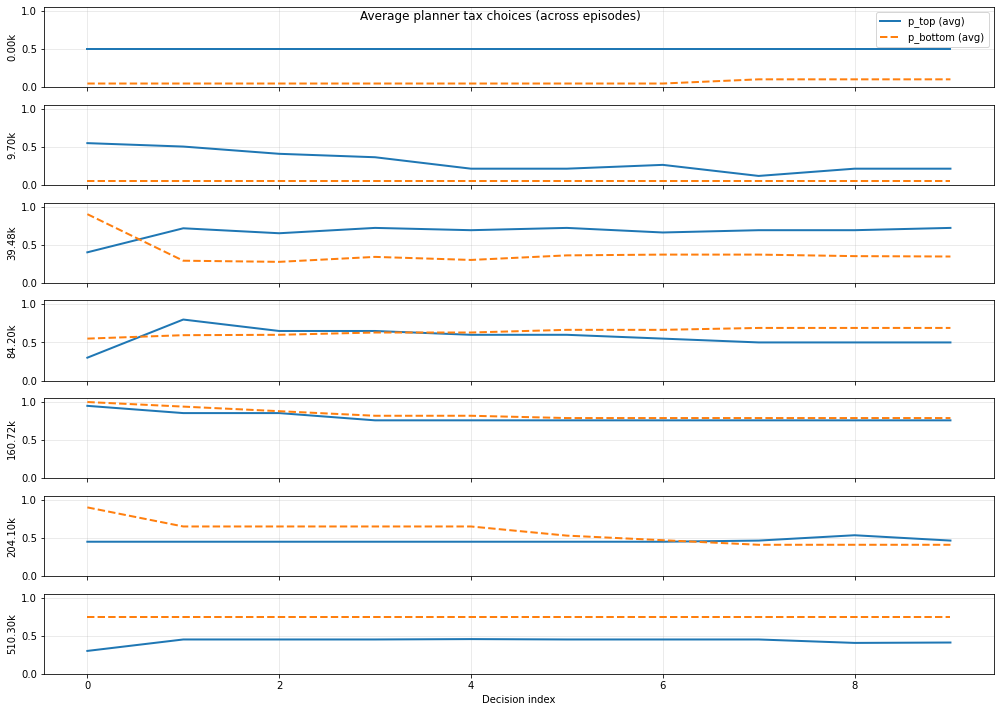

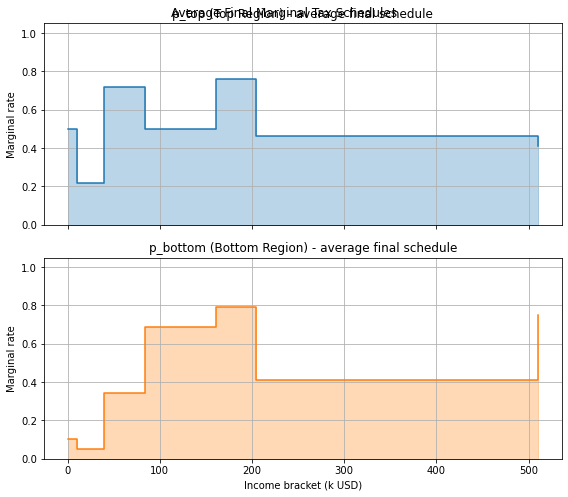

In [75]:
fig_time = plot_planner_tax_lines_percent_from_dense(
    dense_log=dense_logs_no_ex[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    period=100,
    top_first=True,
    title="Planner marginal rate choices per bracket (decision times)"
)

fig_final = plot_final_tax_schedules_two_planners_from_dense(
    dense_log=dense_logs_no_ex[0],
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Final marginal tax schedules (last decision)"
)

# Optional averages across episodes
fig_avg_time = plot_avg_planner_tax_lines(
    dense_logs=dense_logs_no_ex,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average planner tax choices (across episodes)"
)

fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs_no_ex,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules"
)

In [76]:
import numpy as np
import pandas as pd

def agent_region_time_table(log, split_row=25, use_region_field=True, normalize=False):
    """
    Count how many timesteps each agent spends in each region.

    Parameters
    ----------
    log : dict
        Dense log containing log["states"].
    split_row : int
        Row that separates top and bottom region. For a 51x25 world, 25 is typical.
    use_region_field : bool
        If True, use state["region"] when available. Otherwise infer from loc.
    normalize : bool
        If True, also return shares of time instead of only counts.

    Returns
    -------
    df : pandas.DataFrame
        Index = agent id
        Columns include:
            - timesteps_top
            - timesteps_bottom
            - total_timesteps
            - share_top (optional)
            - share_bottom (optional)
            - final_region
    """
    states = log["states"]
    first_state = states[0]

    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    rows = []

    for aid in agent_ids:
        top_count = 0
        bottom_count = 0
        final_region = None

        for state in states:
            s = state[str(aid)]

            if use_region_field and "region" in s:
                region = s["region"]
            else:
                row = int(s["loc"][0])
                region = "top" if row < split_row else "bottom"

            if region == "top":
                top_count += 1
            elif region == "bottom":
                bottom_count += 1

            final_region = region

        total = top_count + bottom_count

        row_out = {
            "agent": aid,
            "timesteps_top": top_count,
            "timesteps_bottom": bottom_count,
            "total_timesteps": total,
            "final_region": final_region,
        }

        if normalize and total > 0:
            row_out["share_top"] = top_count / total
            row_out["share_bottom"] = bottom_count / total

        rows.append(row_out)

    df = pd.DataFrame(rows).set_index("agent")
    return df

In [77]:
df_region_time = agent_region_time_table(dense_logs[0], split_row=25, normalize=True)
df_region_time

,timesteps_top,timesteps_bottom,total_timesteps,final_region,share_top,share_bottom
agent,,,,,,
0,1001,0,1001,top,1.0,0.0
1,1001,0,1001,top,1.0,0.0
2,0,1001,1001,bottom,0.0,1.0
3,1001,0,1001,top,1.0,0.0
4,1001,0,1001,top,1.0,0.0
5,1001,0,1001,top,1.0,0.0
6,1001,0,1001,top,1.0,0.0
7,1001,0,1001,top,1.0,0.0


In [78]:
import pandas as pd

def agent_region_spell_table(log, split_row=25, use_region_field=True):
    """
    For each agent, compute:
      - timesteps spent in top/bottom
      - number of region switches
      - average spell length in top
      - average spell length in bottom
      - overall average spell length

    A spell is a consecutive run of timesteps spent in the same region.
    """
    states = log["states"]
    agent_ids = sorted(int(k) for k in states[0].keys() if str(k).isdigit())

    def get_region(state, aid):
        s = state[str(aid)]
        if use_region_field and "region" in s:
            return s["region"]
        row = int(s["loc"][0])
        return "top" if row < split_row else "bottom"

    rows = []

    for aid in agent_ids:
        regions = [get_region(state, aid) for state in states]

        top_time = sum(r == "top" for r in regions)
        bottom_time = sum(r == "bottom" for r in regions)

        spells_top = []
        spells_bottom = []

        current_region = regions[0]
        current_len = 1
        switches = 0

        for r in regions[1:]:
            if r == current_region:
                current_len += 1
            else:
                if current_region == "top":
                    spells_top.append(current_len)
                else:
                    spells_bottom.append(current_len)
                switches += 1
                current_region = r
                current_len = 1

        # append final spell
        if current_region == "top":
            spells_top.append(current_len)
        else:
            spells_bottom.append(current_len)

        all_spells = spells_top + spells_bottom

        rows.append({
            "agent": aid,
            "timesteps_top": top_time,
            "timesteps_bottom": bottom_time,
            "n_region_switches": switches,
            "n_top_spells": len(spells_top),
            "n_bottom_spells": len(spells_bottom),
            "avg_top_spell": sum(spells_top) / len(spells_top) if spells_top else float("nan"),
            "avg_bottom_spell": sum(spells_bottom) / len(spells_bottom) if spells_bottom else float("nan"),
            "avg_spell_overall": sum(all_spells) / len(all_spells) if all_spells else float("nan"),
            "final_region": regions[-1],
        })

    return pd.DataFrame(rows).set_index("agent")

In [79]:
df_spells = agent_region_spell_table(dense_logs[0], split_row=25, use_region_field=True)
df_spells

,timesteps_top,timesteps_bottom,n_region_switches,n_top_spells,n_bottom_spells,avg_top_spell,avg_bottom_spell,avg_spell_overall,final_region
agent,,,,,,,,,
0,1001,0,0,1,0,1001.0,NaN,1001.0,top
1,1001,0,0,1,0,1001.0,NaN,1001.0,top
2,0,1001,0,0,1,NaN,1001.0,1001.0,bottom
3,1001,0,0,1,0,1001.0,NaN,1001.0,top
4,1001,0,0,1,0,1001.0,NaN,1001.0,top
5,1001,0,0,1,0,1001.0,NaN,1001.0,top
6,1001,0,0,1,0,1001.0,NaN,1001.0,top
7,1001,0,0,1,0,1001.0,NaN,1001.0,top


In [80]:
# import ray
# from ray.rllib.agents.ppo import PPOTrainer

# FRAMEWORK = "tf"
# CKPT_PATH = r"C:\Users\adria\ray_results\PPO_RLlibEnvWrapper_2026-03-19_17-43-177lj60z8y\checkpoint_250\checkpoint-250"

# ray.shutdown()
# ray.init(ignore_reinit_error=True, log_to_driver=False)

# env_obj_phase2 = RLlibEnvWrapper(
#     {"env_config_dict": env_config_dict_phase2},
#     verbose=False
# )

# # Patch standalone eval env
# patch_regional_tax_masks(env_obj_phase2, min_band=MIN_BAND)

# policies_eval = {
#     "a": (
#         None,
#         env_obj_phase2.observation_space,
#         env_obj_phase2.action_space,
#         {}
#     ),
#     "p_top": (
#         None,
#         env_obj_phase2.observation_space_pl["p_top"],
#         env_obj_phase2.action_space_pl["p_top"],
#         {}
#     ),
#     "p_bottom": (
#         None,
#         env_obj_phase2.observation_space_pl["p_bottom"],
#         env_obj_phase2.action_space_pl["p_bottom"],
#         {}
#     ),
# }

# def policy_mapping_fun_eval(agent_id):
#     aid = str(agent_id)
#     if aid.isdigit():
#         return "a"
#     if aid == "p_top":
#         return "p_top"
#     if aid == "p_bottom":
#         return "p_bottom"
#     return "a"

# trainer_config_phase2_eval = {
#     "env": RLlibEnvWrapper,
#     "env_config": {
#         "env_config_dict": env_config_dict_phase2,
#         "num_envs_per_worker": 1,
#     },
#     "multiagent": {
#         "policies": policies_eval,
#         "policies_to_train": [],
#         "policy_mapping_fn": policy_mapping_fun_eval,
#     },
#     "num_workers": 0,
#     "num_envs_per_worker": 1,
#     "framework": FRAMEWORK,
#     "num_gpus": 0,
#     "train_batch_size": 1000,
#     "sgd_minibatch_size": 1000,
#     "num_sgd_iter": 1,
# }

# trainer_phase2_eval = PPOTrainer(config=trainer_config_phase2_eval)
# trainer_phase2_eval.restore(CKPT_PATH)

# # IMPORTANT: patch restored trainer env(s) too
# patch_trainer_envs(trainer_phase2_eval, min_band=MIN_BAND)

# dense_logs = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2_eval,
#     env_obj=env_obj_phase2,
#     num_dense_logs=3,
#     explore=False,
#     log_only_tax_days=True,  
# )



# # arr_top = dense_logs[0]["planner_actions"]["p_top"]
# # arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]

# # print("FULL p_top (#rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
# # print("FULL p_bottom (#rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])

# # print_active_planner_debug(dense_logs[0], top_first=True, max_rows=10)
# # print_active_planner_rates(dense_logs[0], env_obj_phase2, top_first=True, max_rows=10)


# dense_logs_explore = generate_rollout_with_planner_actions(
#     trainer=trainer_phase2_eval,
#     env_obj=env_obj_phase2,
#     num_dense_logs=10,
#     explore=True,
#     log_only_tax_days=True
# )

# print_active_planner_debug(dense_logs_explore[0], top_first=True, max_rows=10)
# print_active_planner_rates(dense_logs_explore[0], env_obj_phase2, top_first=True, max_rows=10)

# usd_scaling = 1000

# brackets = np.array([
#         0,
#         9700,
#         39475,
#         84200,
#         160725,
#         204100,
#         510300
#     ]) / usd_scaling

# # Pick one episode (e.g., 0) and visualize
# fig_time = plot_planner_tax_lines_percent_from_dense(
#     dense_log=dense_logs_explore[0],
#     env_obj=env_obj_phase2,
#     brackets=brackets,
#     period=100,
#     top_first=True,
#     title="Planner marginal rate choices per bracket (decision times)"
# )

# fig_final = plot_final_tax_schedules_two_planners_from_dense(
#     dense_log=dense_logs_explore[0],
#     env_obj=env_obj_phase2,
#     brackets=brackets,
#     top_first=True,
#     title="Final marginal tax schedules (last decision)"
# )

In [81]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_avg_planner_tax_lines(
#     dense_logs,
#     env_obj,
#     brackets,
#     top_first=True,
#     figsize=(14, 10),
#     title="Average planner tax choices (across episodes)"
# ):
#     def _split(A):
#         if A.size == 0:
#             return A, A
#         half = A.shape[1] // 2
#         if top_first:
#             return A[:, :half], A[:, half:]
#         else:
#             return A[:, half:], A[:, :half]

#     # collect all episodes
#     top_list = []
#     bot_list = []

#     for ep in dense_logs:
#         A_top = dense_logs[ep]["planner_actions"]["p_top"]
#         A_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

#         if A_top.size == 0 or A_bot.size == 0:
#             continue

#         top7_top, _ = _split(A_top)
#         _, bottom7_bot = _split(A_bot)

#         top_list.append(top7_top)
#         bot_list.append(bottom7_bot)

#     # align lengths (in case episodes differ)
#     min_T = min(a.shape[0] for a in top_list)

#     top_stack = np.stack([a[:min_T] for a in top_list], axis=0)  # (E, T, 7)
#     bot_stack = np.stack([a[:min_T] for a in bot_list], axis=0)

#     # map indices -> rates
#     def _get_disc_rates(env_obj):
#         for comp in env_obj.env.components:
#             if "BracketTax" in comp.name and hasattr(comp, "disc_rates"):
#                 return np.array(comp.disc_rates, dtype=float)
#         return np.arange(0.0, 1.0 + 1e-9, 0.05)

#     disc_rates = _get_disc_rates(env_obj)

#     top_rates = disc_rates[np.clip(top_stack, 0, len(disc_rates)-1)]
#     bot_rates = disc_rates[np.clip(bot_stack, 0, len(disc_rates)-1)]

#     # average over episodes
#     top_mean = np.mean(top_rates, axis=0)  # (T, 7)
#     bot_mean = np.mean(bot_rates, axis=0)

#     X = np.arange(top_mean.shape[0])

#     # plot
#     fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
#     fig.suptitle(title)

#     for b in range(7):
#         ax = axes[b]
#         ax.plot(X, top_mean[:, b], label="p_top (avg)", lw=2)
#         ax.plot(X, bot_mean[:, b], label="p_bottom (avg)", lw=2, linestyle="--")

#         ax.set_ylabel(f"{brackets[b]:.2f}k")
#         ax.set_ylim(0, 1.05*np.max(disc_rates))
#         ax.grid(True, alpha=0.3)

#         if b == 0:
#             ax.legend()

#     axes[-1].set_xlabel("Decision index")
#     plt.tight_layout()
#     plt.show()

#     return fig

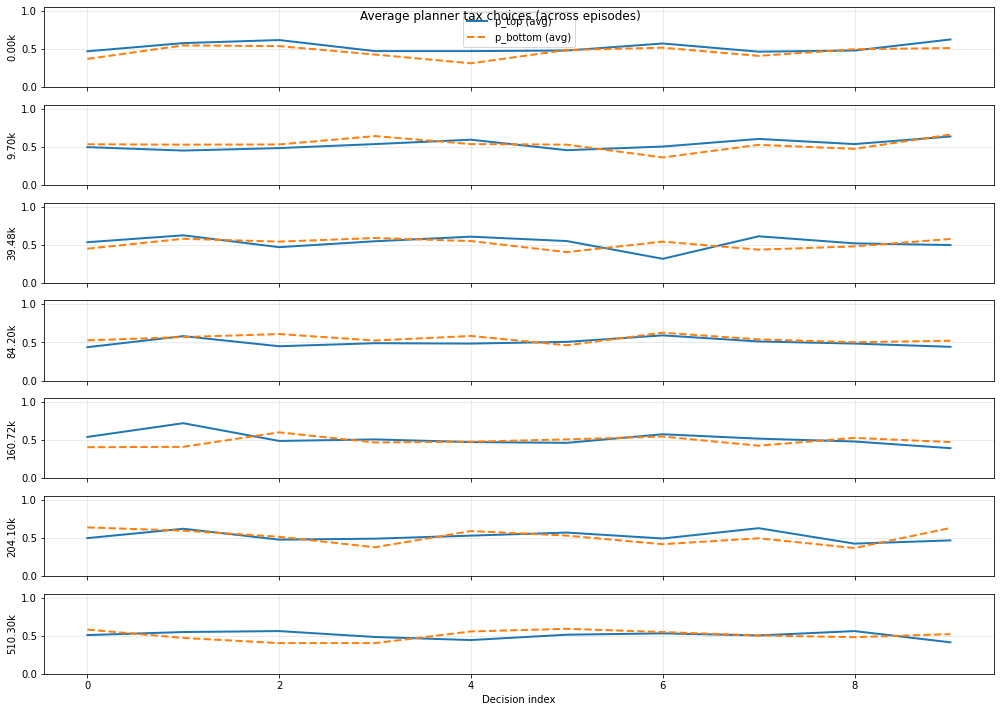

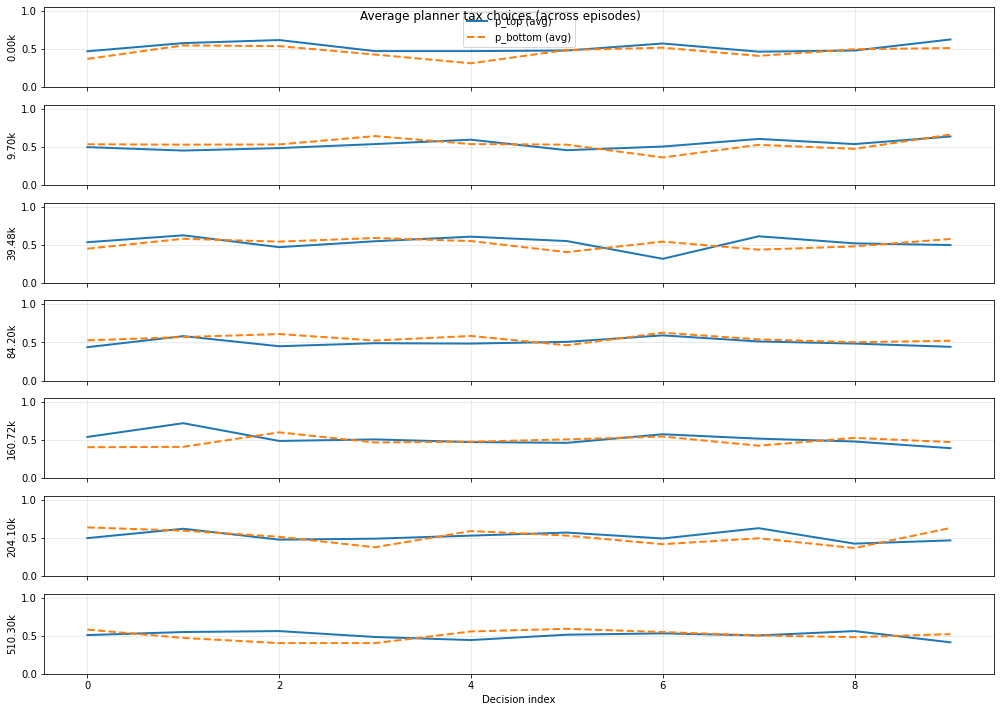

In [82]:
plot_avg_planner_tax_lines(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True
)

In [83]:
# def plot_avg_final_tax_schedules_two_planners_from_dense_logs(
#     dense_logs,
#     env_obj,
#     brackets,
#     top_first=True,
#     title="Average Final Marginal Tax Schedules (p_top vs p_bottom)",
#     figsize=(8, 7),
# ):
#     """
#     Average final schedules across all dense_logs.
#     Uses the last logged planner-action row from each episode.
#     """
#     def _split_last_row(arr, top_first=True):
#         if arr.size == 0:
#             return None, None
#         last = arr[-1].reshape(1, -1)
#         half = last.shape[1] // 2
#         if top_first:
#             return last[:, :half][0], last[:, half:][0]
#         else:
#             return last[:, half:][0], last[:, :half][0]

#     idx_top_list = []
#     idx_bottom_list = []

#     for ep in dense_logs:
#         actions_top = dense_logs[ep]["planner_actions"]["p_top"]
#         actions_bot = dense_logs[ep]["planner_actions"]["p_bottom"]

#         if actions_top.size == 0 or actions_bot.size == 0:
#             continue

#         top7_last_top, _ = _split_last_row(actions_top, top_first=top_first)
#         _, bottom7_last_bottom = _split_last_row(actions_bot, top_first=top_first)

#         idx_top_list.append(top7_last_top)
#         idx_bottom_list.append(bottom7_last_bottom)

#     if len(idx_top_list) == 0 or len(idx_bottom_list) == 0:
#         raise ValueError("No planner actions logged in dense_logs.")

#     idx_top_arr = np.stack(idx_top_list, axis=0)         # (E, 7)
#     idx_bottom_arr = np.stack(idx_bottom_list, axis=0)   # (E, 7)

#     disc_rates = _get_disc_rates(env_obj)

#     top_rates_all = disc_rates[np.clip(idx_top_arr, 0, len(disc_rates)-1)]
#     bottom_rates_all = disc_rates[np.clip(idx_bottom_arr, 0, len(disc_rates)-1)]

#     top_rates_mean = np.mean(top_rates_all, axis=0)
#     bottom_rates_mean = np.mean(bottom_rates_all, axis=0)

#     fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
#     fig.suptitle(title)

#     axes[0].step(brackets, top_rates_mean, where="post", color="#1f77b4")
#     axes[0].fill_between(brackets, top_rates_mean, step="post", alpha=0.3, color="#1f77b4")
#     axes[0].set_ylabel("Marginal rate")
#     axes[0].set_title("p_top (Top Region) - average final schedule")
#     axes[0].set_ylim(0, 1.05*np.max(disc_rates))
#     axes[0].grid(True)

#     axes[1].step(brackets, bottom_rates_mean, where="post", color="#ff7f0e")
#     axes[1].fill_between(brackets, bottom_rates_mean, step="post", alpha=0.3, color="#ff7f0e")
#     axes[1].set_ylabel("Marginal rate")
#     axes[1].set_title("p_bottom (Bottom Region) - average final schedule")
#     axes[1].set_xlabel("Income bracket (k USD)")
#     axes[1].set_ylim(0, 1.05*np.max(disc_rates))
#     axes[1].grid(True)

#     plt.tight_layout()
#     plt.show()
#     return fig

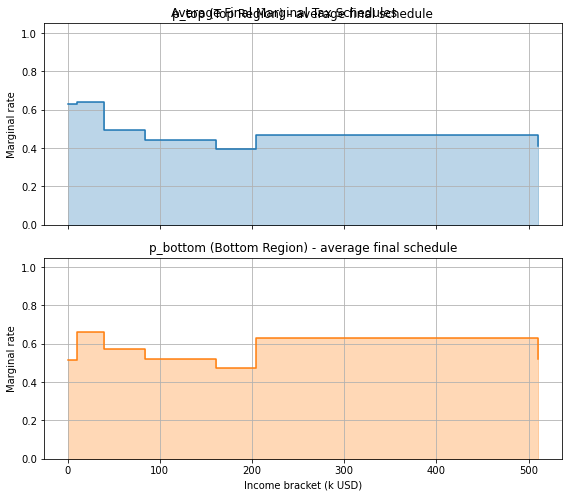

In [84]:
fig_avg_final = plot_avg_final_tax_schedules_two_planners_from_dense_logs(
    dense_logs=dense_logs,
    env_obj=env_obj_phase3b,
    brackets=brackets,
    top_first=True,
    title="Average Final Marginal Tax Schedules"
)

In [85]:
def _flatten_obs_dict(obs):
    if isinstance(obs, dict):
        parts = []
        for k in sorted(obs.keys()):
            v = obs[k]
            if isinstance(v, dict):
                parts.append(_flatten_obs_dict(v))
            else:
                parts.append(np.asarray(v, dtype=np.float32).reshape(-1))
        if parts:
            return np.concatenate(parts, axis=0)
        return np.zeros(0, dtype=np.float32)
    return np.asarray(obs, dtype=np.float32).reshape(-1)

def debug_planner_obs_drift(trainer, env_obj, num_steps=1000):
    obs = env_obj.reset(force_dense_logging=False)

    p_top_obs = []
    p_bottom_obs = []

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    def _compute_action(policy_id, ob, state):
        out = trainer.compute_action(
            observation=ob,
            state=state,
            policy_id=policy_id,
            full_fetch=False,
            explore=False,
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    for _t in range(num_steps):
        if is_tax_day(env_obj):
            p_top_obs.append(_flatten_obs_dict(obs["p_top"]))
            p_bottom_obs.append(_flatten_obs_dict(obs["p_bottom"]))

        actions = {}
        for i in range(env_obj.env.n_agents):
            aid = str(i)
            a, ns = _compute_action("a", obs[aid], agent_states[aid])
            actions[aid] = a
            agent_states[aid] = ns

        a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
        a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
        actions["p_top"] = a_top
        actions["p_bottom"] = a_bottom

        obs, rew, done, info = env_obj.step(actions)
        if done.get("__all__", False):
            break

    if len(p_top_obs) >= 2:
        top_diffs = [float(np.mean(np.abs(p_top_obs[i] - p_top_obs[i-1]))) for i in range(1, len(p_top_obs))]
        bot_diffs = [float(np.mean(np.abs(p_bottom_obs[i] - p_bottom_obs[i-1]))) for i in range(1, len(p_bottom_obs))]
        print("mean |Δobs| p_top between decision times:", top_diffs)
        print("mean |Δobs| p_bottom between decision times:", bot_diffs)

In [86]:
debug_planner_obs_drift(trainer_phase3b, env_obj_phase3b, num_steps=1000)

mean |Δobs| p_top between decision times: [0.01870160736143589, 0.009356028400361538, 0.00468848692253232, 0.00045869333553127944, 0.0005992199294269085, 0.0002273739082738757, 0.00023088017769623548, 0.00023261699243448675, 0.00023805169621482491]
mean |Δobs| p_bottom between decision times: [0.014641843736171722, 0.0015057165874168277, 0.0002985177852679044, 0.00023738872550893575, 0.00023553412756882608, 4.4510397856356576e-05, 4.8219571908703074e-05, 5.0074191676685587e-05, 5.5637974583078176e-05]


## end new code

# debug

In [87]:
import numpy as np

def dump_tax_masks(env_obj):
    # Jump to next tax day quickly by stepping with random actions
    obs = env_obj.reset(force_dense_logging=False)
    dummy = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy[aid] = env_obj.action_space.sample()
        elif aid in ("p_top","p_bottom"):
            dummy[aid] = env_obj.action_space_pl[aid].sample()

    # use component.period if present
    try:
        period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
    except StopIteration:
        period = 100

    t = 0
    while getattr(next(c for c in env_obj.env.components if "BracketTax" in c.name), "tax_cycle_pos", None) != 1:
        obs, rew, done, info = env_obj.step(dummy)
        t += 1
        if done.get("__all__", False):
            obs = env_obj.reset()
            t = 0

    masks_raw = env_obj.env._generate_masks(flatten_masks=False)

    out = {}
    for pid in ("p_top", "p_bottom"):
        m = masks_raw.get(pid, {})
        # Only keep this component's regional 7; order by key to make it deterministic
        keys = sorted(m.keys())
        legal = {k: list(np.where(np.array(m[k]) > 0)[0]) for k in keys}
        out[pid] = legal
    return out

mask_dump = dump_tax_masks(env_obj_phase3b)
print("MASK DUMP (legal indices per subspace on tax day):")
for pid, d in mask_dump.items():
    print(f"\n{pid}:")
    for k, idxs in d.items():
        print(f"  {k}: {idxs}")

MASK DUMP (legal indices per subspace on tax day):

p_top:
  RegionalPeriodicBracketTax.TaxIndexBracket_000: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_009: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_039: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_084: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_160: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_204: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_510: [0, 1, 2, 3]

p_bottom:
  RegionalPeriodicBracketTax.TaxIndexBracket_000: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_009: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_039: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_084: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_160: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_204: [0, 1, 2, 3]
  RegionalPeriodicBracketTax.TaxIndexBracket_510: [0, 1, 2, 3]


In [88]:
print("p_top nvec:", env_obj_phase3b.action_space_pl["p_top"].nvec)
print("p_bottom nvec:", env_obj_phase3b.action_space_pl["p_bottom"].nvec)
print("multi_action_mode_planner:", env_obj_phase3b.env.multi_action_mode_planner)

p_top nvec: [22 22 22 22 22 22 22 22 22 22 22 22 22 22]
p_bottom nvec: [22 22 22 22 22 22 22 22 22 22 22 22 22 22]
multi_action_mode_planner: True


In [89]:
def debug_tax_days(env_obj, steps=120):
    obs = env_obj.reset(force_dense_logging=False)
    dummy = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy[aid] = env_obj.action_space.sample()
        elif aid in ("p_top","p_bottom"):
            dummy[aid] = env_obj.action_space_pl[aid].sample()

    days = []
    for i in range(steps):
        # collect current cycle pos of the first bracket-tax component
        pos = next(c.tax_cycle_pos for c in env_obj.env.components if "BracketTax" in c.name)
        days.append(int(pos == 1))
        obs, rew, done, info = env_obj.step(dummy)
        if done.get("__all__", False):
            break
    print("Found tax_day flags:", sum(days), "over", len(days), "steps. Positions:", days[:20])

debug_tax_days(env_obj_phase3b, steps=1000*2)

Found tax_day flags: 10 over 1000 steps. Positions: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [90]:
import inspect

def show_mask_impl(env_obj):
    for comp in env_obj.env.components:
        if "BracketTax" in comp.name:
            fn = comp.generate_masks
            try:
                src = inspect.getsource(fn)
                origin = inspect.getsourcefile(fn)
                print(f"\nComponent: {comp.name}\nFrom: {origin}\n--- code preview ---\n{src[:400]}\n...")
            except Exception as e:
                print(f"\nComponent: {comp.name} (cannot read source):", e)

# Example:
show_mask_impl(env_obj_phase3b)



Component: RegionalPeriodicBracketTax
From: c:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\simulation.py
--- code preview ---
            def _patched_generate_masks(self: Any, completions: int = 0) -> Dict[str, Dict[str, np.ndarray]]:
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys =
...

Component: RegionalPeriodicBracketTax
From: c:\Users\adria\coding\katja\DRL-in-international-economy-ai-economist-\tutorials\simulation.py
--- code preview ---
            def _patched_generate_masks(self: Any, completions: int = 0) -> Dict[str, Dict[str, np.ndarray]]:
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    

In [91]:
import numpy as np
import types

def patch_regional_tax_masks(env_obj, min_band=4):
    """
    Monkey-patch RegionalPeriodicBracketTax.generate_masks on *instances* so:
    - Only this component's 7 regional brackets are active for its bound planner.
    - On decision day (tax_cycle_pos==1), allow at least `min_band` legal rate indices
      (or more if annealing allows more).
    - On non-decision days, all-zero mask (RLlib handles no-op).
    """
    for comp in env_obj.env.components:
        if "BracketTax" not in comp.name:
            continue

        def make_patched(c):
            def _patched_generate_masks(self, completions=0):
                planner = self._get_bound_planner(self.world)
                if planner is None or str(planner.idx) != str(self._planner_id):
                    return {}

                all_keys = [f"TaxIndexBracket_{int(r):03d}" for r in self.bracket_cutoffs]
                my_keys  = [f"TaxIndexBracket_{int(r):03d}" for r in self.regional_brackets]

                disc = np.array(self.disc_rates, dtype=float)
                n = len(disc)

                # ---- annealing cap -> allowed_idx ----
                if getattr(self, "tax_annealing_schedule", None) is not None:
                    cap = float(getattr(self, "_annealed_rate_max", disc[-1]))
                    allowed_idx = np.where(disc <= cap)[0]
                else:
                    allowed_idx = np.arange(n)

                # ---- min band floor ----
                if allowed_idx.size < min_band:
                    allowed_idx = np.arange(min(min_band, n))

                # ---- decision vs non-decision day ----
                if self.tax_cycle_pos == 1:
                    rate_mask_active = np.zeros(n, dtype=np.float32)
                    rate_mask_active[allowed_idx] = 1.0
                else:
                    rate_mask_active = np.zeros(n, dtype=np.float32)

                zero_mask = np.zeros_like(rate_mask_active, dtype=np.float32)
                masks = {}
                for k in all_keys:
                    masks[k] = rate_mask_active if (k in my_keys) else zero_mask
                return {str(planner.idx): masks}
            return types.MethodType(_patched_generate_masks, c)

        comp.generate_masks = make_patched(comp)

# Example:
patch_regional_tax_masks(env_obj_phase3b, min_band=4)


In [92]:
def print_legal_rate_counts_at_next_tax_day(env_obj):
    # Advance env to the next tax day (tax_cycle_pos == 1)
    # Easiest proxy: reset then step until t % period == 0
    try:
        period = next(c.period for c in env_obj.env.components if "BracketTax" in c.name)
    except StopIteration:
        period = 100

    obs = env_obj.reset(force_dense_logging=False)

    # Step zero actions to move time forward quickly
    dummy_actions = {}
    for aid in obs.keys():
        if str(aid).isdigit():
            dummy_actions[aid] = env_obj.action_space.sample()
        elif aid in ("p_top","p_bottom"):
            dummy_actions[aid] = env_obj.action_space_pl[aid].sample()

    # step until t % period == 0 (decision timestep)
    t = 0
    while (t % period) != 0:
        obs, rew, done, info = env_obj.step(dummy_actions)
        t += 1
        if done.get("__all__", False):
            obs = env_obj.reset()

    # Now ask components what masks they create (unflattened) on tax day
    masks_raw = env_obj.env._generate_masks(flatten_masks=False)

    for pid in ("p_top","p_bottom"):
        if pid not in masks_raw:
            print(f"{pid}: no mask dict found.")
            continue
        print(f"== {pid} legal counts per subspace (14 expected) ==")
        counts = []
        for k, v in masks_raw[pid].items():  # v is a vector of choices in that subspace
            counts.append(int(np.sum(np.array(v) > 0)))
        print(counts)


In [93]:
# After patching
print_legal_rate_counts_at_next_tax_day(env_obj_phase3b)
# Expect 7 numbers per planner, each >= 4 at the start

== p_top legal counts per subspace (14 expected) ==
[4, 4, 4, 4, 4, 4, 4]
== p_bottom legal counts per subspace (14 expected) ==
[4, 4, 4, 4, 4, 4, 4]


In [94]:
arr_top = dense_logs[0]["planner_actions"]["p_top"]
arr_bot = dense_logs[0]["planner_actions"]["p_bottom"]
if arr_top.size:
    print("p_top (#rows, #unique):", arr_top.shape[0], np.unique(arr_top, axis=0).shape[0])
    print("p_top sample rows:\n", arr_top[:5])
if arr_bot.size:
    print("p_bottom (#rows, #unique):", arr_bot.shape[0], np.unique(arr_bot, axis=0).shape[0])
    print("p_bottom sample rows:\n", arr_bot[:5])

p_top (#rows, #unique): 10 10
p_top sample rows:
 [[ 6 15 10  6  1  7 12 17  2  1 15 11 16  8]
 [ 8 17 16 20 21 18  9 20 14  6 15  5  4 13]
 [ 8  4 10 16 10  3  7  8  0  6  3  2  6 16]
 [ 2 20  7  5  6  9  1  4  9 18  3 15 16 16]
 [ 0 21 20  0  0 20  8  1  7 12  2 11 20 12]]
p_bottom (#rows, #unique): 10 10
p_bottom sample rows:
 [[ 4 11  5  1  6 17  3  0  2  7 17 12 11 17]
 [14 19 13 14  0 20 21 19  2 11  2 14  9  1]
 [ 8  9 20 21  1  6  4 21 17 20 14 11  7  0]
 [21  7 11 13  4 17 13 13 15  4  8  0 12 17]
 [11 20 21 14 15  7 11 12  9  4 11 18 13 18]]


If you want stochastic rollout instead of greedy rollout: explore=False ---> explore=False

tensorboard --logdir ./phase1_tb
tensorboard --logdir ./phase2_tb

http://localhost:6006

What the official scripts do (and how your notebook compares)
1) Runner & Logging

Official: python training_script.py --run-dir phase1 / phase2

Uses a YAML config, TensorFlow/Keras models, Ray Tune style logging to ~/ray_results, plus two folders per run:

phaseX/ckpts with policy checkpoints
phaseX/dense_logs (compressed .lz4), written by the script




Your notebook: Directly constructs PPOTrainer (no Tune), with a logger_creator so TensorBoard logs go to ./phase1_tb and ./phase2_tb instead of ~/ray_results.
✅ This is fine. It’s equivalent logging, just in a location you control.
📌 If you want to log under ~/ray_results like the docs say, remove the logger_creator and use Tune (tune.run) or pass a logger_creator pointing there.

2) Framework

Official: TensorFlow/Keras models (their examples say “restore_tf_weights_agents”).
Your notebook: We switched to framework: "tf" to avoid the Torch import error.
✅ This matches the official setup better and is stable.

3) Phase 1 vs Phase 2 who trains

Official:

Phase 1: Agents train, planner disabled.
Phase 2: Agents continue training and planner trains (both update), and agents are initialized from a TF checkpoint (restore_tf_weights_agents).


Your notebook (current config I provided):

Phase 1: Agents train (✅).
Phase 2: Planners train only (agents frozen) — that’s an intentional simplification to stabilize the planner faster.
The restore we do is full trainer checkpoint restore (not a TF‑weights‑only restore). This is typically easier in notebooks.



If you want to match the official behavior more closely in Phase 2 (agents continue learning):
Python

- Phase-2: train both agents and planners
- trainer_config_phase2["multiagent"]["policies_to_train"] = ["a", "p_top", "p_bottom"]
- You can also set the agent LR lower during phase-2 (optional):
- policies["a"][3]["lr"] = 1e-5  # e.g., smaller than in phase-1Show more lines
  
4) Annealing

Official: They pass tax_annealing_schedule via YAML.
Your notebook: You now pass "tax_annealing_schedule": [-100, 0.001] in Phase‑2 component configs (✅).
You also added enforcement in generate_masks() to actually bind the annealed max (✅).
When to verify: Run the annealing verification after creating/restoring Phase‑2 trainer and optionally every N iterations.

5) Dense logs

Official: The training script writes dense logs (phaseX/dense_logs/…lz4), which they visualize later.
Your notebook: TensorBoard logs are saved; dense logs are in memory via env.env.dense_log during rollout. If you want files the same way they do:

Either switch to the training script style, or
Periodically (e.g., every 200 iterations) pull the logs from the local worker and save them via the Foundation utils (if you want .lz4):
Python
- from ai_economist.foundation.utils import save_lz4
- env = trainer_phase2.workers.local_worker().env  # RLlib wrapper
- dense_log = env.env.dense_log                    # underlying Foundation env# Pick your path and save:
- save_lz4(dense_log, os.path.join(PHASE2_DIR, f"dense_log_iter_{i}.lz4"))Show more lines

Make sure dense_log_frequency is set (it is, to 1 in your configs).




Does your notebook still work optimally given their guidance?
Yes—for your custom two‑planner environment and for long notebook runs. It is intentionally simpler:

Direct PPOTrainer usage (no CLI) for ease of debugging.
TensorBoard logs go to your chosen folders (./phase1_tb, ./phase2_tb), not ~/ray_results.
Phase‑2 trains only planners by default (more stable early on), but you can easily enable agent training too (see snippet above) to match the tutorial’s description.
Annealing is passed and enforced (good).
Windows‑safe (num_workers = 0) and avoids Torch setup by using TF.

If your goal is maximum parity with the official script:

Use TensorFlow (already doing).
Enable agent training in Phase‑2 (policies_to_train = ["a", "p_top", "p_bottom"]).
Save dense logs to files periodically with save_lz4.
Consider using the training_script.py pattern with YAML if you want the exact folder layout and CLI workflow they document. For notebooks, your approach is excellent.


Minimal changes to match their “Phase‑2: agents continue learning” policy
Add this just before constructing trainer_phase2:
- Train both agents and planners in Phase-2 (closer to official doc)
- trainer_config_phase2["multiagent"]["policies_to_train"] = ["a", "p_top", "p_bottom"]
- Optional: Reduce agent LR during Phase-2 so planners dominate the change
- policies["a"][3]["lr"] = 1e-5   # from 3e-4 in phase-1 to 1e-5 in phase-2

In [98]:
import numpy as np

def force_single_agent_move(env_obj, agent_id, target_region, max_tries=500):
    """
    Force a single agent to relocate once to a valid empty tile in the target region.
    Does not use the travel action or require CrossWaterTravel target attributes.
    """
    world = env_obj.env.world
    agent = world.agents[int(agent_id)]

    H, W = world.world_size
    split = H // 2

    if target_region == "top":
        r_min, r_max = 0, split
    elif target_region == "bottom":
        r_min, r_max = split + 1, H
    else:
        raise ValueError("target_region must be 'top' or 'bottom'")

    old_r, old_c = agent.loc

    # If already in target region, do nothing
    if (target_region == "top" and old_r < split) or (target_region == "bottom" and old_r > split):
        return {
            "agent": int(agent.idx),
            "from": (int(old_r), int(old_c)),
            "to": (int(old_r), int(old_c)),
            "new_region": target_region,
            "moved": False,
            "reason": "already_in_target_region",
        }

    # Try random valid locations in the target region
    for _ in range(max_tries):
        r = np.random.randint(r_min, r_max)
        c = np.random.randint(0, W)

        if world.maps.unoccupied[r, c] and world.can_agent_occupy(r, c, agent):
            new_r, new_c = world.set_agent_loc(agent, r, c)

            # update region state if present
            if "region" in agent.state:
                agent.state["region"] = "top" if int(new_r) < split else "bottom"

            # remove outstanding market listings/orders if supported
            try:
                cda = env_obj.env.get_component("ContinuousDoubleAuction")
                if cda is not None and hasattr(cda, "cancel_all_orders_for_agent"):
                    cda.cancel_all_orders_for_agent(agent.idx)
            except Exception:
                pass

            return {
                "agent": int(agent.idx),
                "from": (int(old_r), int(old_c)),
                "to": (int(new_r), int(new_c)),
                "new_region": agent.state.get("region", target_region),
                "moved": True,
            }

    raise RuntimeError(f"Could not find valid relocation target for agent {agent_id} to region {target_region}")

# def force_single_agent_move(env_obj, agent_id, target_region, max_tries=500):
#     """
#     Force a single agent to move across regions using the travel component logic.
#     Works with your CrossWaterTravel implementation.
#     """

#     world = env_obj.env.world

#     # Get travel component
#     travel_comp = None
#     for comp in world._components:
#         if comp.name == "CrossWaterTravel":
#             travel_comp = comp
#             break

#     if travel_comp is None:
#         raise ValueError("CrossWaterTravel component not found")

#     agent = world.agents[agent_id]

#     # Determine split (waterline)
#     split = world.world_size[0] // 2

#     # Determine target row based on region
#     if target_region == "top":
#         desired_r = split - 2
#     elif target_region == "bottom":
#         desired_r = split + 2
#     else:
#         raise ValueError("target_region must be 'top' or 'bottom'")

#     # Keep column roughly same
#     desired_c = int(agent.loc[1])

#     # Use your own helper (this exists in your code)
#     target = travel_comp._find_valid_target(agent, desired_r, desired_c)

#     if target is None:
#         raise RuntimeError("Could not find valid travel target")

#     # Move agent
#     new_r, new_c = world.set_agent_loc(agent, target[0], target[1])

#     # Update region state (IMPORTANT)
#     agent.state["region"] = travel_comp._region_from_row(new_r)

#     print(f"[FORCED MOVE] Agent {agent_id}: {agent.loc} -> {(new_r, new_c)}")

In [99]:
def generate_rollout_with_forced_move(
    trainer,
    env_obj,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
):
    def _compute_action(pid, obs, state):
        out = trainer.compute_action(
            observation=obs,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore,
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    obs = env_obj.reset(force_dense_logging=True)

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    forced_move_log = None
    agent_utility_history = []

    for t in range(env_obj.env.episode_length):
        actions = {}

        for i in range(env_obj.env.n_agents):
            aid = str(i)
            a, ns = _compute_action("a", obs[aid], agent_states[aid])
            actions[aid] = a
            agent_states[aid] = ns

        a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
        a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)
        actions["p_top"] = a_top
        actions["p_bottom"] = a_bottom

        obs, rew, done, info = env_obj.step(actions)

        if t == forced_timestep:
            forced_move_log = force_single_agent_move(
                env_obj=env_obj,
                agent_id=forced_agent_id,
                target_region=forced_target_region,
            )
            forced_move_log["timestep"] = t

        util_t = {}
        for agent in env_obj.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_obj.env.curr_optimization_metric.get(agent.idx, np.nan))
        agent_utility_history.append(util_t)

        if done.get("__all__", False):
            break

    dense_log = dict(env_obj.env.dense_log)

    if "states" in dense_log:
        n_states = len(dense_log["states"])
        n_utils = len(agent_utility_history)
        n_match = min(n_states, n_utils)

        for tt in range(n_match):
            for aid, util in agent_utility_history[tt].items():
                if aid in dense_log["states"][tt]:
                    dense_log["states"][tt][aid]["utility"] = util

    dense_log["forced_move"] = forced_move_log
    return dense_log

In [100]:
forced_log = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'0': {'delta': -1.2039999999999935, 'before_pos': (28, 13), 'after_pos': (28, 13), 'dynamic_region_after': 'bottom'}, '4': {'delta': 0.30100000000000193, 'before_pos': (37, 0), 'after_pos': (37, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.301, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.301, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.301, 'before_pos': (50, 13), 'after_pos': (50, 13), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'0': {'delta': 0.6209999999999951, 'before_pos': (28, 13), 'after_pos': (28, 13), 'dynamic_region_after': 'bottom'}, '

In [101]:
def get_forced_move_info(log):
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")
    return fm["agent"], fm.get("timestep", None), fm

In [125]:
import numpy as np
import pandas as pd

def forced_move_agent_summary(log, window_before=100, window_after=100):
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    agent_id = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    t_start_before = max(0, t0 - window_before)
    t_end_before = t0
    t_start_after = t0 + 1
    t_end_after = min(len(states), t0 + 1 + window_after)

    aid = str(agent_id)

    def coin_at(t):
        s = states[t][aid]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor_at(t):
        return states[t][aid]["endogenous"]["Labor"]

    def utility_series(t1, t2):
        vals = []
        for t in range(t1, t2):
            vals.append(states[t][aid].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def count_builds(t1, t2):
        n = 0
        income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t1 <= t < t2):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) == agent_id:
                    n += 1
                    income += float(b.get("income", 0.0))
        return n, income

    def count_trades(t1, t2):
        out = {
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
            "trade_cashflow": 0.0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t1 <= t < t2):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                commodity = tr["commodity"]
                if int(tr["buyer"]) == agent_id:
                    out[f"n_buy_{commodity.lower()}"] += 1
                    out["trade_cashflow"] -= float(tr["cost"])
                if int(tr["seller"]) == agent_id:
                    out[f"n_sell_{commodity.lower()}"] += 1
                    out["trade_cashflow"] += float(tr["income"])
        return out

    coin_before = coin_at(t_end_before - 1) - coin_at(t_start_before)
    coin_after = coin_at(t_end_after - 1) - coin_at(t_start_after)

    labor_before = labor_at(t_end_before - 1) - labor_at(t_start_before)
    labor_after = labor_at(t_end_after - 1) - labor_at(t_start_after)

    util_before = utility_series(t_start_before, t_end_before)
    util_after = utility_series(t_start_after, t_end_after)

    n_build_before, build_inc_before = count_builds(t_start_before, t_end_before)
    n_build_after, build_inc_after = count_builds(t_start_after, t_end_after)

    trade_before = count_trades(t_start_before, t_end_before)
    trade_after = count_trades(t_start_after, t_end_after)

    df = pd.DataFrame([
        {
            "period": "before_move",
            "agent": agent_id,
            "t_start": t_start_before,
            "t_end": t_end_before - 1,
            "coin_change": coin_before,
            "labor_change": labor_before,
            "avg_utility": np.nanmean(util_before),
            "n_builds": n_build_before,
            "build_income": build_inc_before,
            **trade_before,
        },
        {
            "period": "after_move",
            "agent": agent_id,
            "t_start": t_start_after,
            "t_end": t_end_after - 1,
            "coin_change": coin_after,
            "labor_change": labor_after,
            "avg_utility": np.nanmean(util_after),
            "n_builds": n_build_after,
            "build_income": build_inc_after,
            **trade_after,
        },
    ])

    return df

In [126]:
df_move_summary = forced_move_agent_summary(forced_log, window_before=100, window_after=100)
df_move_summary

,period,agent,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,trade_cashflow
0,before_move,0,100,199,33.000,16.12,3.839189,3,33.0,0,0,0,0,0.0
1,after_move,0,201,300,45.796,12.20,26.950222,5,55.0,1,0,1,0,-8.0


In [104]:
def forced_move_event_table(log, window=100):
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    agent_id = int(fm["agent"])
    t0 = int(fm["timestep"])

    rows = []

    for t in range(max(0, t0 - window), min(len(log["states"]), t0 + window + 1)):
        state = log["states"][t][str(agent_id)]

        row = {
            "t": t,
            "relative_t": t - t0,
            "region": state.get("region", np.nan),
            "coin": state["inventory"]["Coin"] + state["escrow"]["Coin"],
            "wood": state["inventory"]["Wood"] + state["escrow"]["Wood"],
            "stone": state["inventory"]["Stone"] + state["escrow"]["Stone"],
            "labor": state["endogenous"]["Labor"],
            "utility": state.get("utility", np.nan),
            "built": 0,
            "bought_wood": 0,
            "sold_wood": 0,
            "bought_stone": 0,
            "sold_stone": 0,
        }

        if "Build" in log and t < len(log["Build"]):
            builds = log["Build"][t]
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) == agent_id:
                    row["built"] += 1

        if "Trade" in log and t < len(log["Trade"]):
            trades = log["Trade"][t]
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                commodity = tr["commodity"].lower()
                if int(tr["buyer"]) == agent_id:
                    row[f"bought_{commodity}"] += 1
                if int(tr["seller"]) == agent_id:
                    row[f"sold_{commodity}"] += 1

        rows.append(row)

    return pd.DataFrame(rows)

In [105]:
df_move_events = forced_move_event_table(forced_log, window=80)
df_move_events.head(20)
df_move_events.tail(20)

,t,relative_t,region,coin,wood,stone,labor,utility,built,bought_wood,sold_wood,bought_stone,sold_stone
141,261,61,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
142,262,62,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
143,263,63,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
144,264,64,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
145,265,65,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
146,266,66,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
147,267,67,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
148,268,68,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
149,269,69,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0
150,270,70,bottom,80.0,1.0,4.0,36.04,29.054666,0,0,0,0,0


In [106]:
import matplotlib.pyplot as plt

def plot_forced_move_timeseries(log, window=100):
    df = forced_move_event_table(log, window=window)
    fm = log["forced_move"]
    agent_id = fm["agent"]

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    axes[0].plot(df["relative_t"], df["coin"], label="Coin")
    axes[0].plot(df["relative_t"], df["utility"], label="Utility")
    axes[0].axvline(0, linestyle="--")
    axes[0].set_title(f"Agent {agent_id}: coin and utility around forced move")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df["relative_t"], df["wood"], label="Wood")
    axes[1].plot(df["relative_t"], df["stone"], label="Stone")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_title("Inventory")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(df["relative_t"], df["labor"], label="Labor")
    axes[2].axvline(0, linestyle="--")
    axes[2].set_title("Labor")
    axes[2].grid(True)

    axes[3].plot(df["relative_t"], df["bought_wood"] + df["sold_wood"], label="Wood trades")
    axes[3].plot(df["relative_t"], df["bought_stone"] + df["sold_stone"], label="Stone trades")
    axes[3].plot(df["relative_t"], df["built"], label="Builds")
    axes[3].axvline(0, linestyle="--")
    axes[3].set_title("Economic activity")
    axes[3].set_xlabel("Timesteps relative to forced move")
    axes[3].legend()
    axes[3].grid(True)

    fig.tight_layout()
    return fig

In [107]:
forced_log_200 = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)

forced_log_400 = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=400,
    forced_target_region="bottom",
    explore=False,
)

forced_log_600 = generate_rollout_with_forced_move(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=600,
    forced_target_region="bottom",
    explore=False,
)


=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -2.7787500000000023, 'before_pos': (33, 0), 'after_pos': (33, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.92625, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.92625, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.92625, 'before_pos': (50, 13), 'after_pos': (50, 13), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -2.8846874999999983, 'before_pos': (32, 1), 'after_pos': (32, 1), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.9615624999999998, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'},

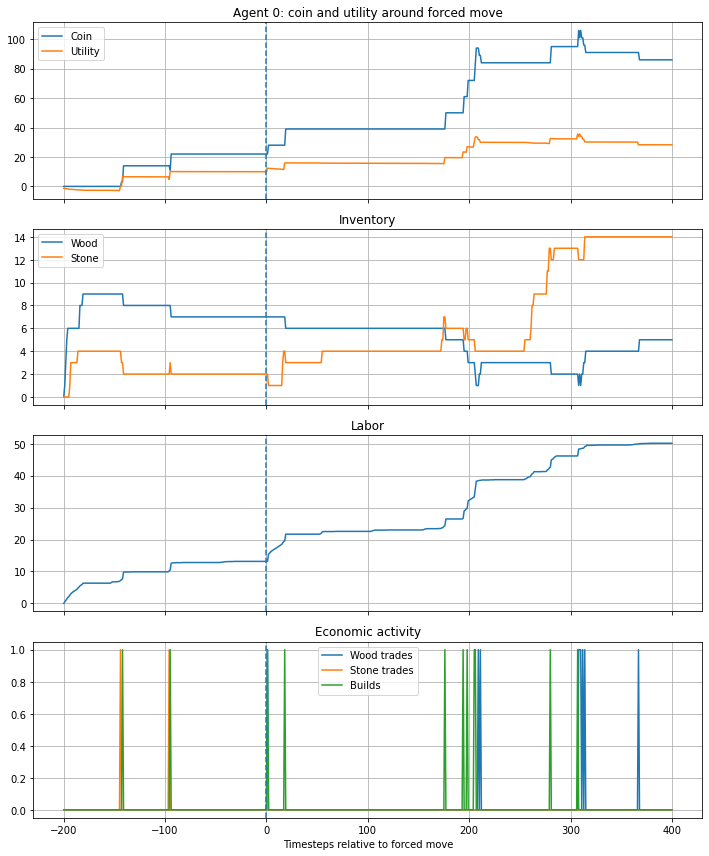

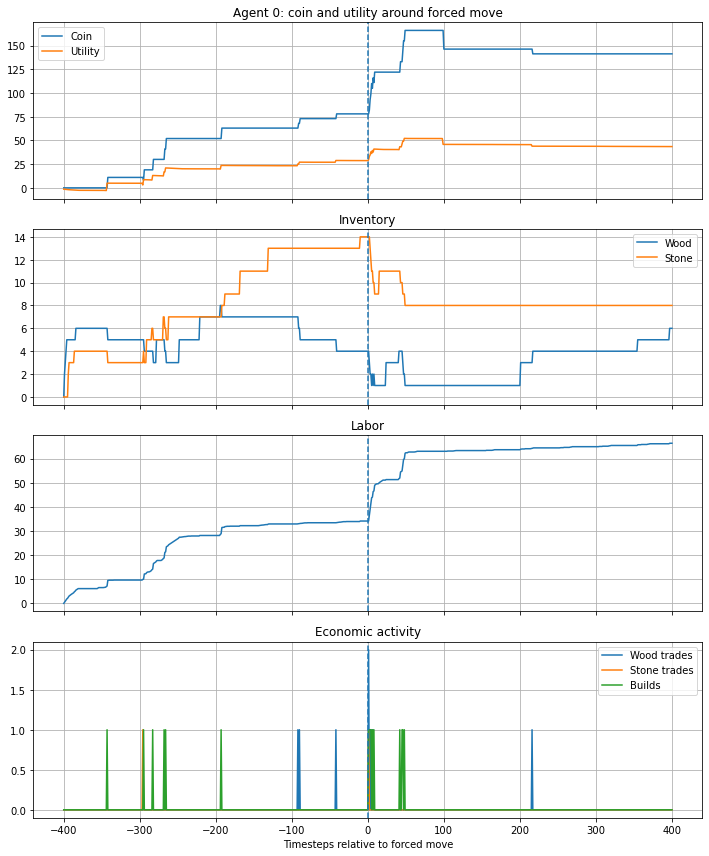

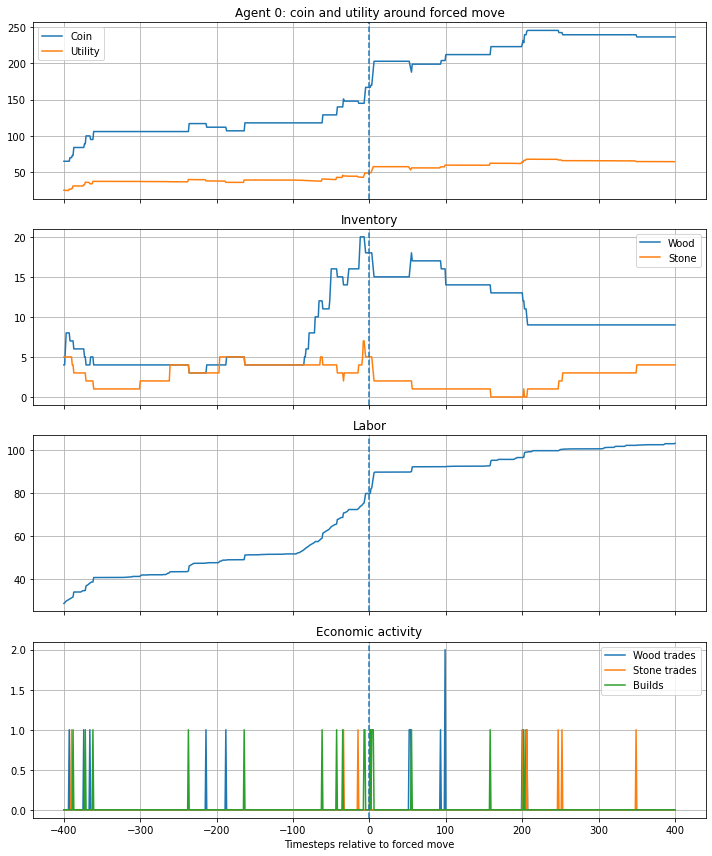

In [108]:
fig = plot_forced_move_timeseries(forced_log_200, window=400)
fig = plot_forced_move_timeseries(forced_log_400, window=400)
fig = plot_forced_move_timeseries(forced_log_600, window=400)

In [127]:
import numpy as np
import pandas as pd

def forced_move_system_summary_table(log, window_before=100, window_after=100):
    """
    Summary table for moved agent, other agents, and both planners
    before vs after a forced move.

    Returns a pandas DataFrame.
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out



    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                "n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
                "avg_planner_reward": np.nan,
                "sum_planner_reward": np.nan,
            })


    return pd.DataFrame(rows)

In [128]:
df_system = forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_system

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1,100,199,33.000,16.12,3.839189,3,33.0,0,0.0,0,0,0,0,NaN,NaN
1,moved_agent,after_move,1,201,300,45.796,12.20,26.950222,5,55.0,2,-8.0,1,0,1,0,NaN,NaN
2,other_agents,before_move,7,100,199,55.000,22.44,2.498209,4,55.0,0,0.0,0,0,0,0,NaN,NaN
3,other_agents,after_move,7,201,300,64.204,17.91,5.966774,4,55.0,10,8.0,0,1,4,5,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

def baseline_system_summary_table(log, moved_agent, reference_timestep, window_before=100, window_after=100, episode_key=0):
    """
    Summary table for the original baseline run with NO forced move.
    Accepts either:
      - a single episode log with log["states"], or
      - a dict of episode logs, e.g. log[0]["states"].

    Parameters
    ----------
    log : dict
    moved_agent : int
    reference_timestep : int
    window_before : int
    window_after : int
    episode_key : int or str
        Which episode to use if log is a multi-episode dict.
    """

    # --- normalize to a single episode log ---
    if "states" in log:
        ep_log = log
    elif episode_key in log and isinstance(log[episode_key], dict) and "states" in log[episode_key]:
        ep_log = log[episode_key]
    else:
        # fallback: pick first entry that looks like an episode log
        ep_log = None
        for v in log.values():
            if isinstance(v, dict) and "states" in v:
                ep_log = v
                break
        if ep_log is None:
            raise ValueError("Could not find a single episode log with key 'states'.")

    t0 = int(reference_timestep)

    states = ep_log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())

    if moved_agent not in agent_ids:
        raise ValueError(f"moved_agent={moved_agent} not found in baseline log")

    t_before_0 = max(0, t0 - window_before)
    t_before_1 = t0
    t_after_0 = t0 + 1
    t_after_1 = min(len(states), t0 + 1 + window_after)

    def total_coin(state, aid):
        s = state[str(aid)]
        return s["inventory"]["Coin"] + s["escrow"]["Coin"]

    def labor(state, aid):
        return state[str(aid)]["endogenous"]["Labor"]

    def utility_series(aids, t_start, t_end):
        vals = []
        for t in range(t_start, t_end):
            for aid in aids:
                vals.append(states[t][str(aid)].get("utility", np.nan))
        return np.array(vals, dtype=float)

    def coin_change(aids, t_start, t_end):
        start = sum(total_coin(states[t_start], aid) for aid in aids)
        end = sum(total_coin(states[t_end - 1], aid) for aid in aids)
        return end - start

    def labor_change(aids, t_start, t_end):
        start = sum(labor(states[t_start], aid) for aid in aids)
        end = sum(labor(states[t_end - 1], aid) for aid in aids)
        return end - start

    def build_stats(aids, t_start, t_end):
        n_builds = 0
        build_income = 0.0
        for t, builds in enumerate(ep_log.get("Build", [])):
            if not (t_start <= t < t_end):
                continue
            builds_ = builds.get("builds", []) if isinstance(builds, dict) else builds
            for b in builds_:
                if int(b["builder"]) in aids:
                    n_builds += 1
                    build_income += float(b.get("income", 0.0))
        return n_builds, build_income

    def trade_stats(aids, t_start, t_end):
        out = {
            "n_trades": 0,
            "trade_cashflow": 0.0,
            "n_buy_wood": 0,
            "n_sell_wood": 0,
            "n_buy_stone": 0,
            "n_sell_stone": 0,
        }
        for t, trades in enumerate(ep_log.get("Trade", [])):
            if not (t_start <= t < t_end):
                continue
            trades_ = trades.get("trades", []) if isinstance(trades, dict) else trades
            for tr in trades_:
                buyer = int(tr["buyer"])
                seller = int(tr["seller"])
                commodity = tr["commodity"].lower()

                if buyer in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] -= float(tr.get("cost", tr.get("price", 0.0)))
                    out[f"n_buy_{commodity}"] += 1
                if seller in aids:
                    out["n_trades"] += 1
                    out["trade_cashflow"] += float(tr.get("income", tr.get("price", 0.0)))
                    out[f"n_sell_{commodity}"] += 1
        return out

    def planner_stats(pid, t_start, t_end):
        arr = np.array(ep_log.get("planner_rewards", {}).get(pid, []), dtype=float)
        if len(arr) == 0:
            return {"avg_planner_reward": np.nan, "sum_planner_reward": np.nan}

        t_start = min(t_start, len(arr))
        t_end = min(t_end, len(arr))
        if t_start >= t_end:
            return {"avg_planner_reward": np.nan, "sum_planner_reward": np.nan}

        seg = arr[t_start:t_end]
        return {
            "avg_planner_reward": float(np.nanmean(seg)),
            "sum_planner_reward": float(np.nansum(seg)),
        }

    groups = {
        "moved_agent": [moved_agent],
        "other_agents": [aid for aid in agent_ids if aid != moved_agent],
    }

    rows = []

    for label, aids in groups.items():
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            n_builds, build_income = build_stats(aids, t_start, t_end)
            tr = trade_stats(aids, t_start, t_end)
            util = utility_series(aids, t_start, t_end)

            rows.append({
                "group": label,
                "period": period_name,
                "n_agents": len(aids),
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": coin_change(aids, t_start, t_end),
                "labor_change": labor_change(aids, t_start, t_end),
                "avg_utility": float(np.nanmean(util)),
                "n_builds": n_builds,
                "build_income": build_income,
                **tr,
                "avg_planner_reward": np.nan,
                "sum_planner_reward": np.nan,
            })

    for pid in ["p_top", "p_bottom"]:
        for period_name, t_start, t_end in [
            ("before_move", t_before_0, t_before_1),
            ("after_move", t_after_0, t_after_1),
        ]:
            pr = planner_stats(pid, t_start, t_end)
            rows.append({
                "group": pid,
                "period": period_name,
                "n_agents": np.nan,
                "t_start": t_start,
                "t_end": t_end - 1,
                "coin_change": np.nan,
                "labor_change": np.nan,
                "avg_utility": np.nan,
                "n_builds": np.nan,
                "build_income": np.nan,
                "n_trades": np.nan,
                "trade_cashflow": np.nan,
                "n_buy_wood": np.nan, 
                "n_sell_wood": np.nan,
                "n_buy_stone": np.nan,
                "n_sell_stone": np.nan,
                **pr,
            })

    return pd.DataFrame(rows)

In [ ]:
# use the same moved agent and timestep as in the forced-move run
moved_agent = forced_log["forced_move"]["agent"]
reference_timestep = forced_log["forced_move"]["timestep"]

df_forced = forced_move_system_summary_table(forced_log, window_before=100, window_after=100)
df_baseline = baseline_system_summary_table(
    dense_logs,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)

df_baseline

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,before_move,1.0,100,199,107.000,29.95,31.780025,6.0,66.0,20.0,44.0,1.0,12.0,4.0,3.0,NaN,NaN
1,moved_agent,after_move,1.0,201,300,87.105,29.17,54.730091,5.0,55.0,14.0,40.0,0.0,9.0,3.0,2.0,NaN,NaN
2,other_agents,before_move,7.0,100,199,201.000,127.34,6.624568,19.0,255.0,68.0,-44.0,31.0,20.0,8.0,9.0,NaN,NaN
3,other_agents,after_move,7.0,201,300,346.895,150.07,26.730850,26.0,379.0,138.0,-40.0,44.0,35.0,29.0,30.0,NaN,NaN
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298650,29.865000
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.510383,51.038333
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314063,31.406276
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.433304,43.330417


In [135]:
df_forced_cmp = df_forced.copy()
df_forced_cmp["run_type"] = "forced_move"

df_baseline_cmp = df_baseline.copy()
df_baseline_cmp["run_type"] = "baseline"

df_compare = pd.concat([df_baseline_cmp, df_forced_cmp], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,107.000,29.95,31.780025,6.0,66.0,20.0,44.0,1.0,12.0,4.0,3.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,87.105,29.17,54.730091,5.0,55.0,14.0,40.0,0.0,9.0,3.0,2.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,201.000,127.34,6.624568,19.0,255.0,68.0,-44.0,31.0,20.0,8.0,9.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,346.895,150.07,26.730850,26.0,379.0,138.0,-40.0,44.0,35.0,29.0,30.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.298650,29.865000,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.510383,51.038333,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314063,31.406276,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.433304,43.330417,baseline
8,moved_agent,before_move,1.0,100,199,33.000,16.12,3.839189,3.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,45.796,12.20,26.950222,5.0,55.0,2.0,-8.0,1.0,0.0,1.0,0.0,NaN,NaN,forced_move


In [142]:
import copy

def _compute_actions_from_obs(trainer, env_obj, obs, agent_states, p_top_state, p_bottom_state, explore=False):
    def _compute_action(pid, obs_i, state):
        out = trainer.compute_action(
            observation=obs_i,
            state=state,
            policy_id=pid,
            full_fetch=False,
            explore=explore,
        )
        if isinstance(out, tuple):
            if len(out) >= 2:
                return out[0], out[1]
            return out[0], state
        return out, state

    actions = {}

    for i in range(env_obj.env.n_agents):
        aid = str(i)
        a, ns = _compute_action("a", obs[aid], agent_states[aid])
        actions[aid] = a
        agent_states[aid] = ns

    a_top, p_top_state = _compute_action("p_top", obs["p_top"], p_top_state)
    a_bottom, p_bottom_state = _compute_action("p_bottom", obs["p_bottom"], p_bottom_state)

    actions["p_top"] = a_top
    actions["p_bottom"] = a_bottom

    return actions, agent_states, p_top_state, p_bottom_state

In [143]:
def _inject_utility_into_dense_log(dense_log, agent_utility_history):
    if "states" not in dense_log:
        return dense_log

    n_states = len(dense_log["states"])
    n_utils = len(agent_utility_history)
    n_match = min(n_states, n_utils)

    for t in range(n_match):
        for aid, util in agent_utility_history[t].items():
            if aid in dense_log["states"][t]:
                dense_log["states"][t][aid]["utility"] = util

    return dense_log

In [144]:
def force_single_agent_move(env_obj, agent_id, target_region, max_tries=500):
    world = env_obj.env.world
    agent = world.agents[int(agent_id)]

    H, W = world.world_size
    split = H // 2

    if target_region == "top":
        r_min, r_max = 0, split
    elif target_region == "bottom":
        r_min, r_max = split + 1, H
    else:
        raise ValueError("target_region must be 'top' or 'bottom'")

    old_r, old_c = agent.loc

    if (target_region == "top" and old_r < split) or (target_region == "bottom" and old_r > split):
        return {
            "agent": int(agent.idx),
            "from": (int(old_r), int(old_c)),
            "to": (int(old_r), int(old_c)),
            "new_region": target_region,
            "moved": False,
            "reason": "already_in_target_region",
        }

    for _ in range(max_tries):
        r = np.random.randint(r_min, r_max)
        c = np.random.randint(0, W)

        if world.maps.unoccupied[r, c] and world.can_agent_occupy(r, c, agent):
            new_r, new_c = world.set_agent_loc(agent, r, c)

            if "region" in agent.state:
                agent.state["region"] = "top" if int(new_r) < split else "bottom"

            try:
                cda = env_obj.env.get_component("ContinuousDoubleAuction")
                if cda is not None and hasattr(cda, "cancel_all_orders_for_agent"):
                    cda.cancel_all_orders_for_agent(agent.idx)
            except Exception:
                pass

            return {
                "agent": int(agent.idx),
                "from": (int(old_r), int(old_c)),
                "to": (int(new_r), int(new_c)),
                "new_region": agent.state.get("region", target_region),
                "moved": True,
            }

    raise RuntimeError(f"Could not find valid relocation target for agent {agent_id} to region {target_region}")

In [145]:
def generate_paired_baseline_forced_rollouts(
    trainer,
    env_obj,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
):
    """
    Create two rollouts with identical pre-move trajectories:
      1) baseline continuation
      2) forced-move continuation

    Returns
    -------
    baseline_log, forced_log
    """

    # --- reset once ---
    obs = env_obj.reset(force_dense_logging=True)

    agent_states = {
        str(i): trainer.get_policy("a").get_initial_state()
        for i in range(env_obj.env.n_agents)
    }
    p_top_state = trainer.get_policy("p_top").get_initial_state()
    p_bottom_state = trainer.get_policy("p_bottom").get_initial_state()

    pre_move_utility_history = []
    pre_move_planner_rewards_top = []
    pre_move_planner_rewards_bottom = []

    # --- run until forced_timestep ---
    for t in range(forced_timestep + 1):
        actions, agent_states, p_top_state, p_bottom_state = _compute_actions_from_obs(
            trainer, env_obj, obs, agent_states, p_top_state, p_bottom_state, explore=explore
        )

        obs, rew, done, info = env_obj.step(actions)

        util_t = {}
        for agent in env_obj.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_obj.env.curr_optimization_metric.get(agent.idx, np.nan))
        pre_move_utility_history.append(util_t)

        pre_move_planner_rewards_top.append(rew.get("p_top", np.nan))
        pre_move_planner_rewards_bottom.append(rew.get("p_bottom", np.nan))

        if done.get("__all__", False):
            raise RuntimeError("Episode ended before forced_timestep; choose a smaller forced_timestep.")

    # --- snapshot branch point ---
    env_baseline = copy.deepcopy(env_obj)
    env_forced = copy.deepcopy(env_obj)

    obs_baseline = copy.deepcopy(obs)
    obs_forced = copy.deepcopy(obs)

    agent_states_baseline = copy.deepcopy(agent_states)
    agent_states_forced = copy.deepcopy(agent_states)

    p_top_state_baseline = copy.deepcopy(p_top_state)
    p_top_state_forced = copy.deepcopy(p_top_state)

    p_bottom_state_baseline = copy.deepcopy(p_bottom_state)
    p_bottom_state_forced = copy.deepcopy(p_bottom_state)

    # =========================
    # BASELINE continuation
    # =========================
    baseline_utility_history = copy.deepcopy(pre_move_utility_history)
    baseline_top_rewards = copy.deepcopy(pre_move_planner_rewards_top)
    baseline_bottom_rewards = copy.deepcopy(pre_move_planner_rewards_bottom)

    for t in range(forced_timestep + 1, env_baseline.env.episode_length):
        actions, agent_states_baseline, p_top_state_baseline, p_bottom_state_baseline = _compute_actions_from_obs(
            trainer,
            env_baseline,
            obs_baseline,
            agent_states_baseline,
            p_top_state_baseline,
            p_bottom_state_baseline,
            explore=explore,
        )

        obs_baseline, rew, done, info = env_baseline.step(actions)

        util_t = {}
        for agent in env_baseline.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_baseline.env.curr_optimization_metric.get(agent.idx, np.nan))
        baseline_utility_history.append(util_t)

        baseline_top_rewards.append(rew.get("p_top", np.nan))
        baseline_bottom_rewards.append(rew.get("p_bottom", np.nan))

        if done.get("__all__", False):
            break

    baseline_log = dict(env_baseline.env.dense_log)
    baseline_log = _inject_utility_into_dense_log(baseline_log, baseline_utility_history)
    baseline_log["planner_rewards"] = {
        "p_top": baseline_top_rewards,
        "p_bottom": baseline_bottom_rewards,
    }
    baseline_log["paired_reference"] = {
        "agent": int(forced_agent_id),
        "timestep": int(forced_timestep),
        "target_region": forced_target_region,
        "type": "baseline",
    }

    # =========================
    # FORCED continuation
    # =========================
    forced_utility_history = copy.deepcopy(pre_move_utility_history)
    forced_top_rewards = copy.deepcopy(pre_move_planner_rewards_top)
    forced_bottom_rewards = copy.deepcopy(pre_move_planner_rewards_bottom)

    move_log = force_single_agent_move(
        env_forced,
        agent_id=forced_agent_id,
        target_region=forced_target_region,
    )
    move_log["timestep"] = int(forced_timestep)

    for t in range(forced_timestep + 1, env_forced.env.episode_length):
        actions, agent_states_forced, p_top_state_forced, p_bottom_state_forced = _compute_actions_from_obs(
            trainer,
            env_forced,
            obs_forced,
            agent_states_forced,
            p_top_state_forced,
            p_bottom_state_forced,
            explore=explore,
        )

        obs_forced, rew, done, info = env_forced.step(actions)

        util_t = {}
        for agent in env_forced.env.world.agents:
            aid = str(agent.idx)
            util_t[aid] = float(env_forced.env.curr_optimization_metric.get(agent.idx, np.nan))
        forced_utility_history.append(util_t)

        forced_top_rewards.append(rew.get("p_top", np.nan))
        forced_bottom_rewards.append(rew.get("p_bottom", np.nan))

        if done.get("__all__", False):
            break

    forced_log = dict(env_forced.env.dense_log)
    forced_log = _inject_utility_into_dense_log(forced_log, forced_utility_history)
    forced_log["planner_rewards"] = {
        "p_top": forced_top_rewards,
        "p_bottom": forced_bottom_rewards,
    }
    forced_log["forced_move"] = move_log

    return baseline_log, forced_log

In [146]:
paired_baseline_log, paired_forced_log = generate_paired_baseline_forced_rollouts(
    trainer=trainer_phase3b,
    env_obj=env_obj_phase3b,
    forced_agent_id=0,
    forced_timestep=200,
    forced_target_region="bottom",
    explore=False,
)


=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -0.678750000000008, 'before_pos': (33, 0), 'after_pos': (33, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.22624999999999995, 'before_pos': (50, 0), 'after_pos': (50, 0), 'dynamic_region_after': 'bottom'}, '6': {'delta': 0.22625000000000028, 'before_pos': (26, 13), 'after_pos': (26, 13), 'dynamic_region_after': 'bottom'}, '7': {'delta': 0.22624999999999995, 'before_pos': (50, 13), 'after_pos': (50, 13), 'dynamic_region_after': 'bottom'}}
OK: all affected agents are in the planner's expected region.

=== TAX COMPONENT DEBUG ===
component: RegionalPeriodicBracketTax
planner_id: p_bottom
expected_region_from_id: bottom
affected_agents: {'4': {'delta': -0.678750000000008, 'before_pos': (27, 0), 'after_pos': (27, 0), 'dynamic_region_after': 'bottom'}, '5': {'delta': 0.22624999999999995, 'before_pos': (50, 0), 'after_pos': (50, 0),

In [147]:
df_forced = forced_move_system_summary_table(
    paired_forced_log,
    window_before=100,
    window_after=100,
)
df_forced["run_type"] = "forced_move"

In [148]:
moved_agent = paired_forced_log["forced_move"]["agent"]
reference_timestep = paired_forced_log["forced_move"]["timestep"]

df_baseline = baseline_system_summary_table(
    paired_baseline_log,
    moved_agent=moved_agent,
    reference_timestep=reference_timestep,
    window_before=100,
    window_after=100,
)
df_baseline["run_type"] = "baseline"

In [149]:
df_compare = pd.concat([df_baseline, df_forced], ignore_index=True)
df_compare

,group,period,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward,run_type
0,moved_agent,before_move,1.0,100,199,6.000,7.98,19.618940,1.0,11.0,1.0,-5.0,1.0,0.0,0.0,0.0,NaN,NaN,baseline
1,moved_agent,after_move,1.0,201,300,0.000,1.42,19.692551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,baseline
2,other_agents,before_move,7.0,100,199,16.000,14.13,1.519337,1.0,11.0,1.0,5.0,0.0,1.0,0.0,0.0,NaN,NaN,baseline
3,other_agents,after_move,7.0,201,300,44.000,27.19,2.175486,4.0,44.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,baseline
4,p_top,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.887379e-16,1.887379e-14,baseline
5,p_top,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,baseline
6,p_bottom,before_move,NaN,100,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.333333e-03,8.333333e-01,baseline
7,p_bottom,after_move,NaN,201,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.262500e-03,2.262500e-01,baseline
8,moved_agent,before_move,1.0,100,199,6.000,7.98,19.618940,1.0,11.0,1.0,-5.0,1.0,0.0,0.0,0.0,NaN,NaN,forced_move
9,moved_agent,after_move,1.0,201,300,49.297,13.71,33.766314,5.0,55.0,2.0,-4.0,1.0,1.0,0.0,0.0,NaN,NaN,forced_move


In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_forced_move_utilities_system(log, window=100):
    """
    Plot utility development before and after forced move for:
    - moved agent
    - average of other agents
    - p_top reward
    - p_bottom reward
    """
    fm = log.get("forced_move", None)
    if fm is None:
        raise ValueError("No forced_move entry found in log.")

    moved_agent = int(fm["agent"])
    t0 = int(fm["timestep"])

    states = log["states"]
    first_state = states[0]
    agent_ids = sorted(int(k) for k in first_state.keys() if str(k).isdigit())
    other_agents = [aid for aid in agent_ids if aid != moved_agent]

    t_start = max(0, t0 - window)
    t_end = min(len(states), t0 + window + 1)

    rows = []
    for t in range(t_start, t_end):
        rel_t = t - t0

        moved_u = states[t][str(moved_agent)].get("utility", np.nan)

        others_u = []
        for aid in other_agents:
            others_u.append(states[t][str(aid)].get("utility", np.nan))
        others_u = np.array(others_u, dtype=float)

        p_top_arr = np.array(log.get("planner_rewards", {}).get("p_top", []), dtype=float)
        p_bottom_arr = np.array(log.get("planner_rewards", {}).get("p_bottom", []), dtype=float)

        p_top_val = p_top_arr[t] if t < len(p_top_arr) else np.nan
        p_bottom_val = p_bottom_arr[t] if t < len(p_bottom_arr) else np.nan

        rows.append({
            "t": t,
            "relative_t": rel_t,
            "moved_agent_utility": moved_u,
            "other_agents_avg_utility": float(np.nanmean(others_u)),
            "p_top_reward": p_top_val,
            "p_bottom_reward": p_bottom_val,
        })

    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(df["relative_t"], df["moved_agent_utility"], label="Moved agent utility")
    axes[0].plot(df["relative_t"], df["other_agents_avg_utility"], label="Other agents avg utility")
    axes[0].axvline(0, linestyle="--")
    axes[0].set_title("Agent utility before and after forced move")
    axes[0].set_ylabel("Utility")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(df["relative_t"], df["p_top_reward"], label="p_top reward")
    axes[1].plot(df["relative_t"], df["p_bottom_reward"], label="p_bottom reward")
    axes[1].axvline(0, linestyle="--")
    axes[1].set_title("Planner rewards before and after forced move")
    axes[1].set_xlabel("Timesteps relative to forced move")
    axes[1].set_ylabel("Reward")
    axes[1].grid(True)
    axes[1].legend()

    fig.tight_layout()
    return fig, df

,t,relative_t,moved_agent_utility,other_agents_avg_utility,p_top_reward,p_bottom_reward
0,100,-100,-2.831701,0.334971,NaN,NaN
1,101,-99,-2.831701,0.334971,NaN,NaN
2,102,-98,-2.831701,0.334971,NaN,NaN
3,103,-97,-2.842201,0.319371,NaN,NaN
4,104,-96,-2.852701,0.311571,NaN,NaN


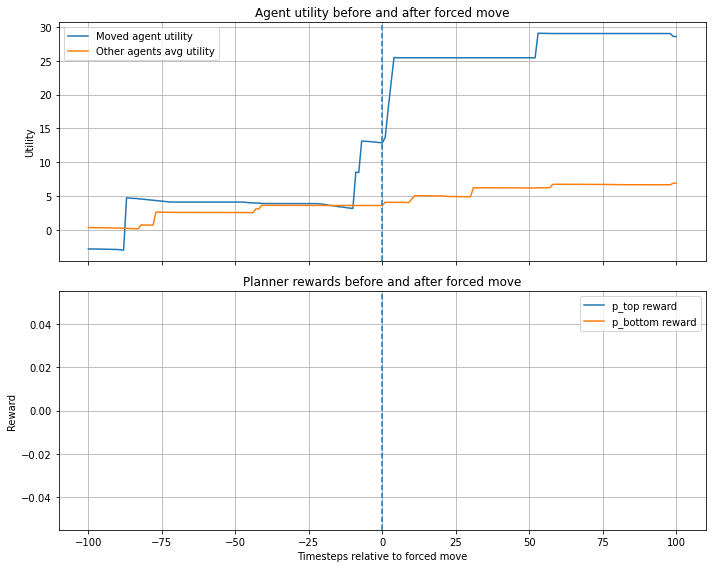

In [123]:
fig, df_util = plot_forced_move_utilities_system(forced_log, window=100)
df_util.head()

In [113]:
def forced_move_delta_table(log, window_before=100, window_after=100):
    df = forced_move_system_summary_table(
        log,
        window_before=window_before,
        window_after=window_after,
    )

    numeric_cols = [
        c for c in df.columns
        if c not in ["group", "period"]
    ]

    before = df[df["period"] == "before_move"].set_index("group")
    after = df[df["period"] == "after_move"].set_index("group")

    delta = after[numeric_cols] - before[numeric_cols]
    delta = delta.reset_index()
    return delta

In [114]:
df_delta = forced_move_delta_table(forced_log, window_before=100, window_after=100)
df_delta

,group,n_agents,t_start,t_end,coin_change,labor_change,avg_utility,n_builds,build_income,n_trades,trade_cashflow,n_buy_wood,n_sell_wood,n_buy_stone,n_sell_stone,avg_planner_reward,sum_planner_reward
0,moved_agent,0.0,101,101,12.796,-3.92,23.111032,2.0,22.0,2.0,-8.0,1.0,0.0,1.0,0.0,NaN,NaN
1,other_agents,0.0,101,101,9.204,-4.53,3.468566,0.0,0.0,10.0,8.0,0.0,1.0,4.0,5.0,NaN,NaN
2,p_top,NaN,101,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,p_bottom,NaN,101,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
